# Project dependencies

In [ ]:
import subprocess

def install_packages(package_list):
    """
    Install packages using pip, executing each command individually.

    Args:
        package_list (list): List of packages to install.
    """
    for package in package_list:
        try:
            print(f"Installing package: {package}")
            subprocess.run(["pip", "install", package], check=True)
            print(f"Package {package} installed successfully!\n")
        except subprocess.CalledProcessError as e:
            print(f"Error installing package {package}: {e}\n")

# List of packages to install (skip if you already ran: pip install -r requirements.txt)
packages = ["pandas", "numpy", "scikit-learn", "scipy", "matplotlib", "seaborn", "openml", "pymfe", "mlxtend", "tabulate", "joblib"]

# Call the function to install the packages
install_packages(packages)


import subprocess
import warnings

# Ignore warning messages
warnings.filterwarnings("ignore")

# Imports for data analysis and machine learning
import pandas as pd
from sklearn.model_selection import cross_val_score
import time
import numpy as np
from sklearn.model_selection import GridSearchCV
from mlxtend.evaluate import paired_ttest_5x2cv
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import NearestNeighbors
import json
import openml
from scipy.stats import spearmanr
import gc
from scipy import stats
from tabulate import tabulate
from scipy.stats import rankdata, friedmanchisquare
from math import sqrt

# Imports for classification tasks
from sklearn import neighbors
from sklearn.metrics import mean_squared_error
from math import sqrt
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.datasets import make_classification
from sklearn.utils import shuffle
from sklearn.multioutput import MultiOutputClassifier
from sklearn.model_selection import LeaveOneOut
from joblib import Parallel, delayed
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import StandardScaler, LabelEncoder
from multiprocessing import Process, Queue
from sklearn.manifold import LocallyLinearEmbedding
from sklearn.manifold import SpectralEmbedding

# Imports for dimensionality reduction techniques
from sklearn import decomposition
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.datasets import make_multilabel_classification
from sklearn.decomposition import FastICA
from sklearn.decomposition import KernelPCA
from sklearn.manifold import TSNE
from sklearn.manifold import LocallyLinearEmbedding
from sklearn.cross_decomposition import CCA
from sklearn.decomposition import TruncatedSVD
from sklearn.decomposition import SparseCoder
from sklearn.decomposition import FactorAnalysis
from sklearn.decomposition import NMF
from sklearn.decomposition import IncrementalPCA
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectKBest, chi2
# from openTSNE import TSNE

# Google Colab: mount Drive (optional; skip when running locally)
# try:
#     from google.colab import drive
#     drive.mount('/content/drive')
# except ImportError:
#     pass  # Running locally: data paths are relative to project root


Installing package: openml
Package openml installed successfully!

Installing package: pymfe
Package pymfe installed successfully!

Installing package: mlxtend
Package mlxtend installed successfully!

Mounted at /content/drive


#Loading datasets from the [OpenML](https://www.openml.org/) repository

In [ ]:
openml_list = openml.datasets.list_datasets()
datalist = pd.DataFrame.from_dict(openml_list, orient="index")

In [ ]:
# Query used to filter datasets from the OpenML repository based on specific criteria
# (number of classes, instances, and features). Datasets listed in the query were
# excluded because they could not be downloaded, and datasets in the Sparse_ARFF
# format were also removed.

excluded_dids = [
    45086, 45087, 45088, 45089, 45090,
    45097, 45098, 45099, 45100,
    42812, 45085, 45101, 42811, 42810,
    46611
]

datasets = datalist.query(
    "NumberOfClasses > 1 "
    "& NumberOfInstances < 30000 "
    "& NumberOfFeatures >= 1000 "
    "& NumberOfFeatures <= 30000 "
    "& NumberOfInstancesWithMissingValues == 0 "
    "& NumberOfNumericFeatures == NumberOfFeatures - 1 "
    "& MinorityClassSize > 10 "
    "& format != 'Sparse_ARFF' "
    "& did not in @excluded_dids"
)

datasets

,did,name,version,uploader,status,format,MajorityClassSize,MaxNominalAttDistinctValues,MinorityClassSize,NumberOfClasses,NumberOfFeatures,NumberOfInstances,NumberOfInstancesWithMissingValues,NumberOfMissingValues,NumberOfNumericFeatures,NumberOfSymbolicFeatures
1039,1039,hiva_agnostic,1,2,active,ARFF,4080.0,2.0,149.0,2.0,1618.0,4229.0,0.0,0.0,1617.0,1.0
1084,1084,BurkittLymphoma,1,2,active,ARFF,128.0,3.0,44.0,3.0,22284.0,220.0,0.0,0.0,22283.0,1.0
1104,1104,leukemia,1,2,active,ARFF,47.0,2.0,25.0,2.0,7130.0,72.0,0.0,0.0,7129.0,1.0
1107,1107,tumors_C,1,2,active,ARFF,39.0,2.0,21.0,2.0,7130.0,60.0,0.0,0.0,7129.0,1.0
1122,1122,AP_Breast_Prostate,1,2,active,ARFF,344.0,2.0,69.0,2.0,10936.0,413.0,0.0,0.0,10935.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46775,46775,armstrong-2002-v1,1,30703,active,arff,48.0,NaN,24.0,2.0,1082.0,72.0,0.0,0.0,1081.0,0.0
46776,46776,bittner-2000,1,30703,active,arff,19.0,NaN,19.0,2.0,2202.0,38.0,0.0,0.0,2201.0,0.0
46781,46781,khan-2001,1,30703,active,arff,29.0,NaN,11.0,4.0,1070.0,83.0,0.0,0.0,1069.0,0.0
46855,46855,toxicity,2,25914,active,arff,115.0,NaN,56.0,2.0,1204.0,171.0,0.0,0.0,1203.0,1.0


Figure saved to: dataset_summary.pdf


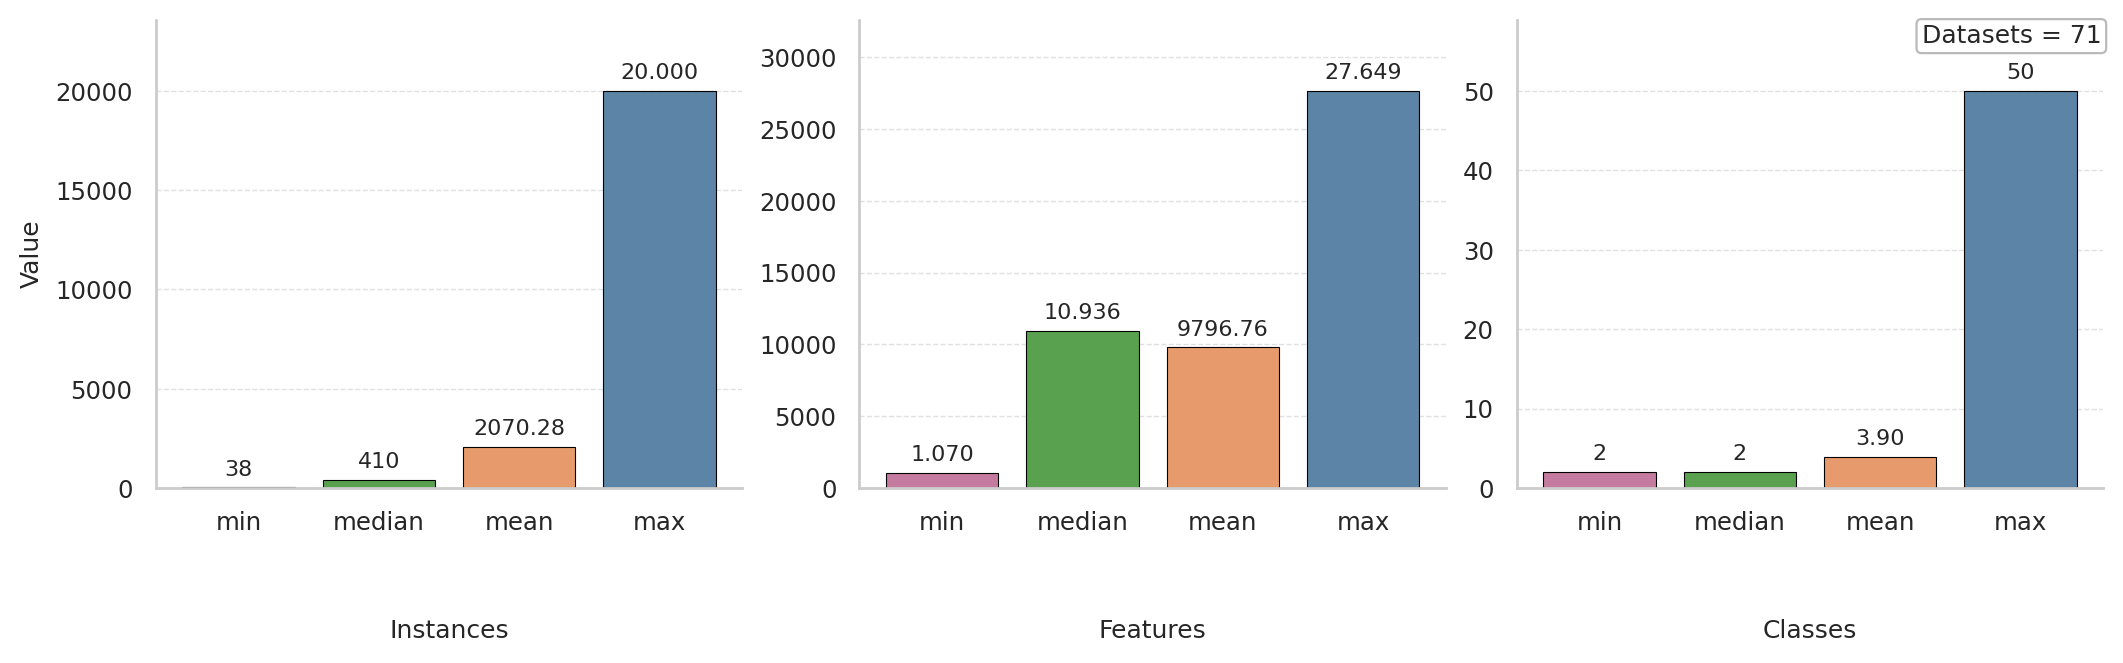

In [ ]:
df_summary_stats = datasets[[
    "NumberOfInstances",
    "NumberOfFeatures",
    "NumberOfClasses"
]]

# Basic descriptive statistics
summary_stats = df_summary_stats.describe().T

# Add median (describe() does not include it)
summary_stats["median"] = df_summary_stats.median()

# Total number of datasets
n_datasets = int(summary_stats.loc["NumberOfInstances", "count"])

# Data prepared for plotting (min / median / mean / max)
plot_summary = summary_stats[["min", "median", "mean", "max"]].copy()
plot_summary = plot_summary.reset_index().rename(columns={"index": "Metric"})

# Color palette
color_palette = {
    "min": "#C57B9F",
    "median": "#59A14F",
    "mean": "#E79B6C",
    "max": "#5B84A6"
}
stat_order = ["min", "median", "mean", "max"]

# More formal plot style
sns.set_theme(style="whitegrid", context="paper")
plt.rcParams.update({
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "legend.fontsize": 8,
})

metrics = ["NumberOfInstances", "NumberOfFeatures", "NumberOfClasses"]
metric_labels = {
    "NumberOfInstances": "Instances",
    "NumberOfFeatures": "Features",
    "NumberOfClasses": "Classes",
}

fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.2), dpi=200, constrained_layout=True)

for ax, metric in zip(axes, metrics):
    row = plot_summary[plot_summary["Metric"] == metric][stat_order].iloc[0]
    values = row.values.astype(float)

    bars = ax.bar(
        stat_order,
        values,
        color=[color_palette[key] for key in stat_order],
        edgecolor="black",
        linewidth=0.4
    )

    ax.set_xlabel("")
    ax.set_ylabel("Value" if ax is axes[0] else "")

    # Subtle grid only on the y-axis
    ax.grid(True, axis="y", linestyle="--", linewidth=0.5, alpha=0.6)
    ax.grid(False, axis="x")

    # Remove top and right borders
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Add value labels above bars
    y_max = values.max()
    y_offset = 0.02 * y_max if y_max > 0 else 0.1

    for bar, value, stat_name in zip(bars, values, stat_order):
        if metric in ["NumberOfInstances", "NumberOfFeatures"] and stat_name in ["min", "median", "max"]:
            label = f"{int(round(value)):,}".replace(",", ".")
        elif stat_name == "mean":
            label = f"{value:.2f}"
        else:
            label = f"{int(round(value))}" if abs(value - round(value)) < 1e-9 else f"{value:.2f}"

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value + y_offset,
            label,
            ha="center",
            va="bottom",
            fontsize=8
        )

    # Add some space above the bars
    ax.set_ylim(0, y_max * 1.18)

# Add centered labels below each subplot
for ax, metric in zip(axes, metrics):
    ax.text(
        0.5, -0.28,
        metric_labels[metric],
        transform=ax.transAxes,
        ha="center",
        va="top",
        fontsize=9
    )

# Add total number of datasets to the figure
fig.text(
    0.995, 0.98,
    f"Datasets = {n_datasets}",
    ha="right",
    va="top",
    fontsize=9,
    bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="0.7", alpha=0.9)
)

output_file = "dataset_summary.pdf"

plt.savefig(
    output_file,
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.02,
)

print(f"Figure saved to: {output_file}")

plt.show()

In [ ]:
# Ensure the dataset index is sequential (0 to N-1)
datasets.shape[0]
datasets.index = range(datasets.shape[0])
datasets.head()

,did,name,version,uploader,status,format,MajorityClassSize,MaxNominalAttDistinctValues,MinorityClassSize,NumberOfClasses,NumberOfFeatures,NumberOfInstances,NumberOfInstancesWithMissingValues,NumberOfMissingValues,NumberOfNumericFeatures,NumberOfSymbolicFeatures
0,1039,hiva_agnostic,1,2,active,ARFF,4080.0,2.0,149.0,2.0,1618.0,4229.0,0.0,0.0,1617.0,1.0
1,1084,BurkittLymphoma,1,2,active,ARFF,128.0,3.0,44.0,3.0,22284.0,220.0,0.0,0.0,22283.0,1.0
2,1104,leukemia,1,2,active,ARFF,47.0,2.0,25.0,2.0,7130.0,72.0,0.0,0.0,7129.0,1.0
3,1107,tumors_C,1,2,active,ARFF,39.0,2.0,21.0,2.0,7130.0,60.0,0.0,0.0,7129.0,1.0
4,1122,AP_Breast_Prostate,1,2,active,ARFF,344.0,2.0,69.0,2.0,10936.0,413.0,0.0,0.0,10935.0,1.0


In [ ]:
# This code downloads datasets from the OpenML repository, extracts their names
# and IDs, and saves this metadata in both JSON and CSV formats.


# Initialize dictionary to store dataset metadata
dataset_info = {'Name': [], 'Id': []}

skip = 0

# Iterate over dataset IDs obtained from the filtered OpenML dataset list
for dataset_id in datasets['did']:

    # Skip datasets if necessary (useful when resuming a previous execution)
    if skip:
        skip -= 1
        continue

    # Start timer to track download time
    start_time_test = time.time()

    # Download dataset metadata and data from the OpenML repository
    dataset = openml.datasets.get_dataset(dataset_id)

    # Load dataset into a pandas DataFrame
    X, y, categorical_indicator, attribute_names = dataset.get_data(
        dataset_format="dataframe",
        target=dataset.default_target_attribute
    )

    # Extract dataset name and ID
    name = dataset.name
    Id = dataset_id

    # Store dataset information
    dataset_info['Name'].append(name)
    dataset_info['Id'].append(Id)


# Convert dictionary to JSON format and save it
with open("datasets_openml.json", "w") as json_file:
    json.dump(dataset_info, json_file, indent=3)


# Convert dictionary to pandas DataFrame and export as CSV
df_datasets = pd.DataFrame(dataset_info)
df_datasets.to_csv("datasets_openml.csv", index=False)

print("Files saved: datasets_openml.json and datasets_openml.csv")

# Extracting meta-features from the datasets

In [ ]:
# Extract "general" meta-features from each OpenML dataset using the pymfe library.
# These meta-features describe basic dataset characteristics such as size,
# number of attributes, and other general statistical properties.


dataset_id = 0
dataset_id_list = []
skip = 0
rows = []

# Dictionary structure (optional, if used later)
dataset_meta = {'Name': [], 'MetaF_General': []}

# Iterate over dataset IDs obtained from the filtered OpenML dataset list
for dataset_id in datasets['did']:

    # Skip datasets if necessary (useful when resuming execution)
    if skip:
        skip -= 1
        continue

    # Start timer to monitor extraction time
    start_time_test = time.time()

    # Download dataset from the OpenML repository
    dataset = openml.datasets.get_dataset(dataset_id)

    # Load dataset as NumPy arrays (required by pymfe)
    X, y, categorical_indicator, attribute_names = dataset.get_data(
        dataset_format="array",
        target=dataset.default_target_attribute
    )

    # Initialize the Meta-Feature Extractor (MFE)
    # Here we extract only the "general" group of meta-features
    # which describe basic dataset properties (e.g., number of attributes, instances, etc.)
    mfe = MFE(groups=["general"])

    # Fit the extractor to the dataset
    mfe.fit(X, y)

    # Extract the meta-features
    mf = mfe.extract()

    # Create column names (dataset name + meta-feature names)
    columns = ["Name"] + mf[0]

    # Store the extracted meta-feature values
    rows.append([dataset.name] + mf[1])

    # Convert results to DataFrame
    df = pd.DataFrame(rows, columns=columns)

    # Save extracted general meta-features to CSV
    df.to_csv("metaGeneral.csv", index=False)

In [ ]:
# Load and clean the general meta-features dataset
General = pd.read_csv('data/metafeatures/metaGeneral.csv').drop(columns=['Unnamed: 0'])

General.head()

,Name_Dataset,MetaF_General
0,hiva_agnostic,"[0.38235989595649, 0.0, 0.5, 0.657279914127292..."
1,BurkittLymphoma,"[101.28636363636363, 0.0, 0.33333333333333304,..."
2,leukemia,"[99.01388888888889, 0.0, 0.5, 0.21606040536255..."
3,tumors_C,"[118.81666666666666, 0.0, 0.5, 0.2121320343559..."
4,AP_Breast_Prostate,"[26.476997578692494, 0.0, 0.5, 0.4708338131387..."


In [ ]:
# Extract statistical meta-features from each OpenML dataset using the PyMFE library.
# These meta-features describe statistical properties of dataset attributes
# such as mean, variance, skewness, kurtosis, and other distribution-based measures.

dataset_id = 0
dataset_id_list = []
skip = 0
rows = []

# Dictionary structure (optional if needed later)
dataset_meta = {'Name_Dataset': [], 'MetaF_Statistical': []}

# Iterate over dataset IDs obtained from the filtered OpenML dataset list
for dataset_id in datasets['did']:

    # Skip datasets if necessary (useful when resuming execution)
    if skip:
        skip -= 1
        continue

    # Start timer to monitor extraction time
    start_time_test = time.time()

    # Download dataset from the OpenML repository
    dataset = openml.datasets.get_dataset(dataset_id)

    # Load dataset as NumPy arrays (required by pymfe)
    X, y, categorical_indicator, attribute_names = dataset.get_data(
        dataset_format="array",
        target=dataset.default_target_attribute
    )

    # Initialize the Meta-Feature Extractor (MFE)
    # Here we extract the "statistical" group of meta-features
    # which describe statistical properties of the dataset attributes
    mfe = MFE(groups=["statistical"])

    # Fit the extractor to the dataset
    mfe.fit(X, y)

    # Extract the statistical meta-features
    mf = mfe.extract()

    # Dataset name
    dataset_name = dataset.name

    # Create column names (dataset name + meta-feature names)
    columns = ["Name"] + mf[0]

    # Store extracted meta-feature values
    rows.append([dataset_name] + mf[1])

    # Convert results to DataFrame
    df = pd.DataFrame(rows, columns=columns)

    # Save statistical meta-features to CSV
    df.to_csv("metaStatistical.csv", index=False)

In [ ]:
# Load and clean the statistical meta-features dataset
Statistical = pd.read_csv('data/metafeatures/metaStatistical.csv').drop(columns=['Unnamed: 0'])

Statistical.head()

,Name_Dataset,MetaF_Statistical
0,hiva_agnostic,"[0.7310983315162921, None, 0.050080822015636, ..."
1,BurkittLymphoma,"[1.0, 0.0, 0.15483551016063601, 0.122138375274..."
2,leukemia,"[1.0, None, 0.16421833587425202, 0.13197255053..."
3,tumors_C,"[1.0, None, 0.192160100818449, 0.1474495414573..."
4,AP_Breast_Prostate,"[1.0, None, 0.11454444038921001, 0.09849439979..."


In [ ]:
# Extract information-theory meta-features from each dataset using the PyMFE library.
# These meta-features capture relationships between attributes and the target
# based on entropy and other information-theoretic measures.

dataset_id = 0
dataset_id_list = []
skip = 0
rows = []

# Iterate over dataset IDs from the filtered OpenML dataset list
for dataset_id in datasets['did']:

    # Skip datasets if needed (useful when resuming execution)
    if skip:
        skip -= 1
        continue

    # Start timer to monitor extraction time
    start_time_test = time.time()

    # Download dataset from the OpenML repository
    dataset = openml.datasets.get_dataset(dataset_id)

    # Load dataset as NumPy arrays (required by pymfe)
    X, y, categorical_indicator, attribute_names = dataset.get_data(
        dataset_format="array",
        target=dataset.default_target_attribute
    )

    # Initialize the Meta-Feature Extractor (MFE)
    # Here we extract the "info-theory" meta-features
    # These features are based on information theory concepts
    # such as entropy, mutual information, and attribute-class relationships
    mfe = MFE(groups=["info-theory"])

    # Fit the extractor to the dataset
    mfe.fit(X, y)

    # Extract the meta-features
    mf = mfe.extract()

    # Dataset name
    dataset_name = dataset.name

    # Create column names (dataset name + meta-feature names)
    columns = ["Name"] + mf[0]

    # Store extracted meta-feature values
    rows.append([dataset_name] + mf[1])

    # Convert results to DataFrame
    df = pd.DataFrame(rows, columns=columns)

    # Save extracted information-theory meta-features to CSV
    df.to_csv("metaInfo_Theory.csv", index=False)

In [ ]:
# Load and clean the info_theory meta-features dataset
info_theory = pd.read_csv('data/metafeatures/metaInfo_Theory.csv').drop(columns=['Unnamed: 0'])

info_theory.head()

,Name_Dataset,MetaF_Info_theory
0,hiva_agnostic,"[0.009032772029023, 0.037301057418236, 0.33831..."
1,BurkittLymphoma,"[0.030665876692398, 0.011304879175127, 2.58457..."
2,leukemia,"[0.051099601170522, 0.032646833928957, 1.99960..."
3,tumors_C,"[0.067767948532446, 0.051223931490845004, 1.58..."
4,AP_Breast_Prostate,"[0.020709832557712003, 0.006626353535956001, 2..."


# Algorithm Performance Evaluation

## Classification without Dimensionality Reduction using KNN

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder

results = {'Name': [], 'Score': []}

# Number of neighbors for the KNN classifier
k = 31

# Iterate over all dataset IDs contained in datasets
for dataset_Id in datasets['did']:

    # Start timer (optional: useful for measuring dataset processing time)
    start_time_test = time.time()

    # Load dataset from OpenML
    dataset = openml.datasets.get_dataset(dataset_Id)

    # Retrieve features (X) and target variable (y)
    X, y, categorical_indicator, attribute_names = dataset.get_data(
        dataset_format="dataframe",
        target=dataset.default_target_attribute
    )

    # PREPROCESSING

    # Convert categorical columns to numeric values using Label Encoding
    # KNN requires numerical inputs
    for col in X.select_dtypes(include=['object', 'category']).columns:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col])

    # Apply feature scaling (Standardization)
    # Important for distance-based algorithms like KNN
    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    # STRATIFIED CROSS-VALIDATION

    # Stratified 5-Fold Cross Validation preserves class distribution
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # List to store F1-score results from each fold
    f1_scores = []

    for train_index, test_index in skf.split(X, y):

        # Split dataset into training and testing subsets
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]

        # Ensure the number of neighbors does not exceed training size
        n_neighbors = min(k, len(X_train))

        # Initialize the KNN classifier
        neigh = KNeighborsClassifier(
            n_neighbors=n_neighbors,
            weights='uniform',
            algorithm='auto',
            leaf_size=10,
            metric='minkowski',
            p=2  # Euclidean distance
        )

        # Train the model
        neigh.fit(X_train, y_train)

        # Generate predictions
        y_pred = neigh.predict(X_test)

        # Compute evaluation metric (micro F1-score)
        score = f1_score(y_test, y_pred, average='micro')

        # Store fold result
        f1_scores.append(score)

    # Compute the average F1-score across all folds
    avg_f1 = np.mean(f1_scores)

    # Store results
    name = dataset.name
    results['Name'].append(name)
    results['Score'].append(avg_f1)

    # Save results to a JSON file
    with open("ClassificationNoreduction.json", "w") as outfile:
        json.dump(results, outfile, indent=3)


In [ ]:
# Load the CSV file containing the classification results
# This file stores the performance of the classifier without dimensionality reduction
# Path relative to project root (run the notebook from the repo root, e.g. meta-dr/)
from pathlib import Path
performance_without_reduction = pd.read_csv(Path("data") / "baseline" / "ClassificationNoreduction.csv")

# Useful to quickly inspect the structure and verify that the data loaded correctly
performance_without_reduction.head()


## Classification with Dimensionality Reduction using KNN

### (PCA)

In [ ]:
import warnings
warnings.filterwarnings("ignore")

dictionary = {'Name': [], 'Score': []}
skipped_datasets = []
k = 31

def process_dataset_pca(dataset_Id, k):
    try:
        print(f"[INFO] Starting dataset ID: {dataset_Id}")

        # Load dataset from OpenML
        dataset = openml.datasets.get_dataset(dataset_Id)
        X, y, _, _ = dataset.get_data(
            dataset_format="dataframe",
            target=dataset.default_target_attribute
        )

        print(f"[INFO] Dataset loaded: {dataset.name} | Shape: {X.shape}")

        # Handle missing values and scale features
        X = np.nan_to_num(X)
        X = StandardScaler().fit_transform(X.astype(float))

        # Limit dataset size for faster processing
        if X.shape[0] > 2000:
            print(f"[INFO] Reducing dataset size from {X.shape[0]} to 2000 samples")
            X = X[:2000]
            y = y[:2000]

        # Stratified 5-Fold Cross Validation
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        f1_scores = []

        for fold, (train_index, test_index) in enumerate(skf.split(X, y), start=1):
            print(f"[INFO] Processing fold {fold}/5 for dataset {dataset.name}")

            X_train, X_test = X[train_index], X[test_index]
            y_train, y_test = y[train_index], y[test_index]

            # Apply PCA
            pca = PCA()
            X_train_pca = pca.fit_transform(X_train)

            # Kaiser rule: keep components with variance > 1/n
            num_components = sum(pca.explained_variance_ > 1 / len(X_train))

            # Fallback if no components selected
            if num_components == 0:
                num_components = min(2, X_train_pca.shape[1])
                print(f"[WARNING] No components selected, fallback to {num_components}")

            # Transform train and test sets
            X_train_pca = X_train_pca[:, :num_components]
            X_test_pca = pca.transform(X_test)[:, :num_components]

            print(f"[INFO] Selected components: {num_components}")

            # Train KNN classifier
            n_neighbors = min(k, len(X_train))
            neigh = KNeighborsClassifier(n_neighbors=n_neighbors)
            neigh.fit(X_train_pca, y_train)

            # Predict and evaluate
            y_pred = neigh.predict(X_test_pca)
            score = f1_score(y_test, y_pred, average='micro')
            f1_scores.append(score)

            print(f"[INFO] Fold {fold} F1-score: {score:.4f}")

        mean_score = np.mean(f1_scores)
        print(f"[SUCCESS] Finished dataset: {dataset.name} | Mean F1: {mean_score:.4f}\n")

        return (dataset.name, mean_score)

    except Exception as e:
        print(f"[ERROR] Dataset ID {dataset_Id} failed: {str(e)}\n")
        return ('__error__', f"{dataset_Id}: {str(e)}")


# Parallel execution (adjust n_jobs based on CPU)
print("[INFO] Starting parallel processing...\n")

results = Parallel(n_jobs=2, backend='loky', verbose=10)(
    delayed(process_dataset_pca)(dataset_Id, k)
    for dataset_Id in datasets['did']
)

print("\n[INFO] Processing results...\n")

# Post-process results
for res in results:
    if res[0] == '__error__':
        skipped_datasets.append(res[1])
        print(f"[SKIPPED] {res[1]}")
    else:
        dictionary['Name'].append(res[0])
        dictionary['Score'].append(res[1])
        print(f"[DONE] {res[0]} | Mean F1: {res[1]:.4f}")

# Save results
print("\n[INFO] Saving results to files...")

with open('ClassificationWithReduction_PCA.json', 'w') as f:
    json.dump(dictionary, f, indent=3)

pd.DataFrame(dictionary).to_csv(
    'ClassificationWithReduction_PCA.csv',
    index=False
)

print("\n[FINAL REPORT]")
print(f"Total skipped datasets: {len(skipped_datasets)}")
print(f"Skipped IDs: {skipped_datasets}")

### Kernel Principal Component Analysis (kPCA)

In [ ]:
import warnings
warnings.filterwarnings("ignore")

dictionary = {'Name': [], 'Score': []}
skipped_datasets = []
k = 31

def process_dataset_kpca(dataset_Id, k):
    try:
        print(f"[INFO] Starting dataset ID: {dataset_Id}")

        # Load dataset from OpenML
        dataset = openml.datasets.get_dataset(dataset_Id)
        X, y, _, _ = dataset.get_data(
            dataset_format="dataframe",
            target=dataset.default_target_attribute
        )

        print(f"[INFO] Dataset loaded: {dataset.name} | Shape: {X.shape}")

        # Encode categorical variables using LabelEncoder
        for col in X.select_dtypes(include=['object', 'category']).columns:
            le = LabelEncoder()
            X[col] = le.fit_transform(X[col].astype(str))

        # Handle missing values and scale features
        X = np.nan_to_num(X)
        X = StandardScaler().fit_transform(X.astype(float))

        # Limit dataset size for faster processing
        if X.shape[0] > 2000:
            print(f"[INFO] Reducing dataset size from {X.shape[0]} to 2000 samples")
            X = X[:2000]
            y = y[:2000]

        # Stratified 5-Fold Cross Validation
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        f1_scores = []

        for fold, (train_index, test_index) in enumerate(skf.split(X, y), start=1):
            print(f"[INFO] Processing fold {fold}/5 for dataset {dataset.name}")

            X_train, X_test = X[train_index], X[test_index]
            y_train, y_test = y[train_index], y[test_index]

            # Apply Kernel PCA (linear kernel)
            kpca = KernelPCA(
                n_components=min(X.shape[1], X_train.shape[0]),
                kernel='linear',
                random_state=42
            )
            X_train_kpca = kpca.fit_transform(X_train)

            # Compute covariance matrix
            covariance_matrix = np.cov(X_train_kpca.T)

            # Compute eigenvalues (explained variance)
            eigenvalues = np.real(np.linalg.eigvals(covariance_matrix))
            eigenvalues.sort()
            eigenvalues = eigenvalues[::-1]

            # Select number of components explaining 95% variance
            eigenvalues_cumsum = np.cumsum(eigenvalues) / np.sum(eigenvalues)
            n_components = np.argmax(eigenvalues_cumsum >= 0.95) + 1

            print(f"[INFO] Selected components (95% variance): {n_components}")

            # Reduce dimensionality
            X_train_kpca = X_train_kpca[:, :n_components]
            X_test_kpca = kpca.transform(X_test)[:, :n_components]

            # Train KNN classifier
            n_neighbors = min(k, len(X_train_kpca))
            neigh = KNeighborsClassifier(
                n_neighbors=n_neighbors,
                weights='uniform',
                algorithm='auto',
                leaf_size=10,
                metric='minkowski',
                p=2
            )
            neigh.fit(X_train_kpca, y_train)

            # Predict and evaluate
            y_pred = neigh.predict(X_test_kpca)
            score = f1_score(y_test, y_pred, average='micro')
            f1_scores.append(score)

            print(f"[INFO] Fold {fold} F1-score: {score:.4f}")

        mean_score = np.mean(f1_scores)
        print(f"[SUCCESS] Finished dataset: {dataset.name} | Mean F1: {mean_score:.4f}\n")

        return (dataset.name, mean_score)

    except Exception as e:
        print(f"[ERROR] Dataset ID {dataset_Id} failed: {str(e)}\n")
        return ('__error__', f"{dataset_Id}: {str(e)}")


# Parallel execution
print("[INFO] Starting parallel processing...\n")

results = Parallel(n_jobs=2, backend='loky', verbose=10)(
    delayed(process_dataset_kpca)(dataset_Id, k)
    for dataset_Id in datasets['did']
)

print("\n[INFO] Processing results...\n")

# Post-process results
for res in results:
    if res[0] == '__error__':
        skipped_datasets.append(res[1])
        print(f"[SKIPPED] {res[1]}")
    else:
        dictionary['Name'].append(res[0])
        dictionary['Score'].append(res[1])
        print(f"[DONE] {res[0]} | Mean F1: {res[1]:.4f}")

# Save results
print("\n[INFO] Saving results to files...")

with open('ClassificationWithReduction_KPCA.json', 'w') as f:
    json.dump(dictionary, f, indent=3)

pd.DataFrame(dictionary).to_csv(
    'ClassificationWithReduction_KPCA.csv',
    index=False
)

print("\n[FINAL REPORT]")
print(f"Total skipped datasets: {len(skipped_datasets)}")
print(f"Skipped IDs: {skipped_datasets}")

### (Latent Dirichlet Allocation- LDA)

In [ ]:
import warnings
warnings.filterwarnings("ignore")

dictionary = {'Name': [], 'Score': []}
skipped_datasets = []
k = 31

def process_dataset_lda(dataset_Id, k):
    try:
        print(f"[INFO] Starting dataset ID: {dataset_Id}")

        # Load dataset from OpenML
        dataset = openml.datasets.get_dataset(dataset_Id)
        X, y, _, _ = dataset.get_data(
            dataset_format="array",
            target=dataset.default_target_attribute
        )

        print(f"[INFO] Dataset loaded: {dataset.name} | Shape: {X.shape}")

        # Encode target if it is categorical (string labels)
        if isinstance(y[0], str):
            y = np.array(pd.factorize(y)[0])
            print("[INFO] Target variable encoded")

        # Handle missing values and scale features
        X = np.nan_to_num(X)
        X = StandardScaler().fit_transform(X.astype(float))

        # LDA (Latent Dirichlet Allocation) requires non-negative inputs
        X = np.clip(X, a_min=0, a_max=None)

        # Limit dataset size for faster processing
        if X.shape[0] > 2000:
            print(f"[INFO] Reducing dataset size from {X.shape[0]} to 2000 samples")
            X = X[:2000]
            y = y[:2000]

        # Stratified 5-Fold Cross Validation
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        f1_scores = []

        for fold, (train_index, test_index) in enumerate(skf.split(X, y), start=1):
            print(f"[INFO] Processing fold {fold}/5 for dataset {dataset.name}")

            X_train, X_test = X[train_index], X[test_index]
            y_train, y_test = y[train_index], y[test_index]

            # Limit number of components (topics)
            n_components = min(X_train.shape[1], 10)

            # Apply Latent Dirichlet Allocation
            lda = LatentDirichletAllocation(
                n_components=n_components,
                random_state=42
            )
            X_train_lda = lda.fit_transform(X_train)
            X_test_lda = lda.transform(X_test)

            print(f"[INFO] Selected components (topics): {n_components}")

            # Train KNN classifier
            neigh = KNeighborsClassifier(n_neighbors=min(k, len(X_train)))
            neigh.fit(X_train_lda, y_train)

            # Predict and evaluate
            y_pred = neigh.predict(X_test_lda)
            score = f1_score(y_test, y_pred, average='micro')
            f1_scores.append(score)

            print(f"[INFO] Fold {fold} F1-score: {score:.4f}")

        mean_score = np.mean(f1_scores)
        print(f"[SUCCESS] Finished dataset: {dataset.name} | Mean F1: {mean_score:.4f}\n")

        return (dataset.name, mean_score)

    except Exception as e:
        print(f"[ERROR] Dataset ID {dataset_Id} failed: {str(e)}\n")
        return ('__error__', f"{dataset_Id}: {str(e)}")


# Parallel execution
print("[INFO] Starting processing...\n")

results = Parallel(n_jobs=1, backend='loky', verbose=10)(
    delayed(process_dataset_lda)(dataset_Id, k)
    for dataset_Id in datasets['did']
)

print("\n[INFO] Processing results...\n")

# Post-process results
for res in results:
    if res[0] == '__error__':
        skipped_datasets.append(res[1])
        print(f"[SKIPPED] {res[1]}")
    else:
        dictionary['Name'].append(res[0])
        dictionary['Score'].append(res[1])
        print(f"[DONE] {res[0]} | Mean F1: {res[1]:.4f}")

# Save results
print("\n[INFO] Saving results to files...")

with open('ClassificationWithReduction_LDA.json', 'w') as f:
    json.dump(dictionary, f, indent=3)

pd.DataFrame(dictionary).to_csv(
    'ClassificationWithReduction_LDA.csv',
    index=False
)

print("\n[FINAL REPORT]")
print(f"Total skipped datasets: {len(skipped_datasets)}")
print(f"Skipped IDs: {skipped_datasets}")

###  T-Distributed Stochastic Neighbor Embedding (t-SNE)

In [ ]:
warnings.filterwarnings("ignore")

dictionary = {'Name': [], 'Score': []}
skipped_datasets = []
k = 31

def process_dataset(dataset_Id, k):
    try:
        print(f"[INFO] Starting dataset ID: {dataset_Id}")

        # Load dataset from OpenML
        dataset = openml.datasets.get_dataset(dataset_Id)
        X, y, _, _ = dataset.get_data(
            dataset_format="array",
            target=dataset.default_target_attribute
        )

        print(f"[INFO] Dataset loaded: {dataset.name} | Shape: {X.shape}")

        # Encode target labels if they are strings
        if isinstance(y[0], str):
            y = np.array(pd.factorize(y)[0])
            print("[INFO] Target variable encoded")

        # Handle missing values and standardize features
        X = np.nan_to_num(X)
        X = StandardScaler().fit_transform(X.astype(float))

        # Limit the number of samples to avoid excessive memory usage
        if X.shape[0] > 2000:
            print(f"[INFO] Reducing dataset size from {X.shape[0]} to 2000 samples")
            X = X[:2000]
            y = y[:2000]

        # Apply PCA as a preprocessing step before t-SNE
        pca_components = min(X.shape[1], 15)
        pca = PCA(n_components=pca_components, random_state=42)
        X_pca = pca.fit_transform(X)

        print(f"[INFO] PCA applied before t-SNE | Components: {pca_components}")

        # Apply t-SNE
        tsne = TSNE(
            n_jobs=1,
            perplexity=3,
            n_iter=200,
            random_state=42
        )
        X_tsne = tsne.fit(X_pca)

        print(f"[INFO] t-SNE transformation completed for dataset {dataset.name}")

        # Stratified 5-Fold Cross Validation
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        f1_scores = []

        for fold, (train_index, test_index) in enumerate(skf.split(X_tsne, y), start=1):
            print(f"[INFO] Processing fold {fold}/5 for dataset {dataset.name}")

            X_train, X_test = X_tsne[train_index], X_tsne[test_index]
            y_train, y_test = y[train_index], y[test_index]

            # Train KNN classifier
            neigh = KNeighborsClassifier(n_neighbors=min(k, len(X_train)))
            neigh.fit(X_train, y_train)

            # Predict and evaluate
            y_pred = neigh.predict(X_test)
            score = f1_score(y_test, y_pred, average='micro')
            f1_scores.append(score)

            print(f"[INFO] Fold {fold} F1-score: {score:.4f}")

        mean_score = np.mean(f1_scores)
        print(f"[SUCCESS] Finished dataset: {dataset.name} | Mean F1: {mean_score:.4f}\n")

        return (dataset.name, mean_score)

    except Exception as e:
        print(f"[ERROR] Dataset ID {dataset_Id} failed: {str(e)}\n")
        return ('__error__', f"{dataset_Id}: {str(e)}")

# Parallel execution with Joblib
print("[INFO] Starting parallel processing...\n")

results = Parallel(n_jobs=2, backend='loky', verbose=10)(
    delayed(process_dataset)(dataset_Id, k)
    for dataset_Id in datasets['did']
)

print("\n[INFO] Processing results...\n")

# Post-process results
for res in results:
    if res[0] == '__error__':
        skipped_datasets.append(res[1])
        print(f"[SKIPPED] {res[1]}")
    else:
        dictionary['Name'].append(res[0])
        dictionary['Score'].append(res[1])
        print(f"[DONE] {res[0]} | Mean F1: {res[1]:.4f}")

# Save results
print("\n[INFO] Saving results to files...")

with open('ClassificationWithReduction_tSNE.json', 'w') as f:
    json.dump(dictionary, f, indent=3)

pd.DataFrame(dictionary).to_csv(
    'ClassificationWithReduction_tSNE.csv',
    index=False
)

# Final summary
print("\n[FINAL REPORT]")
print(f"Total processed datasets: {len(dictionary['Name'])}")
print(f"Total skipped datasets: {len(skipped_datasets)}")
print(f"Skipped IDs: {skipped_datasets}")

In [ ]:
df = pd.read_json('ClassificationWithreduction_tSNE.json')
df.to_csv('ClassificationWithreduction_tSNE.csv')

df.head()

###  Locally Linear Embedding (LLE)

In [ ]:
warnings.filterwarnings("ignore")

dictionary = {'Name': [], 'Score': []}
skipped_datasets = []
k = 31

def process_dataset(dataset_Id, k):
    try:
        print(f"[INFO] Starting dataset ID: {dataset_Id}")

        # Load dataset from OpenML
        dataset = openml.datasets.get_dataset(dataset_Id)
        X, y, cat, attr = dataset.get_data(
            dataset_format="array",
            target=dataset.default_target_attribute
        )

        print(f"[INFO] Dataset loaded: {dataset.name} | Shape: {X.shape}")

        # Encode target labels if they are strings
        if isinstance(y[0], str):
            y = np.array(pd.factorize(y)[0])
            print("[INFO] Target variable encoded")

        # Handle missing values
        X = np.nan_to_num(X)

        # Clip negative values
        X = np.clip(X, a_min=0, a_max=None)

        # Standardize features
        X = StandardScaler().fit_transform(X.astype(float))

        # Limit number of samples to avoid excessive memory usage
        if X.shape[0] > 1500:
            print(f"[INFO] Reducing dataset size from {X.shape[0]} to 1500 samples")
            X = X[:1500]
            y = y[:1500]

        # Apply LLE to the full dataset before cross-validation
        max_components = min(X.shape[0] - 1, X.shape[1], 100)
        n_components = max(2, min(int(X.shape[1] * 0.5), max_components))

        print(f"[INFO] LLE components selected: {n_components}")

        lle = LocallyLinearEmbedding(
            n_neighbors=10,
            n_components=n_components,
            eigen_solver='dense'
        )
        X_lle = lle.fit_transform(X)

        print(f"[INFO] LLE transformation completed for dataset {dataset.name}")

        # Stratified 5-Fold Cross Validation
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        f1_scores = []

        for fold, (train_index, test_index) in enumerate(skf.split(X_lle, y), start=1):
            print(f"[INFO] Processing fold {fold}/5 for dataset {dataset.name}")

            X_train, X_test = X_lle[train_index], X_lle[test_index]
            y_train, y_test = y[train_index], y[test_index]

            # Train KNN classifier
            neigh = KNeighborsClassifier(n_neighbors=min(k, len(X_train)))
            neigh.fit(X_train, y_train)

            # Predict and evaluate
            y_pred = neigh.predict(X_test)
            score = f1_score(y_test, y_pred, average='micro')
            f1_scores.append(score)

            print(f"[INFO] Fold {fold} F1-score: {score:.4f}")

        mean_score = np.mean(f1_scores)
        print(f"[SUCCESS] Finished dataset: {dataset.name} | Mean F1: {mean_score:.4f}\n")

        return (dataset.name, mean_score)

    except Exception as e:
        print(f"[ERROR] Dataset ID {dataset_Id} failed: {str(e)}\n")
        return ('__error__', f"{dataset_Id}: {str(e)}")

# Parallel execution with Joblib
print("[INFO] Starting parallel processing...\n")

results = Parallel(n_jobs=1, backend='loky', verbose=10)(
    delayed(process_dataset)(dataset_Id, k)
    for dataset_Id in datasets['did']
)

print("\n[INFO] Processing results...\n")

# Post-process results
for res in results:
    if res[0] == '__error__':
        skipped_datasets.append(res[1])
        print(f"[SKIPPED] {res[1]}")
    else:
        dictionary['Name'].append(res[0])
        dictionary['Score'].append(res[1])
        print(f"[DONE] {res[0]} | Mean F1: {res[1]:.4f}")

# Save results
print("\n[INFO] Saving results to files...")

with open('ClassificationWithReduction_LLE.json', 'w') as f:
    json.dump(dictionary, f, indent=3)

pd.DataFrame(dictionary).to_csv(
    'ClassificationWithReduction_LLE.csv',
    index=False
)

print("\n[FINAL REPORT]")
print(f"Total skipped datasets: {len(skipped_datasets)}")
print(f"Skipped IDs: {skipped_datasets}")

###  Truncated singular value decomposition and latent semantic analysis

In [ ]:
warnings.filterwarnings("ignore")

dictionary = {'Name': [], 'Score': []}
skipped_datasets = []
k = 31

def process_dataset_svd(dataset_Id, k):
    try:
        print(f"[INFO] Starting dataset ID: {dataset_Id}")

        # Load dataset from OpenML
        dataset = openml.datasets.get_dataset(dataset_Id)
        X, y, _, _ = dataset.get_data(
            dataset_format="array",
            target=dataset.default_target_attribute
        )

        print(f"[INFO] Dataset loaded: {dataset.name} | Shape: {X.shape}")

        # Encode target labels if they are strings
        if isinstance(y[0], str):
            y = np.array(pd.factorize(y)[0])
            print("[INFO] Target variable encoded")

        # Handle missing values and standardize features
        X = np.nan_to_num(X)
        X = StandardScaler().fit_transform(X.astype(float))

        # Limit the number of samples for faster processing
        if X.shape[0] > 2000:
            print(f"[INFO] Reducing dataset size from {X.shape[0]} to 2000 samples")
            X = X[:2000]
            y = y[:2000]

        # Stratified 5-Fold Cross Validation
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        f1_scores = []

        for fold, (train_index, test_index) in enumerate(skf.split(X, y), start=1):
            print(f"[INFO] Processing fold {fold}/5 for dataset {dataset.name}")

            X_train, X_test = X[train_index], X[test_index]
            y_train, y_test = y[train_index], y[test_index]

            # Apply Truncated SVD
            svd = TruncatedSVD(n_iter=7, random_state=42)
            X_train_svd = svd.fit_transform(X_train)

            # Kaiser rule: keep components with variance > 1/n
            num_components = sum(svd.explained_variance_ > 1 / len(X_train))

            # Fallback if no component is selected
            if num_components == 0:
                num_components = min(2, X_train_svd.shape[1])
                print(f"[WARNING] No components selected, fallback to {num_components}")

            print(f"[INFO] Selected components: {num_components}")

            # Reduce dimensionality
            X_train_reduced = X_train_svd[:, :num_components]
            X_test_reduced = svd.transform(X_test)[:, :num_components]

            # Train KNN classifier
            neigh = KNeighborsClassifier(n_neighbors=min(k, len(X_train_reduced)))
            neigh.fit(X_train_reduced, y_train)

            # Predict and evaluate
            y_pred = neigh.predict(X_test_reduced)
            score = f1_score(y_test, y_pred, average='micro')
            f1_scores.append(score)

            print(f"[INFO] Fold {fold} F1-score: {score:.4f}")

        mean_score = np.mean(f1_scores)
        print(f"[SUCCESS] Finished dataset: {dataset.name} | Mean F1: {mean_score:.4f}\n")

        return (dataset.name, mean_score)

    except Exception as e:
        print(f"[ERROR] Dataset ID {dataset_Id} failed: {str(e)}\n")
        return ('__error__', f"{dataset_Id}: {str(e)}")


# Parallel execution
print("[INFO] Starting parallel processing...\n")

results = Parallel(n_jobs=2, backend='loky', verbose=10)(
    delayed(process_dataset_svd)(dataset_Id, k)
    for dataset_Id in datasets['did']
)

print("\n[INFO] Processing results...\n")

# Post-process results
for res in results:
    if res[0] == '__error__':
        skipped_datasets.append(res[1])
        print(f"[SKIPPED] {res[1]}")
    else:
        dictionary['Name'].append(res[0])
        dictionary['Score'].append(res[1])
        print(f"[DONE] {res[0]} | Mean F1: {res[1]:.4f}")

# Save results
print("\n[INFO] Saving results to files...")

with open('ClassificationWithReduction_TruncatedSVD.json', 'w') as f:
    json.dump(dictionary, f, indent=3)

pd.DataFrame(dictionary).to_csv(
    'ClassificationWithReduction_TruncatedSVD.csv',
    index=False
)

print("\n[FINAL REPORT]")
print(f"Total skipped datasets: {len(skipped_datasets)}")
print(f"Skipped IDs: {skipped_datasets}")

###  IncrementalPCA

In [ ]:
warnings.filterwarnings("ignore")

dictionary = {'Name': [], 'Score': []}
skipped_datasets = []
k = 31

def process_dataset_ipca(dataset_Id, k):
    try:
        print(f"[INFO] Starting dataset ID: {dataset_Id}")

        # Load dataset from OpenML
        dataset = openml.datasets.get_dataset(dataset_Id)
        X, y, _, _ = dataset.get_data(
            dataset_format="array",
            target=dataset.default_target_attribute
        )

        print(f"[INFO] Dataset loaded: {dataset.name} | Shape: {X.shape}")

        # Encode target labels if they are strings
        if isinstance(y[0], str):
            y = np.array(pd.factorize(y)[0])
            print("[INFO] Target variable encoded")

        # Handle missing values and standardize features
        X = np.nan_to_num(X)
        X = StandardScaler().fit_transform(X.astype(float))

        # Limit the number of samples to avoid memory issues
        if X.shape[0] > 2000:
            print(f"[INFO] Reducing dataset size from {X.shape[0]} to 2000 samples")
            X = X[:2000]
            y = y[:2000]

        # Stratified 5-Fold Cross Validation
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        f1_scores = []

        for fold, (train_index, test_index) in enumerate(skf.split(X, y), start=1):
            print(f"[INFO] Processing fold {fold}/5 for dataset {dataset.name}")

            X_train, X_test = X[train_index], X[test_index]
            y_train, y_test = y[train_index], y[test_index]

            # Apply Incremental PCA
            ipca = IncrementalPCA(batch_size=200)
            X_train_ipca = ipca.fit_transform(X_train)

            # Kaiser rule: retain components with variance > 1/n
            num_components = sum(ipca.explained_variance_ > 1 / len(X_train))

            # Fallback if no components are selected
            if num_components == 0:
                num_components = min(2, X_train_ipca.shape[1])
                print(f"[WARNING] No components selected, fallback to {num_components}")

            print(f"[INFO] Selected components: {num_components}")

            # Reduce dimensionality
            X_train_reduced = X_train_ipca[:, :num_components]
            X_test_reduced = ipca.transform(X_test)[:, :num_components]

            # Train KNN classifier
            neigh = KNeighborsClassifier(n_neighbors=min(k, len(X_train_reduced)))
            neigh.fit(X_train_reduced, y_train)

            # Predict and evaluate
            y_pred = neigh.predict(X_test_reduced)
            score = f1_score(y_test, y_pred, average='micro')
            f1_scores.append(score)

            print(f"[INFO] Fold {fold} F1-score: {score:.4f}")

        mean_score = np.mean(f1_scores)
        print(f"[SUCCESS] Finished dataset: {dataset.name} | Mean F1: {mean_score:.4f}\n")

        return (dataset.name, mean_score)

    except Exception as e:
        print(f"[ERROR] Dataset ID {dataset_Id} failed: {str(e)}\n")
        return ('__error__', f"{dataset_Id}: {str(e)}")


# Parallel execution
print("[INFO] Starting parallel processing...\n")

results = Parallel(n_jobs=1, backend='loky', verbose=10)(
    delayed(process_dataset_ipca)(dataset_Id, k)
    for dataset_Id in datasets['did']
)

print("\n[INFO] Processing results...\n")

# Post-process results
for res in results:
    if res[0] == '__error__':
        skipped_datasets.append(res[1])
        print(f"[SKIPPED] {res[1]}")
    else:
        dictionary['Name'].append(res[0])
        dictionary['Score'].append(res[1])
        print(f"[DONE] {res[0]} | Mean F1: {res[1]:.4f}")

# Save results
print("\n[INFO] Saving results to files...")

with open('ClassificationWithReduction_IncrementalPCA.json', 'w') as f:
    json.dump(dictionary, f, indent=3)

pd.DataFrame(dictionary).to_csv(
    'ClassificationWithReduction_IncrementalPCA.csv',
    index=False
)

# Final summary
print("\n[FINAL REPORT]")
print(f"Total skipped datasets: {len(skipped_datasets)}")
print(f"Skipped IDs: {skipped_datasets}")

### RandomTreesEmbedding

In [ ]:
warnings.filterwarnings("ignore")

dictionary = {'Name': [], 'Score': []}
skipped_datasets = []
k = 31

def process_dataset_randomtrees(dataset_Id, k):
    try:
        print(f"[INFO] Starting dataset ID: {dataset_Id}")

        # Load dataset from OpenML
        dataset = openml.datasets.get_dataset(dataset_Id)
        X, y, _, _ = dataset.get_data(
            dataset_format="dataframe",
            target=dataset.default_target_attribute
        )

        print(f"[INFO] Dataset loaded: {dataset.name} | Shape: {X.shape}")

        # Encode target labels if categorical
        if y.dtype == 'object' or isinstance(y.iloc[0], str):
            y = pd.factorize(y)[0]
            print("[INFO] Target variable encoded")

        # Keep only numerical features
        X = X.select_dtypes(include=[np.number])

        # Handle missing values and scale features
        X = np.nan_to_num(X)
        X = StandardScaler().fit_transform(X.astype(float))

        # Limit number of samples for performance
        if X.shape[0] > 2000:
            print(f"[INFO] Reducing dataset size from {X.shape[0]} to 2000 samples")
            X = X[:2000]
            y = y[:2000]

        # Stratified 5-Fold Cross Validation
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        f1_scores = []

        for fold, (train_index, test_index) in enumerate(skf.split(X, y), start=1):
            print(f"[INFO] Processing fold {fold}/5 for dataset {dataset.name}")

            X_train, X_test = X[train_index], X[test_index]
            y_train, y_test = y[train_index], y[test_index]

            # Apply Random Trees Embedding
            random_trees = RandomTreesEmbedding(
                random_state=0,
                max_depth=5
            )
            X_train_embed = random_trees.fit_transform(X_train).toarray()
            X_test_embed = random_trees.transform(X_test).toarray()

            print(f"[INFO] Embedding dimension: {X_train_embed.shape[1]}")

            # Reduce dimensionality (50% of original features)
            n_components = int(X.shape[1] * 0.5)
            max_components = min(n_components, X_train_embed.shape[1])

            print(f"[INFO] Selected components: {max_components}")

            X_train_reduced = X_train_embed[:, :max_components]
            X_test_reduced = X_test_embed[:, :max_components]

            # Train KNN classifier
            neigh = KNeighborsClassifier(n_neighbors=min(k, len(X_train_reduced)))
            neigh.fit(X_train_reduced, y_train)

            # Predict and evaluate
            y_pred = neigh.predict(X_test_reduced)
            score = f1_score(y_test, y_pred, average='micro')
            f1_scores.append(score)

            print(f"[INFO] Fold {fold} F1-score: {score:.4f}")

        mean_score = np.mean(f1_scores)
        print(f"[SUCCESS] Finished dataset: {dataset.name} | Mean F1: {mean_score:.4f}\n")

        return (dataset.name, mean_score)

    except Exception as e:
        print(f"[ERROR] Dataset ID {dataset_Id} failed: {str(e)}\n")
        return ('__error__', f"{dataset_Id}: {str(e)}")


# Parallel execution
print("[INFO] Starting parallel processing...\n")

results = Parallel(n_jobs=1, backend='loky', verbose=10)(
    delayed(process_dataset_randomtrees)(dataset_Id, k)
    for dataset_Id in datasets['did']
)

print("\n[INFO] Processing results...\n")

# Post-process results
for res in results:
    if res[0] == '__error__':
        skipped_datasets.append(res[1])
        print(f"[SKIPPED] {res[1]}")
    else:
        dictionary['Name'].append(res[0])
        dictionary['Score'].append(res[1])
        print(f"[DONE] {res[0]} | Mean F1: {res[1]:.4f}")

# Save results
print("\n[INFO] Saving results to files...")

with open('ClassificationWithReduction_RandomTreesEmbedding.json', 'w') as f:
    json.dump(dictionary, f, indent=3)

pd.DataFrame(dictionary).to_csv(
    'ClassificationWithReduction_RandomTreesEmbedding.csv',
    index=False
)

# Final summary
print("\n[FINAL REPORT]")
print(f"Total skipped datasets: {len(skipped_datasets)}")
print(f"Skipped IDs: {skipped_datasets}")

###  SelectKbest

In [ ]:
warnings.filterwarnings("ignore")

dictionary = {'Name': [], 'Score': []}
skipped_datasets = []
k = 31

def process_dataset_selectkbest(dataset_Id, k):
    try:
        print(f"[INFO] Starting dataset ID: {dataset_Id}")

        # Load dataset from OpenML
        dataset = openml.datasets.get_dataset(dataset_Id)
        X, y, _, _ = dataset.get_data(
            dataset_format="array",
            target=dataset.default_target_attribute
        )

        print(f"[INFO] Dataset loaded: {dataset.name} | Shape: {X.shape}")

        # Encode target labels if they are strings
        if isinstance(y[0], str):
            y = np.array(pd.factorize(y)[0])
            print("[INFO] Target variable encoded")

        # Handle missing values
        X = np.nan_to_num(X)

        # Scale features to positive range (required by chi-square test)
        X = MinMaxScaler().fit_transform(X.astype(float))

        # Limit dataset size for performance
        if X.shape[0] > 2000:
            print(f"[INFO] Reducing dataset size from {X.shape[0]} to 2000 samples")
            X = X[:2000]
            y = y[:2000]

        # Stratified 5-Fold Cross Validation
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        f1_scores = []

        for fold, (train_index, test_index) in enumerate(skf.split(X, y), start=1):
            print(f"[INFO] Processing fold {fold}/5 for dataset {dataset.name}")

            X_train, X_test = X[train_index], X[test_index]
            y_train, y_test = y[train_index], y[test_index]

            # Select top k features (50% of original features)
            n_features = max(1, int(X.shape[1] * 0.5))
            print(f"[INFO] Selecting top {n_features} features using chi2")

            selector = SelectKBest(score_func=chi2, k=n_features)
            X_train_selected = selector.fit_transform(X_train, y_train)
            X_test_selected = selector.transform(X_test)

            # Train KNN classifier
            neigh = KNeighborsClassifier(n_neighbors=min(k, len(X_train_selected)))
            neigh.fit(X_train_selected, y_train)

            # Predict and evaluate
            y_pred = neigh.predict(X_test_selected)
            score = f1_score(y_test, y_pred, average='micro')
            f1_scores.append(score)

            print(f"[INFO] Fold {fold} F1-score: {score:.4f}")

        mean_score = np.mean(f1_scores)
        print(f"[SUCCESS] Finished dataset: {dataset.name} | Mean F1: {mean_score:.4f}\n")

        return (dataset.name, mean_score)

    except Exception as e:
        print(f"[ERROR] Dataset ID {dataset_Id} failed: {str(e)}\n")
        return ('__error__', f"{dataset_Id}: {str(e)}")


# Parallel execution
print("[INFO] Starting parallel processing...\n")

results = Parallel(n_jobs=1, backend='loky', verbose=10)(
    delayed(process_dataset_selectkbest)(dataset_Id, k)
    for dataset_Id in datasets['did']
)

print("\n[INFO] Processing results...\n")

# Post-process results
for res in results:
    if res[0] == '__error__':
        skipped_datasets.append(res[1])
        print(f"[SKIPPED] {res[1]}")
    else:
        dictionary['Name'].append(res[0])
        dictionary['Score'].append(res[1])
        print(f"[DONE] {res[0]} | Mean F1: {res[1]:.4f}")

# Save results
print("\n[INFO] Saving results to files...")

with open('ClassificationWithReduction_SelectKBest.json', 'w') as f:
    json.dump(dictionary, f, indent=3)

pd.DataFrame(dictionary).to_csv(
    'ClassificationWithReduction_SelectKBest.csv',
    index=False
)

# Final summary
print("\n[FINAL REPORT]")
print(f"Total skipped datasets: {len(skipped_datasets)}")
print(f"Skipped IDs: {skipped_datasets}")

###  SpectralEmbedding

In [ ]:
warnings.filterwarnings("ignore")

dictionary = {'Name': [], 'Score': []}
skipped_datasets = []
k = 31

def process_dataset_spectral(dataset_Id, k):
    try:
        print(f"[INFO] Starting dataset ID: {dataset_Id}")

        # Load dataset from OpenML
        dataset = openml.datasets.get_dataset(dataset_Id)
        X, y, _, _ = dataset.get_data(
            dataset_format="array",
            target=dataset.default_target_attribute
        )

        print(f"[INFO] Dataset loaded: {dataset.name} | Shape: {X.shape}")

        # Encode target labels if they are strings
        if isinstance(y[0], str):
            y = np.array(pd.factorize(y)[0])
            print("[INFO] Target variable encoded")

        # Handle missing values and standardize features
        X = np.nan_to_num(X)
        X = StandardScaler().fit_transform(X.astype(float))

        # Limit dataset size for performance
        if X.shape[0] > 2000:
            print(f"[INFO] Reducing dataset size from {X.shape[0]} to 2000 samples")
            X = X[:2000]
            y = y[:2000]

        # Stratified 5-Fold Cross Validation
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        f1_scores = []

        for fold, (train_index, test_index) in enumerate(skf.split(X, y), start=1):
            print(f"[INFO] Processing fold {fold}/5 for dataset {dataset.name}")

            X_train, X_test = X[train_index], X[test_index]
            y_train, y_test = y[train_index], y[test_index]

            # Spectral Embedding (nonlinear dimensionality reduction)
            n_components = max(2, min(10, X.shape[1] // 2))
            print(f"[INFO] Selected components: {n_components}")

            embed = SpectralEmbedding(
                n_components=n_components,
                random_state=42
            )

            # NOTE: fit_transform is applied separately (no transform available)
            X_train_embed = embed.fit_transform(X_train)
            X_test_embed = embed.fit_transform(X_test)

            print(f"[INFO] Spectral embedding completed")

            # Train KNN classifier
            neigh = KNeighborsClassifier(n_neighbors=min(k, len(X_train_embed)))
            neigh.fit(X_train_embed, y_train)

            # Predict and evaluate
            y_pred = neigh.predict(X_test_embed)
            score = f1_score(y_test, y_pred, average='micro')
            f1_scores.append(score)

            print(f"[INFO] Fold {fold} F1-score: {score:.4f}")

        mean_score = np.mean(f1_scores)
        print(f"[SUCCESS] Finished dataset: {dataset.name} | Mean F1: {mean_score:.4f}\n")

        return (dataset.name, mean_score)

    except Exception as e:
        print(f"[ERROR] Dataset ID {dataset_Id} failed: {str(e)}\n")
        return ('__error__', f"{dataset_Id}: {str(e)}")


# Parallel execution
print("[INFO] Starting parallel processing...\n")

results = Parallel(n_jobs=1, backend='loky', verbose=10)(
    delayed(process_dataset_spectral)(dataset_Id, k)
    for dataset_Id in datasets['did']
)

print("\n[INFO] Processing results...\n")

# Post-process results
for res in results:
    if res[0] == '__error__':
        skipped_datasets.append(res[1])
        print(f"[SKIPPED] {res[1]}")
    else:
        dictionary['Name'].append(res[0])
        dictionary['Score'].append(res[1])
        print(f"[DONE] {res[0]} | Mean F1: {res[1]:.4f}")

# Save results
print("\n[INFO] Saving results to files...")

with open('ClassificationWithReduction_SpectralEmbedding.json', 'w') as f:
    json.dump(dictionary, f, indent=3)

pd.DataFrame(dictionary).to_csv(
    'ClassificationWithReduction_SpectralEmbedding.csv',
    index=False
)

# Final summary
print("\n[FINAL REPORT]")
print(f"Total skipped datasets: {len(skipped_datasets)}")
print(f"Skipped IDs: {skipped_datasets}")

# Classification Results After Dimensionality Reduction on a Single Dataset Collection


In [ ]:
def merge_reduction_datasets(csv_paths, method_names, output_csv_path, base_method_index=7):
    """
    Merge and filter dimensionality reduction datasets based on a reference method (default: LLE).

    Parameters:
    - csv_paths: list of input CSV file paths.
    - method_names: list of reduction method names corresponding to each CSV.
    - output_csv_path: path to save the final merged CSV.
    - base_method_index: index of the reference method for filtering and ordering (default: 7, LLE).

    Returns:
    - df_final: final DataFrame containing score columns for each method.
    """

    # Read all CSV files into DataFrames
    dataframes = [pd.read_csv(path) for path in csv_paths]

    # Get valid dataset names based on the reference method (e.g., LLE)
    valid_names = dataframes[base_method_index]['Name'].tolist()

    filtered_dfs = []
    for method_name, df in zip(method_names, dataframes):
        # Remove duplicate dataset names
        df = df.drop_duplicates(subset='Name', keep='first')

        # Filter datasets that exist in the reference method
        df_filtered = df[df['Name'].isin(valid_names)].copy()

        # Reorder rows to match the reference method order
        df_filtered = df_filtered.set_index('Name').reindex(valid_names).reset_index()

        filtered_dfs.append(df_filtered)
        print(f"{method_name} filtered: {df_filtered.shape}")

    # Create final DataFrame with aligned scores
    df_final = pd.DataFrame()
    df_final['Name'] = filtered_dfs[0]['Name']  # Keep consistent ordering

    for method_name, df in zip(method_names, filtered_dfs):
        # Assume the second column contains the score
        df_final[method_name] = df.iloc[:, 1].values

    # Save final CSV
    df_final.to_csv(output_csv_path, index=False)
    print(f"File saved at: {output_csv_path}")

    return df_final

In [ ]:
csv_paths = [
    "data/dimensionality_reduction/pca/ClassificationWithReduction_PCA.csv",
    "data/dimensionality_reduction/incremental_pca/ClassificationWithReduction_IncrementalPCA.csv",
    "data/dimensionality_reduction/random_trees_embedding/ClassificationWithReduction_RandomTreesEmbedding.csv",
    "data/dimensionality_reduction/select_kbest/ClassificationWithReduction_SelectKBest.csv",
    "data/dimensionality_reduction/spectral_embedding/ClassificationWithReduction_SpectralEmbedding.csv",
    "data/dimensionality_reduction/truncated_svd/ClassificationWithReduction_TruncatedSVD.csv",
    "data/dimensionality_reduction/lda/ClassificationWithReduction_LDA.csv",
    "data/dimensionality_reduction/lle/ClassificationWithReduction_LLE.csv",
    "data/dimensionality_reduction/kernel_pca/ClassificationWithReduction_KPCA.csv",
    "data/dimensionality_reduction/tsne/ClassificationWithReduction_tSNE_FAST.csv"
]

nomes = [
    "PCA",
    "IncrementalPCA",
    "RandomTreesEmbedding",
    "SelectKBest",
    "SpectralEmbedding",
    "TruncatedSVD",
    "LDA",
    "LLE",
    "KPCA",
    "t-SNE"
]

df_reduction_results = merge_reduction_datasets(
    csv_paths=csv_paths,
    method_names=nomes,
    output_csv_path='mergedatsetwithreduction.csv'
)


PCA filtered: (68, 2)
IncrementalPCA filtered: (68, 2)
RandomTreesEmbedding filtered: (68, 2)
SelectKBest filtered: (68, 2)
SpectralEmbedding filtered: (68, 2)
TruncatedSVD filtered: (68, 2)
LDA filtered: (68, 2)
LLE filtered: (68, 2)
KPCA filtered: (68, 2)
t-SNE filtered: (68, 2)
File saved at: mergedatsetwithreduction.csv


In [ ]:
df_DR_technique_result = pd.read_csv('data/dimensionality_reduction/merged/mergedatsetwithreduction.csv')
df_DR_technique_result = df_DR_technique_result.drop(columns=['Name'])
df_DR_technique_result

,PCA,IncrementalPCA,RandomTreesEmbedding,SelectKBest,SpectralEmbedding,TruncatedSVD,LDA,LLE,KPCA,t-SNE
0,0.964500,0.964500,0.964500,0.964500,0.964500,0.964500,0.964500,0.964667,0.964500,0.964500
1,0.759091,0.759091,0.736364,0.777273,0.504545,0.754545,0.759091,0.636364,0.772727,0.745455
2,0.652381,0.652381,0.679048,0.721905,0.666667,0.623810,0.707619,0.595238,0.652381,0.707619
3,0.650000,0.650000,0.650000,0.650000,0.650000,0.650000,0.650000,0.650000,0.650000,0.650000
4,0.990361,0.990361,0.980664,0.990361,0.971055,0.987952,0.992771,0.832942,0.990361,0.990361
...,...,...,...,...,...,...,...,...,...,...
63,0.948000,0.948000,0.948000,0.948000,0.948000,0.948000,0.948000,1.000000,0.948000,0.948000
64,0.650000,0.650000,0.650000,0.650000,0.560000,0.640000,0.630000,0.490000,0.640000,0.640000
65,0.597000,0.602000,0.620000,0.592000,0.542000,0.661000,0.639000,0.591000,0.591000,0.672000
66,0.666723,0.666723,0.649076,0.666723,0.672605,0.672605,0.672605,0.672605,0.666891,0.661176


In [ ]:
df_DR_technique_result.mean()

,0
PCA,0.811270
IncrementalPCA,0.813609
RandomTreesEmbedding,0.807796
SelectKBest,0.832682
SpectralEmbedding,0.660399
TruncatedSVD,0.785199
LDA,0.810628
LLE,0.717171
KPCA,0.804867
t-SNE,0.820194


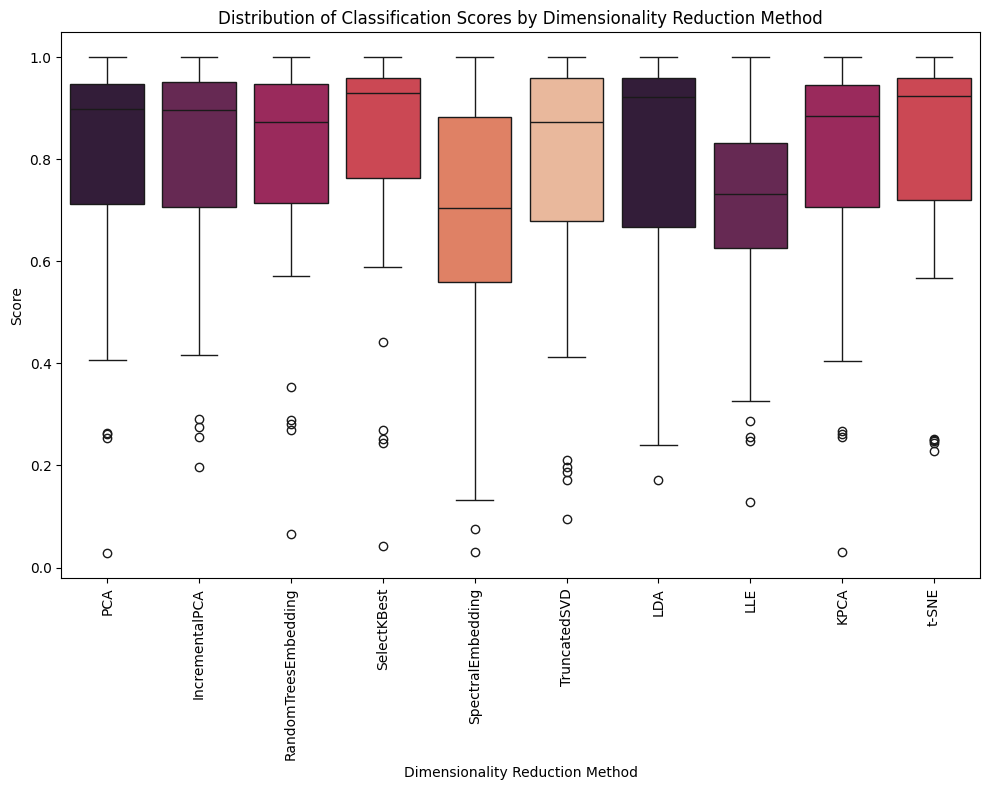

In [ ]:
# Score Distribution by Dimensionality Reduction Method

import seaborn as sns
import matplotlib.pyplot as plt

# Convert from wide format to long format for plotting
df_melted = df_DR_technique_result.melt(
    var_name="Algorithm",
    value_name="Score"
)

plt.figure(figsize=(10, 8))
sns.boxplot(
    data=df_melted,
    x="Algorithm",
    y="Score",
    palette=sns.color_palette("rocket")
)

plt.xticks(rotation=90)
plt.title("Distribution of Classification Scores by Dimensionality Reduction Method")
plt.xlabel("Dimensionality Reduction Method")
plt.ylabel("Score")
plt.tight_layout()
plt.show()

In [ ]:
# Ranking of Dimensionality Reduction Methods


# Apply ranking (row-wise)
df_ranking_algorithms = df_DR_technique_result.rank(
    axis=1,
    method='average',
    ascending=False
)

# Convert rankings to integer values
df_ranking_algorithms = df_ranking_algorithms.astype(int)


# Display
df_ranking_algorithms.head(10)

,PCA,IncrementalPCA,RandomTreesEmbedding,SelectKBest,SpectralEmbedding,TruncatedSVD,LDA,LLE,KPCA,t-SNE
0,6,6,6,6,6,6,6,1,6,6
1,4,4,8,1,10,6,4,9,2,7
2,7,7,4,1,5,9,2,10,7,3
3,5,5,5,5,5,5,5,5,5,5
4,4,4,8,4,9,7,1,10,4,4
5,4,5,7,3,8,9,2,10,6,1
6,2,2,5,1,9,8,5,10,7,4
7,6,6,8,3,10,1,3,9,6,1
8,5,6,8,3,10,4,1,9,7,2
9,4,5,8,3,10,7,2,9,6,1


Before performing the meta-learning stage, the classification results obtained from each dimensionality reduction method are transformed into a ranking representation. This step is important because the meta-model learns to recommend the best technique based on relative performance rather than absolute scores.

For each dataset (row), the algorithms are ranked according to their classification performance, where higher scores receive better positions (i.e., rank 1 corresponds to the best-performing method). This is achieved using a descending ranking strategy. In the presence of ties, the average ranking method is adopted, assigning the mean rank to tied values. Finally, the ranking values are converted to integers to standardize the representation.

# Meta Data

In [ ]:
# Building Meta-Datasets from Meta-Features and Algorithm Rankings


# This section loads the meta-feature groups, removes unnecessary columns,
# handles missing values, merges them with the algorithm rankings, and
# creates separate and unified meta-datasets.

import pandas as pd


def load_metafeatures(csv_path, drop_name=True):
    """
    Load a meta-feature dataset from a CSV file.

    Parameters
    ----------
    csv_path : str
        Path to the CSV file.
    drop_name : bool, optional
        Whether to drop the 'Name' column. Default is True.

    Returns
    -------
    pd.DataFrame
        Loaded meta-feature DataFrame.
    """
    df = pd.read_csv(csv_path)

    if drop_name and "Name" in df.columns:
        df = df.drop(columns=["Name"])

    return df


def preprocess_general_metafeatures(df):
    """
    Apply preprocessing steps specific to general meta-features.
    """
    if "num_to_cat" in df.columns:
        df["num_to_cat"] = df["num_to_cat"].fillna(0)

    return df


def preprocess_statistical_metafeatures(df):
    """
    Apply preprocessing steps specific to statistical meta-features.
    """
    if "sd_ratio" in df.columns:
        df["sd_ratio"] = df["sd_ratio"].fillna(0)

    return df


def merge_with_rankings(metafeatures_df, rankings_df, include_name=False, dataset_names=None):
    """
    Merge a meta-feature dataset with the algorithm ranking dataset.

    Parameters
    ----------
    metafeatures_df : pd.DataFrame
        Meta-feature DataFrame.
    rankings_df : pd.DataFrame
        Ranking DataFrame.
    include_name : bool, optional
        Whether to include the 'Name' column in the final DataFrame.
    dataset_names : pd.Series or pd.DataFrame, optional
        Dataset names to include when include_name=True.

    Returns
    -------
    pd.DataFrame
        Combined DataFrame.
    """
    rankings_only = rankings_df.copy()

    if "Name" in rankings_only.columns:
        rankings_only = rankings_only.drop(columns=["Name"])

    merged_df = pd.concat([metafeatures_df.reset_index(drop=True),
                           rankings_only.reset_index(drop=True)], axis=1)

    if include_name and dataset_names is not None:
        merged_df.insert(0, "Name", dataset_names.reset_index(drop=True))

    return merged_df


def save_dataframe(df, output_path):
    """
    Save a DataFrame to CSV.
    """
    df.to_csv(output_path, index=False)
    print(f"File saved to: {output_path}")


# Load ranking dataset
dataset_names = df_ranking_algorithms["Name"] if "Name" in df_ranking_algorithms.columns else None

General + Ranking

In [ ]:
# General meta-features + rankings
general_metafeatures = load_metafeatures(
    "data/metafeatures/metaGeneral.csv"
)
general_metafeatures = preprocess_general_metafeatures(general_metafeatures)

general_meta_dataset = merge_with_rankings(
    metafeatures_df=general_metafeatures,
    rankings_df=df_ranking_algorithms,
    include_name=False
)

general_meta_dataset.head(10)

,attr_to_inst,cat_to_num,freq_class.mean,freq_class.sd,inst_to_attr,nr_attr,nr_bin,nr_cat,nr_class,nr_inst,...,PCA,IncrementalPCA,RandomTreesEmbedding,SelectKBest,SpectralEmbedding,TruncatedSVD,LDA,LLE,KPCA,t-SNE
0,0.382360,0.0,0.500000,0.657280,2.615337,1617.0,1617.0,0.0,2.0,4229.0,...,6,6,6,6,6,6,6,1,6,6
1,101.286364,0.0,0.333333,0.215386,0.009873,22283.0,0.0,0.0,3.0,220.0,...,4,4,8,1,10,6,4,9,2,7
2,99.013889,0.0,0.500000,0.216060,0.010100,7129.0,0.0,0.0,2.0,72.0,...,7,7,4,1,5,9,2,10,7,3
3,118.816667,0.0,0.500000,0.212132,0.008416,7129.0,0.0,0.0,2.0,60.0,...,5,5,5,5,5,5,5,5,5,5
4,26.476998,0.0,0.500000,0.470834,0.037769,10935.0,0.0,0.0,2.0,413.0,...,4,4,8,4,9,7,1,10,4,4
5,27.000000,0.0,0.500000,0.494102,0.037037,10935.0,0.0,0.0,2.0,405.0,...,4,5,7,3,8,9,2,10,6,1
6,54.402985,0.0,0.500000,0.165343,0.018381,10935.0,0.0,0.0,2.0,201.0,...,2,2,5,1,9,8,5,10,7,4
7,74.897260,0.0,0.500000,0.038746,0.013352,10935.0,0.0,0.0,2.0,146.0,...,6,6,8,3,10,1,3,9,6,1
8,26.541262,0.0,0.500000,0.274605,0.037677,10935.0,0.0,0.0,2.0,412.0,...,5,6,8,3,10,4,1,9,7,2
9,25.973872,0.0,0.500000,0.448450,0.038500,10935.0,0.0,0.0,2.0,421.0,...,4,5,8,3,10,7,2,9,6,1


Info-Theory + Ranking

In [ ]:
# Info-Theory meta-features + rankings
info_theory_metafeatures = load_metafeatures(
    "data/metafeatures/metaInfo_Theory.csv"
)

info_theory_meta_dataset = merge_with_rankings(
    metafeatures_df=info_theory_metafeatures,
    rankings_df=df_ranking_algorithms,
    include_name=False
)

# save_dataframe(
#     info_theory_meta_dataset,
#     "data/metafeatures/metaInfoTheoryDone.csv"
# )

info_theory_meta_dataset.head(10)

,attr_conc.mean,attr_conc.sd,attr_ent.mean,attr_ent.sd,class_conc.mean,class_conc.sd,class_ent,eq_num_attr,joint_ent.mean,joint_ent.sd,...,PCA,IncrementalPCA,RandomTreesEmbedding,SelectKBest,SpectralEmbedding,TruncatedSVD,LDA,LLE,KPCA,t-SNE
0,0.002404,0.004523,0.338310,0.251443,0.003001,0.006497,0.219991,169.254459,0.557002,0.251567,...,6,6,6,6,6,6,6,1,6,6
1,0.029238,0.013125,2.584579,0.000446,0.025716,0.021285,1.398209,14.208982,3.884385,0.081330,...,4,4,8,1,10,6,4,9,2,7
2,0.051183,0.025315,1.999609,0.000948,0.027786,0.027083,0.931563,14.585876,2.867304,0.066434,...,7,7,4,1,5,9,2,10,7,3
3,0.044091,0.035887,1.584761,0.000660,0.018578,0.017420,0.934068,34.051336,2.491398,0.026254,...,5,5,5,5,5,5,5,5,5,5
4,0.018462,0.005066,2.807348,0.000049,0.022011,0.024876,0.650959,6.840619,3.363145,0.095751,...,4,4,8,4,9,7,1,10,4,4
5,0.021807,0.010189,2.807320,0.000051,0.011919,0.014180,0.611383,12.215610,3.368653,0.052994,...,4,5,7,3,8,9,2,10,6,1
6,0.024423,0.006968,2.321846,0.000064,0.017836,0.017339,0.960191,17.791645,3.228069,0.055016,...,2,2,5,1,9,8,5,10,7,4
7,0.037413,0.014752,2.321780,0.000108,0.058624,0.049166,0.997833,5.074191,3.122964,0.180158,...,6,6,8,3,10,1,3,9,6,1
8,0.029732,0.013890,2.807321,0.000046,0.017166,0.018334,0.888295,11.529496,3.618571,0.085964,...,5,6,8,3,10,4,1,9,7,2
9,0.021769,0.007780,2.807285,0.000060,0.008922,0.011625,0.686376,18.091753,3.455722,0.046258,...,4,5,8,3,10,7,2,9,6,1


Statistical + Ranking

In [ ]:
# Statistical meta-features + rankings
statistical_metafeatures = load_metafeatures(
    "data/metafeatures/metaStatistical.csv"
)
statistical_metafeatures = preprocess_statistical_metafeatures(statistical_metafeatures)

statistical_meta_dataset = merge_with_rankings(
    metafeatures_df=statistical_metafeatures,
    rankings_df=df_ranking_algorithms,
    include_name=False
)

# save_dataframe(
#     statistical_meta_dataset,
#     "data/metafeatures/metaStatisticalDone.csv"
# )

statistical_meta_dataset.head(10)

,can_cor.mean,can_cor.sd,cor.mean,cor.sd,cov.mean,cov.sd,eigenvalues.mean,eigenvalues.sd,g_mean.mean,g_mean.sd,...,PCA,IncrementalPCA,RandomTreesEmbedding,SelectKBest,SpectralEmbedding,TruncatedSVD,LDA,LLE,KPCA,t-SNE
0,0.731098,NaN,0.050081,0.078462,0.003357,7.494719e-03,6.576205e-02,3.362771e-01,0.000000,0.000000,...,6,6,6,6,6,6,6,1,6,6
1,1.000000,0.0,0.154836,0.122138,0.008221,1.266181e-02,6.933508e-02,2.256094e+00,5.750332,0.962942,...,4,4,8,1,10,6,4,9,2,7
2,1.000000,NaN,0.164218,0.131973,28619.752111,1.902279e+05,8.002843e+05,1.710408e+07,NaN,NaN,...,7,7,4,1,5,9,2,10,7,3
3,1.000000,NaN,0.192160,0.147450,57883.117577,4.719847e+05,1.362835e+06,4.424640e+07,NaN,NaN,...,5,5,5,5,5,5,5,5,5,5
4,1.000000,NaN,0.114544,0.098494,437840.524844,4.248468e+06,1.356013e+07,4.554316e+08,2949.861280,6962.491589,...,4,4,8,4,9,7,1,10,4,4
5,1.000000,NaN,0.104168,0.090397,396323.834189,4.213198e+06,1.325389e+07,4.513052e+08,2968.849863,7040.214046,...,4,5,7,3,8,9,2,10,6,1
6,1.000000,NaN,0.114094,0.094706,412902.897401,4.413396e+06,1.255906e+07,4.698115e+08,2995.888767,7063.141249,...,2,2,5,1,9,8,5,10,7,4
7,1.000000,NaN,0.160697,0.127178,561568.254079,4.623830e+06,1.279922e+07,4.936319e+08,2945.889509,7029.246069,...,6,6,8,3,10,1,3,9,6,1
8,1.000000,NaN,0.119234,0.100036,436024.943697,4.507870e+06,1.346047e+07,4.815145e+08,3067.799741,7264.580337,...,5,6,8,3,10,4,1,9,7,2
9,1.000000,NaN,0.103309,0.089101,399934.913337,4.478665e+06,1.359576e+07,4.793113e+08,2979.797860,7013.938502,...,4,5,8,3,10,7,2,9,6,1


All Meta-Features + Ranking

In [ ]:
# All meta-features + rankings
all_metafeatures = pd.concat(
    [
        general_metafeatures.reset_index(drop=True),
        info_theory_metafeatures.reset_index(drop=True),
        statistical_metafeatures.reset_index(drop=True)
    ],
    axis=1
)

# Remove duplicated columns if they exist
all_metafeatures = all_metafeatures.loc[:, ~all_metafeatures.columns.duplicated()]

# Fill missing values
all_metafeatures = all_metafeatures.fillna(0)

all_meta_dataset = merge_with_rankings(
    metafeatures_df=all_metafeatures,
    rankings_df=df_ranking_algorithms,
    include_name=False
)

# save_dataframe(
#     all_meta_dataset,
#     "data/metafeatures/AllMetaFeaturesDone.csv"
# )

all_meta_dataset.head(10)

# Meta-Model

In [ ]:
# Training Meta-Models with Different Meta-Feature Groups

# This section trains meta-models using different groups of meta-features.
# The input variables are the meta-features extracted from the datasets,
# and the targets are the algorithm rankings.
# A RandomForestClassifier is evaluated with Leave-One-Out cross-validation.

import pandas as pd
import numpy as np
from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier


# Target columns (algorithm rankings)
TARGET_COLUMNS = [
    'PCA', 'IncrementalPCA', 'RandomTreesEmbedding', 'SelectKBest',
    'SpectralEmbedding', 'TruncatedSVD', 'LDA', 'LLE', 'KPCA', 't-SNE'
]


# Feature groups
GENERAL_FEATURES = [
    'attr_to_inst', 'cat_to_num', 'freq_class.mean', 'freq_class.sd',
    'inst_to_attr', 'nr_attr', 'nr_bin', 'nr_cat',
    'nr_class', 'nr_inst', 'nr_num', 'num_to_cat'
]

INFO_THEORY_FEATURES = [
    'attr_conc.mean', 'attr_conc.sd', 'attr_ent.mean', 'attr_ent.sd',
    'class_conc.mean', 'class_conc.sd', 'class_ent', 'eq_num_attr',
    'joint_ent.mean', 'joint_ent.sd', 'mut_inf.mean', 'mut_inf.sd',
    'ns_ratio'
]

STATISTICAL_FEATURES = [
    'can_cor.mean', 'can_cor.sd', 'cor.mean', 'cor.sd', 'cov.mean',
    'cov.sd', 'eigenvalues.mean', 'eigenvalues.sd', 'g_mean.mean',
    'g_mean.sd', 'gravity', 'h_mean.mean', 'h_mean.sd', 'iq_range.mean',
    'iq_range.sd', 'kurtosis.mean', 'kurtosis.sd', 'lh_trace', 'mad.mean',
    'mad.sd', 'max.mean', 'max.sd', 'mean.mean', 'mean.sd', 'median.mean',
    'median.sd', 'min.mean', 'min.sd', 'nr_cor_attr', 'nr_disc', 'nr_norm',
    'nr_outliers', 'p_trace', 'range.mean', 'range.sd', 'roy_root',
    'sd.mean', 'sd.sd', 'sd_ratio', 'skewness.mean', 'skewness.sd',
    'sparsity.mean', 'sparsity.sd', 't_mean.mean', 't_mean.sd', 'var.mean',
    'var.sd', 'w_lambda'
]

ALL_FEATURES = GENERAL_FEATURES + INFO_THEORY_FEATURES + STATISTICAL_FEATURES


# Helper functions
def prepare_features(dataframe, feature_columns):
    """
    Select, clean, and scale the predictive features.
    """
    X = dataframe[feature_columns].copy()
    X = X.fillna(0)
    X = X.replace([np.inf, -np.inf], 0)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    return X_scaled


def train_meta_model_loo(dataframe, feature_columns, target_columns, output_filename, model=None):
    """
    Train one meta-model per target using Leave-One-Out cross-validation.

    Parameters
    ----------
    dataframe : pd.DataFrame
        Meta-dataset containing predictive features and ranking targets.
    feature_columns : list
        List of feature column names.
    target_columns : list
        List of target column names.
    output_filename : str
        Output CSV filename for predictions.
    model : sklearn classifier, optional
        Classification model. If None, a default RandomForestClassifier is used.

    Returns
    -------
    pd.DataFrame
        DataFrame containing the predicted rankings for all targets.
    """
    if model is None:
        model = RandomForestClassifier(
            n_estimators=100,
            random_state=42,
            n_jobs=-1,
            min_samples_split=4,
            min_samples_leaf=3
        )

    X_scaled = prepare_features(dataframe, feature_columns)
    y_all = dataframe[target_columns].copy()

    loo = LeaveOneOut()
    prediction_dict = {}

    print("Starting meta-learning process...\n")

    for target in target_columns:
        print(f"Training meta-model for target: {target}")

        y = y_all[target]
        fold_predictions = []

        for train_index, test_index in loo.split(X_scaled):
            X_train, X_test = X_scaled[train_index], X_scaled[test_index]
            y_train = y.iloc[train_index]

            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            fold_predictions.append(y_pred[0])

        prediction_dict[f'PredictedRank_{target}'] = pd.Series(fold_predictions)

    predictions_df = pd.DataFrame(prediction_dict)
    predictions_df.to_csv(output_filename, index=False)

    print(f"\nProcess completed. Predictions saved to: {output_filename}")
    print("\nFirst 5 rows:")
    print(predictions_df.head())

    return predictions_df

General meta-features

In [ ]:
# Meta-learning with General Meta-Features
predictions_general = train_meta_model_loo(
    dataframe=general_meta_dataset,
    feature_columns=GENERAL_FEATURES,
    target_columns=TARGET_COLUMNS,
    output_filename='predictions_ranking_MetaGeneral.csv'
)

Starting meta-learning process...

Training meta-model for target: PCA
Training meta-model for target: IncrementalPCA
Training meta-model for target: RandomTreesEmbedding
Training meta-model for target: SelectKBest
Training meta-model for target: SpectralEmbedding
Training meta-model for target: TruncatedSVD
Training meta-model for target: LDA
Training meta-model for target: LLE
Training meta-model for target: KPCA
Training meta-model for target: t-SNE

Process completed. Predictions saved to: predictions_ranking_MetaGeneral.csv

First 5 rows:
   PredictedRank_PCA  PredictedRank_IncrementalPCA  \
0                  3                             4   
1                  5                             5   
2                  5                             5   
3                  7                             5   
4                  4                             5   

   PredictedRank_RandomTreesEmbedding  PredictedRank_SelectKBest  \
0                                   3                    

Info-Theory meta-features

In [ ]:
# Meta-learning with Info-Theory Meta-Features
predictions_info_theory = train_meta_model_loo(
    dataframe=info_theory_meta_dataset,
    feature_columns=INFO_THEORY_FEATURES,
    target_columns=TARGET_COLUMNS,
    output_filename='predictions_ranking_MetaInfoTheory.csv'
)

Starting meta-learning process...

Training meta-model for target: PCA
Training meta-model for target: IncrementalPCA
Training meta-model for target: RandomTreesEmbedding
Training meta-model for target: SelectKBest
Training meta-model for target: SpectralEmbedding
Training meta-model for target: TruncatedSVD
Training meta-model for target: LDA
Training meta-model for target: LLE
Training meta-model for target: KPCA
Training meta-model for target: t-SNE

Process completed. Predictions saved to: predictions_ranking_MetaInfoTheory.csv

First 5 rows:
   PredictedRank_PCA  PredictedRank_IncrementalPCA  \
0                  5                             5   
1                  5                             6   
2                  5                             5   
3                  5                             5   
4                  7                             7   

   PredictedRank_RandomTreesEmbedding  PredictedRank_SelectKBest  \
0                                   4                 

Statistical meta-features

In [ ]:
# Meta-learning with Statistical Meta-Features
predictions_statistical = train_meta_model_loo(
    dataframe=statistical_meta_dataset,
    feature_columns=STATISTICAL_FEATURES,
    target_columns=TARGET_COLUMNS,
    output_filename='predictions_ranking_MetaStatistical.csv'
)

Starting meta-learning process...

Training meta-model for target: PCA
Training meta-model for target: IncrementalPCA
Training meta-model for target: RandomTreesEmbedding
Training meta-model for target: SelectKBest
Training meta-model for target: SpectralEmbedding
Training meta-model for target: TruncatedSVD
Training meta-model for target: LDA
Training meta-model for target: LLE
Training meta-model for target: KPCA
Training meta-model for target: t-SNE

Process completed. Predictions saved to: predictions_ranking_MetaStatistical.csv

First 5 rows:
   PredictedRank_PCA  PredictedRank_IncrementalPCA  \
0                  3                             4   
1                  5                             5   
2                  5                             5   
3                  7                             5   
4                  4                             5   

   PredictedRank_RandomTreesEmbedding  PredictedRank_SelectKBest  \
0                                   4                

All meta-features

In [ ]:
# Meta-learning with All Meta-Features
predictions_all = train_meta_model_loo(
    dataframe=all_meta_dataset,
    feature_columns=ALL_FEATURES,
    target_columns=TARGET_COLUMNS,
    output_filename='predictions_ranking_AllMetaFeatures.csv'
)

Starting meta-learning process...

Training meta-model for target: PCA
Training meta-model for target: IncrementalPCA
Training meta-model for target: RandomTreesEmbedding
Training meta-model for target: SelectKBest
Training meta-model for target: SpectralEmbedding
Training meta-model for target: TruncatedSVD
Training meta-model for target: LDA
Training meta-model for target: LLE
Training meta-model for target: KPCA
Training meta-model for target: t-SNE

Process completed. Predictions saved to: predictions_ranking_AllMetaFeatures.csv

First 5 rows:
   PredictedRank_PCA  PredictedRank_IncrementalPCA  \
0                  3                             1   
1                  5                             5   
2                  5                             5   
3                  5                             7   
4                  4                             5   

   PredictedRank_RandomTreesEmbedding  PredictedRank_SelectKBest  \
0                                   4                

# Spearman Rank Correlation (SRC) Evaluation

## Meta-Data Ranking vs. Dimensionality Reduction Algorithm Ranking (Using General Meta-Features)






[0.5238227218271836, 0.6230559828490335, -0.27648742075652954, 0.0, 0.7024993911328272, 0.6768418509842056, 0.843558282208589, 0.6163522012578617, 0.8632258720256917, 0.8896375227527807, 0.725623245649734, 0.8527607361963191, 0.9223377098533675, 0.4875095217633339, 0.6962019024007138, 0.9878048780487806, 0.39877300613496935, 0.8324552526702391, 0.6338731596684772, 0.4861561474901688, 0.8024353176576852, 0.47977173183430455, 0.4573255749893281, 0.5329808342062615, -0.3262334552859464, 0.9662682041877618, 0.695188575959692, 0.28659069365997897, 0.27244712614795025, 0.8762659853067879, 0.8353658536585367, 0.6831577749352966, 0.9268464986450384, 0.4417261042993862, 0.8271762533175799, 0.5260160211159278, 0.6975840276337727, 0.6585934948473268, 0.7699531401329579, 0.6739650469541836, 0.37500000000000006, 0.9329441729782294, 0.4969418673368095, 0.6758441388478289, 0.6731618328060892, 0.9146511499786562, 0.5184049079754601, 0.5785300076028639, 0.8719674296463189, 0.7683069659820713, 0.0, 0.37

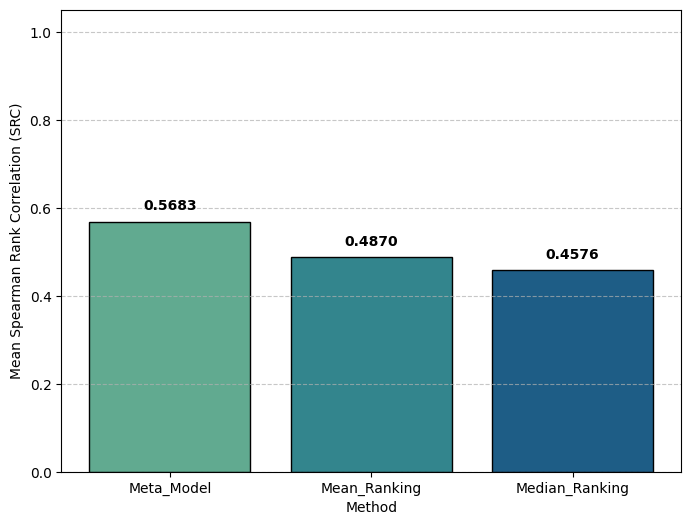

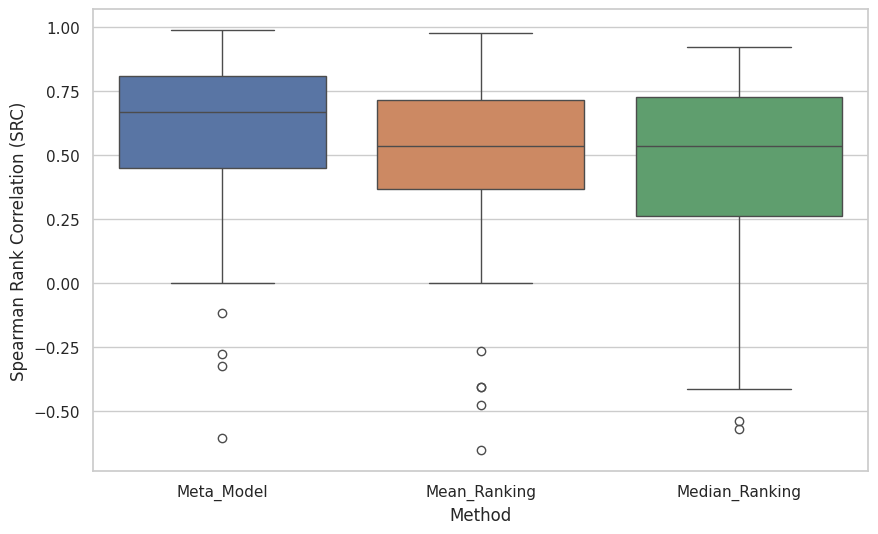

In [ ]:
from scipy.stats import spearmanr
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import LeaveOneOut

# Load predicted rankings (General Meta-Features)
df_predicted_ranking_general = pd.read_csv(
    'data/predictions/predictions_ranking_MetaGeneral.csv'
)

df_predicted_ranking_general.head()


# Compute Spearman correlation (True vs Predicted)

spearman_values_general = []

for i in range(len(df_ranking_algorithms)):
    true_rank = df_ranking_algorithms.iloc[i].tolist()
    predicted_rank = df_predicted_ranking_general.iloc[i].tolist()

    # Check for invalid cases (NaN or constant values)
    if (len(set(true_rank)) <= 1 or len(set(predicted_rank)) <= 1
        or np.isnan(true_rank).any() or np.isnan(predicted_rank).any()):
        spearman_values_general.append(np.nan)
        continue

    coef, _ = spearmanr(true_rank, predicted_rank)
    spearman_values_general.append(coef)

# Replace NaN with 0
spearman_values_general = np.nan_to_num(spearman_values_general, nan=0.0).tolist()

print(spearman_values_general)


# Baseline comparison (Mean and Median rankings)


# Convert true rankings to DataFrame
true_rankings = df_ranking_algorithms.values.tolist()
df_true_rankings = pd.DataFrame(true_rankings)

loo = LeaveOneOut()

baseline_results_general = []

for train_index, test_index in loo.split(df_true_rankings):
    df_train = df_true_rankings.iloc[train_index]
    df_test = df_true_rankings.iloc[test_index]

    # Compute mean and median rankings from training set
    mean_ranking = df_train.mean()
    median_ranking = df_train.median()

    # Compare test instance with baseline rankings
    rho_mean, _ = spearmanr(df_test.values.flatten(), mean_ranking.values)
    rho_median, _ = spearmanr(df_test.values.flatten(), median_ranking.values)

    baseline_results_general.append({
        "spearman_mean": rho_mean,
        "spearman_median": rho_median
    })

# Convert results to DataFrame
df_baseline_general = pd.DataFrame(baseline_results_general).fillna(0.0)


# Combine results
df_model = pd.DataFrame(spearman_values_general, columns=['Meta_Model'])

df_baseline_general = df_baseline_general.rename(columns={
    "spearman_mean": "Mean_Ranking",
    "spearman_median": "Median_Ranking"
})

df_comparative_general = pd.concat([df_model, df_baseline_general], axis=1)

df_comparative_general


# Bar plot (mean SRC per method)

mean_values = df_comparative_general.mean()

colors = sns.color_palette("crest", n_colors=len(mean_values))

plt.figure(figsize=(8,6))
bars = plt.bar(mean_values.index, mean_values.values,
               color=colors, edgecolor="black")

plt.ylabel("Mean Spearman Rank Correlation (SRC)")
plt.xlabel("Method")
plt.ylim(0, 1.05)

# Add values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.02,
        f"{height:.4f}",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


# Boxplot (distribution of SRC)
sns.set(style="whitegrid")

plt.figure(figsize=(10,6))
sns.boxplot(data=df_comparative_general)

plt.ylabel("Spearman Rank Correlation (SRC)")
plt.xlabel("Method")

plt.show()

## Meta-Model Ranking vs. Dimensionality Reduction Algorithm Ranking (Statistical Meta-Features)

[-0.17460757394239454, 0.6963280627604909, -0.05874228140418678, 0.0, 0.8781242389160339, 0.947804480540862, 0.839045479071856, 0.5812613528716672, 0.8196063584829573, 0.9632626970495626, 0.8273023616772436, 0.8765599102320624, 0.9285697214064309, 0.8500166020488897, 0.7767620419337038, 0.9785032270610473, 0.33537208832550724, 0.8324552526702391, 0.6873888647989644, 0.30275370925762474, 0.4800568148193976, 0.3333478915991596, 0.5731813873199579, 0.7844362864789778, -0.28945576764269265, 0.9390418473114204, 0.6720290524011977, 0.8048930119812175, 0.4615581259721921, 0.9510747836274878, 0.8449887057152897, 0.5957474328064633, 0.9725179925282851, 0.6169691437532663, 0.8562731170922719, 0.7744046403152623, 0.9386679716361958, 0.7438122780519578, 0.7682926829268294, 0.8576221317450335, 0.43865856190841823, 0.9541685964428458, 0.9383431168171102, 0.6146817733412381, 0.87806510397951, 0.8719674296463189, 0.33437974811719723, 0.4146418546569909, 0.8875420937728943, 0.6606060606060605, -0.02446

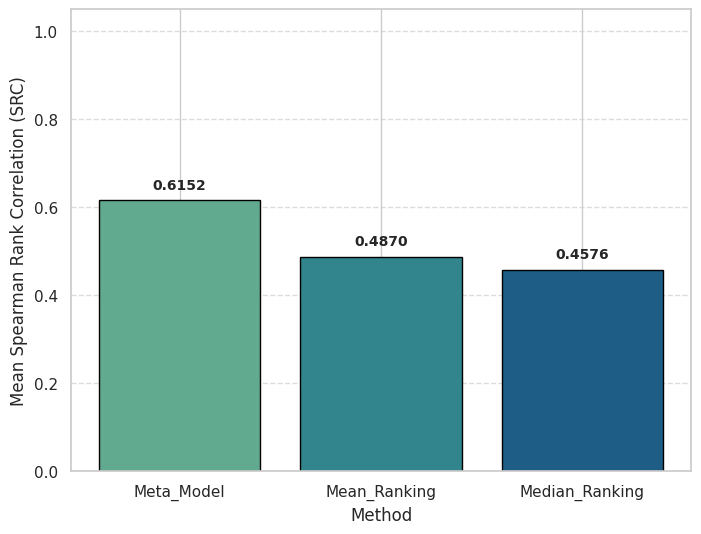

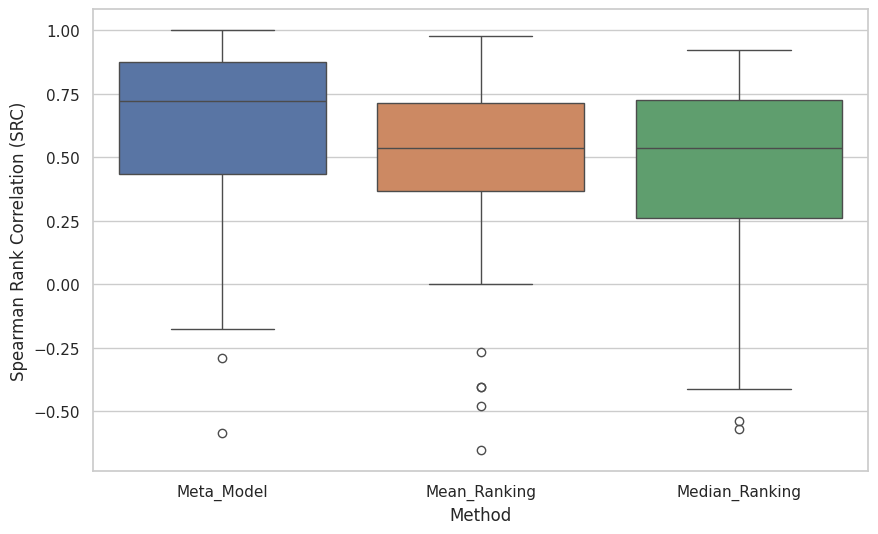

In [ ]:
# Load predicted rankings (Statistical Meta-Features)
df_predicted_ranking_statistical = pd.read_csv(
    'data/predictions/predictions_ranking_metaStatistical.csv'
)

df_predicted_ranking_statistical.head()


# Compute Spearman correlation (True vs Predicted)


spearman_values_statistical = []

for i in range(len(df_ranking_algorithms)):
    true_rank = df_ranking_algorithms.iloc[i].tolist()
    predicted_rank = df_predicted_ranking_statistical.iloc[i].tolist()

    # Check for invalid cases (NaN or constant values)
    if (len(set(true_rank)) <= 1 or len(set(predicted_rank)) <= 1
        or np.isnan(true_rank).any() or np.isnan(predicted_rank).any()):
        spearman_values_statistical.append(np.nan)
        continue

    coef, _ = spearmanr(true_rank, predicted_rank)
    spearman_values_statistical.append(coef)

# Replace NaN values with 0
spearman_values_statistical = np.nan_to_num(spearman_values_statistical, nan=0.0).tolist()
print(spearman_values_statistical)


# Baseline comparison (Mean and Median rankings)


# Convert true rankings to DataFrame
true_rankings = df_ranking_algorithms.values.tolist()
df_true_rankings = pd.DataFrame(true_rankings)

loo = LeaveOneOut()

baseline_results_statistical = []

for train_index, test_index in loo.split(df_true_rankings):
    df_train = df_true_rankings.iloc[train_index]
    df_test = df_true_rankings.iloc[test_index]

    # Compute mean and median rankings from the training set
    mean_ranking = df_train.mean()
    median_ranking = df_train.median()

    # Compare the test instance with the baseline rankings
    rho_mean, _ = spearmanr(df_test.values.flatten(), mean_ranking.values)
    rho_median, _ = spearmanr(df_test.values.flatten(), median_ranking.values)

    baseline_results_statistical.append({
        "spearman_mean": rho_mean,
        "spearman_median": rho_median
    })

# Convert results to DataFrame
df_baseline_statistical = pd.DataFrame(baseline_results_statistical).fillna(0.0)
df_baseline_statistical


# Combine results
df_model_statistical = pd.DataFrame(spearman_values_statistical, columns=['Meta_Model'])

df_baseline_statistical = df_baseline_statistical.rename(columns={
    "spearman_mean": "Mean_Ranking",
    "spearman_median": "Median_Ranking"
})

df_comparative_statistical = pd.concat([df_model_statistical, df_baseline_statistical], axis=1)
df_comparative_statistical


# Bar plot (mean SRC per method)


mean_values_statistical = df_comparative_statistical.mean()

colors = sns.color_palette("crest", n_colors=len(mean_values_statistical))

plt.figure(figsize=(8, 6))
bars = plt.bar(
    mean_values_statistical.index,
    mean_values_statistical.values,
    color=colors,
    edgecolor="black"
)

plt.ylabel("Mean Spearman Rank Correlation (SRC)")
plt.xlabel("Method")
plt.xticks(rotation=0)
plt.ylim(0, 1.05)

# Add values on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.02,
        f"{height:.4f}",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


# Boxplot (distribution of SRC values)
sns.set(style="whitegrid")

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_comparative_statistical)

plt.ylabel("Spearman Rank Correlation (SRC)")
plt.xlabel("Method")

plt.show()

## Meta-Model Ranking vs. Dimensionality Reduction Algorithm Ranking (Info-Theory Meta-Features)

[-0.17622684421256032, 0.780189497605494, 0.5254069374927338, 0.0, 0.5170471542244311, 0.8746545467392752, 0.8343558282208591, 0.7272763007345028, 0.6768418509842056, 0.9541685964428458, 0.801256962397518, 0.6993865030674847, 0.752412135793461, 0.7227449401048789, 0.6962019024007138, 0.9570732259820034, 0.7730061349693254, 0.8910484281589318, 0.6391467195438745, 0.3220858895705522, 0.6686960980480711, 0.36648790571702144, 0.473902240270431, 0.424617394643312, -0.28682605876498013, 0.8624216160156492, 0.5774278648178492, 0.6914766008048604, 0.49383656914482393, 0.7256097560975611, 0.7920526333103515, 0.8282832108387959, 0.9817255676437577, 0.4724015282090658, 0.8576221317450335, 0.6686960980480711, 0.5969485095907018, 0.5974442695117377, 0.7006706826233026, 0.8409825257156243, 0.21646341463414634, 0.8685380813774621, 0.9298780487804879, 0.8681144966439326, 0.6707441766510146, 0.8528249356043897, 0.14110429447852763, 0.6523849021904634, 0.7987953376480265, 0.8510677611520905, 0.170213552

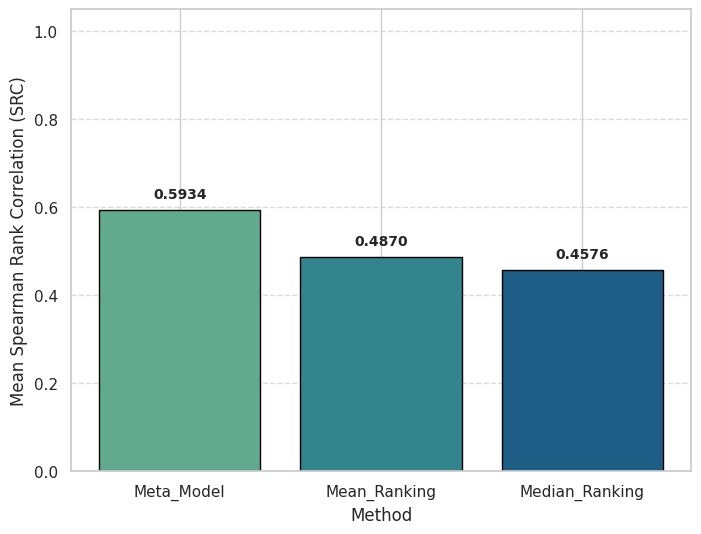

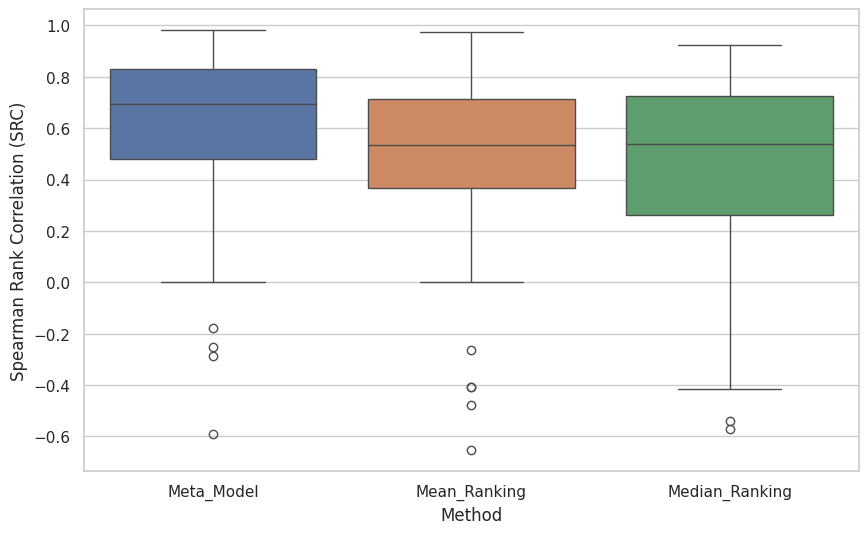

In [ ]:
# Load predicted rankings (Info-Theory Meta-Features)
df_predicted_ranking_info_theory = pd.read_csv(
    'data/predictions/predictions_ranking_metaInfoTheory.csv'
)

df_predicted_ranking_info_theory.head()


# Compute Spearman correlation (True vs Predicted)
from scipy.stats import spearmanr
import numpy as np
import pandas as pd
from sklearn.model_selection import LeaveOneOut

spearman_values_info_theory = []

for i in range(len(df_ranking_algorithms)):
    true_rank = df_ranking_algorithms.iloc[i].tolist()
    predicted_rank = df_predicted_ranking_info_theory.iloc[i].tolist()

    # Check for invalid cases (NaN or constant values)
    if (len(set(true_rank)) <= 1 or len(set(predicted_rank)) <= 1
        or np.isnan(true_rank).any() or np.isnan(predicted_rank).any()):
        spearman_values_info_theory.append(np.nan)
        continue

    coef, _ = spearmanr(true_rank, predicted_rank)
    spearman_values_info_theory.append(coef)

# Replace NaN values with 0
spearman_values_info_theory = np.nan_to_num(spearman_values_info_theory, nan=0.0).tolist()
print(spearman_values_info_theory)


# Baseline comparison (Mean and Median rankings)
true_rankings = df_ranking_algorithms.values.tolist()
df_true_rankings = pd.DataFrame(true_rankings)

loo = LeaveOneOut()

baseline_results_info_theory = []

for train_index, test_index in loo.split(df_true_rankings):
    df_train = df_true_rankings.iloc[train_index]
    df_test = df_true_rankings.iloc[test_index]

    # Compute mean and median rankings from the training set
    mean_ranking = df_train.mean()
    median_ranking = df_train.median()

    # Compare the test instance with the baseline rankings
    rho_mean, _ = spearmanr(df_test.values.flatten(), mean_ranking.values)
    rho_median, _ = spearmanr(df_test.values.flatten(), median_ranking.values)

    baseline_results_info_theory.append({
        "spearman_mean": rho_mean,
        "spearman_median": rho_median
    })

# Convert results to DataFrame
df_baseline_info_theory = pd.DataFrame(baseline_results_info_theory).fillna(0.0)
df_baseline_info_theory


# Combine results
df_model_info_theory = pd.DataFrame(
    spearman_values_info_theory,
    columns=['Meta_Model']
)

df_baseline_info_theory = df_baseline_info_theory.rename(columns={
    "spearman_mean": "Mean_Ranking",
    "spearman_median": "Median_Ranking"
})

df_comparative_info_theory = pd.concat(
    [df_model_info_theory, df_baseline_info_theory],
    axis=1
)

df_comparative_info_theory


# Bar plot (mean SRC per method)

mean_values_info_theory = df_comparative_info_theory.mean()

colors = sns.color_palette("crest", n_colors=len(mean_values_info_theory))

plt.figure(figsize=(8, 6))
bars = plt.bar(
    mean_values_info_theory.index,
    mean_values_info_theory.values,
    color=colors,
    edgecolor="black"
)

plt.ylabel("Mean Spearman Rank Correlation (SRC)")
plt.xlabel("Method")
plt.xticks(rotation=0)
plt.ylim(0, 1.05)

# Add values on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.02,
        f"{height:.4f}",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


# Boxplot (distribution of SRC values)
sns.set(style="whitegrid")

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_comparative_info_theory)

plt.ylabel("Spearman Rank Correlation (SRC)")
plt.xlabel("Method")

plt.show()

## Meta-Model Ranking vs. Dimensionality Reduction Algorithm Ranking (All Meta-Features)

[-0.1740776559556978, 0.6604805620762322, 0.3064873802040947, 0.0, 0.7133941748159873, 0.9358192003574065, 0.8012269881363402, 0.8338598965318006, 0.8087806670128277, 0.9848069807617047, 0.7717372776839959, 0.7822085889570553, 0.9010367552094533, 0.8500166020488897, 0.7531438174453121, 0.9785032270610473, 0.4294478527607362, 0.8324552526702391, 0.6625891564490793, 0.3363930102862497, 0.8024353176576852, 0.36338207600755523, 0.5731813873199579, 0.7844362864789778, -0.2992127036306486, 0.9573348703109935, 0.6899978076444864, 0.7653454385433384, 0.475317697801893, 0.9021448912222152, 0.8449887057152897, 0.731720919982925, 0.9757575757575757, 0.42729578082097786, 0.8738502904253667, 0.6829395253173965, 0.9386679716361958, 0.7155086391167684, 0.7682926829268294, 0.6319018404907977, 0.3761485478655337, 0.9573348703109935, 0.9383431168171102, 0.7256097560975611, 0.8493312877573959, 0.7987953376480265, 0.4768007519448923, 0.498482545817653, 0.8475767323135548, 0.6606060606060605, 0.06728111897

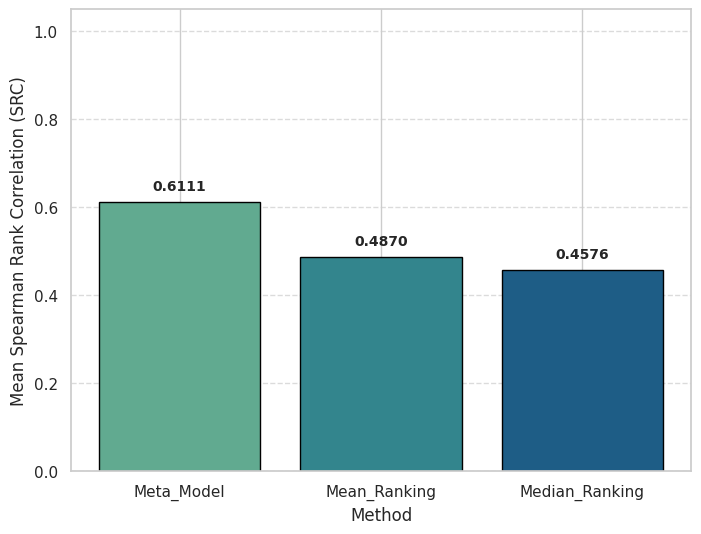

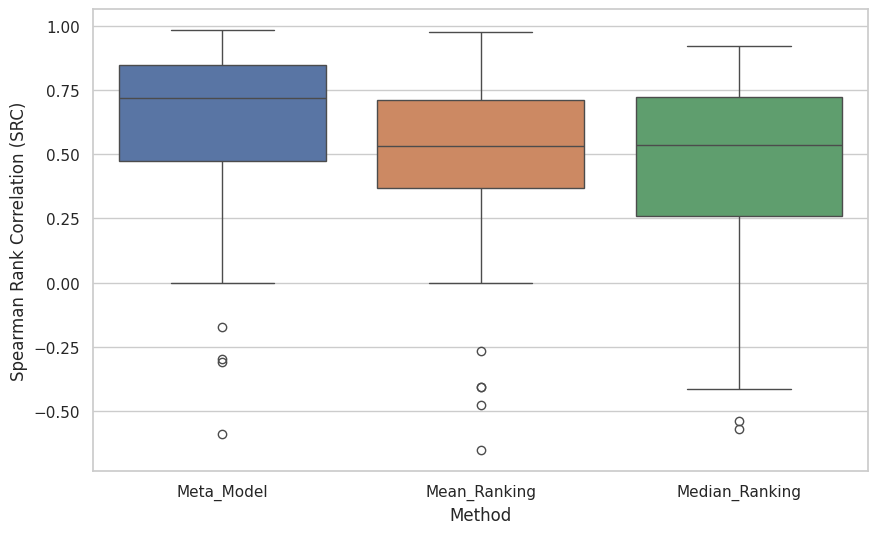

In [ ]:
# Load predicted rankings (All Meta-Features)
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
from sklearn.model_selection import LeaveOneOut
import matplotlib.pyplot as plt
import seaborn as sns

df_predicted_ranking_all_metafeatures = pd.read_csv(
    'data/predictions/predictions_rank_AllMetaFeatures.csv'
)

df_predicted_ranking_all_metafeatures.head()


# Compute Spearman correlation (True vs Predicted)
spearman_values_all_metafeatures = []

for i in range(len(df_ranking_algorithms)):
    true_rank = df_ranking_algorithms.iloc[i].tolist()
    predicted_rank = df_predicted_ranking_all_metafeatures.iloc[i].tolist()

    # Check for invalid cases (NaN or constant values)
    if (len(set(true_rank)) <= 1 or len(set(predicted_rank)) <= 1
        or np.isnan(true_rank).any() or np.isnan(predicted_rank).any()):
        spearman_values_all_metafeatures.append(np.nan)
        continue

    coef, _ = spearmanr(true_rank, predicted_rank)
    spearman_values_all_metafeatures.append(coef)

# Replace NaN values with 0
spearman_values_all_metafeatures = np.nan_to_num(
    spearman_values_all_metafeatures,
    nan=0.0
).tolist()

print(spearman_values_all_metafeatures)


# Baseline comparison (Mean and Median rankings)
true_rankings = df_ranking_algorithms.values.tolist()
df_true_rankings = pd.DataFrame(true_rankings)

loo = LeaveOneOut()

baseline_results_all_metafeatures = []

for train_index, test_index in loo.split(df_true_rankings):
    df_train = df_true_rankings.iloc[train_index]
    df_test = df_true_rankings.iloc[test_index]

    # Compute mean and median rankings from the training set
    mean_ranking = df_train.mean()
    median_ranking = df_train.median()

    # Compare the test instance with the baseline rankings
    rho_mean, _ = spearmanr(df_test.values.flatten(), mean_ranking.values)
    rho_median, _ = spearmanr(df_test.values.flatten(), median_ranking.values)

    baseline_results_all_metafeatures.append({
        "spearman_mean": rho_mean,
        "spearman_median": rho_median
    })

# Convert results to DataFrame
df_baseline_all_metafeatures = pd.DataFrame(
    baseline_results_all_metafeatures
).fillna(0.0)

df_baseline_all_metafeatures


# Combine results
df_model_all_metafeatures = pd.DataFrame(
    spearman_values_all_metafeatures,
    columns=['Meta_Model']
)

df_baseline_all_metafeatures = df_baseline_all_metafeatures.rename(columns={
    "spearman_mean": "Mean_Ranking",
    "spearman_median": "Median_Ranking"
})

df_comparative_all_metafeatures = pd.concat(
    [df_model_all_metafeatures, df_baseline_all_metafeatures],
    axis=1
)

df_comparative_all_metafeatures


# Bar plot (mean SRC per method)
mean_values_all_metafeatures = df_comparative_all_metafeatures.mean()

colors = sns.color_palette("crest", n_colors=len(mean_values_all_metafeatures))

plt.figure(figsize=(8, 6))
bars = plt.bar(
    mean_values_all_metafeatures.index,
    mean_values_all_metafeatures.values,
    color=colors,
    edgecolor="black"
)

plt.ylabel("Mean Spearman Rank Correlation (SRC)")
plt.xlabel("Method")
plt.xticks(rotation=0)
plt.ylim(0, 1.05)

# Add values on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.02,
        f"{height:.4f}",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


# Boxplot (distribution of SRC values)
sns.set(style="whitegrid")

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_comparative_all_metafeatures)

plt.ylabel("Spearman Rank Correlation (SRC)")
plt.xlabel("Method")

plt.show()

# Comparative Analysis of Spearman Rank Correlation Across Meta-DR Variants and Baselines


--- 95% Confidence Intervals, Mean SRC, and Margin of Error ---
                           Mean SRC  CI Lower (95%)  CI Upper (95%)  Margin of Error
Meta-DR (Gen. MFs)           0.5683          0.4890          0.6476           0.0793
Meta-DR (Stats. MFs)         0.6152          0.5299          0.7005           0.0853
Meta-DR (Info-Theory MFs)    0.5934          0.5137          0.6730           0.0797
Meta-DR (All MFs)            0.6111          0.5267          0.6955           0.0844
Mean Baseline                0.5018          0.4173          0.5863           0.0845
Median Baseline              0.4714          0.3854          0.5574           0.0860


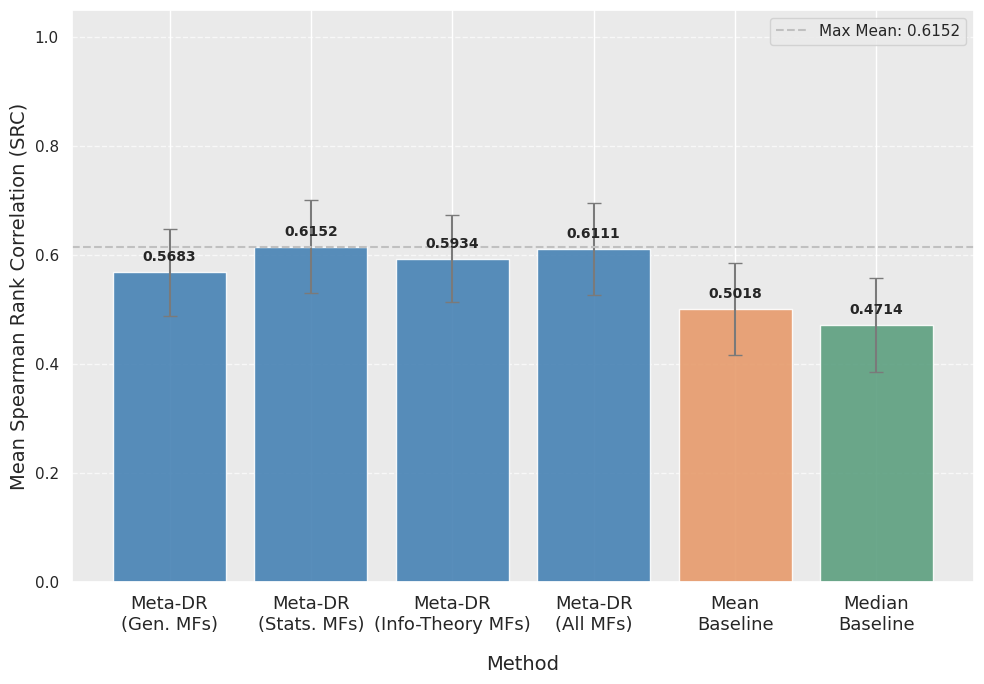

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# Build DataFrames for each Meta-DR variant
df_general = pd.concat(
    [
        pd.DataFrame(spearman_values_general, columns=["General Proposal"]),
        pd.DataFrame(baseline_results_general)
    ],
    axis=1
)

df_statistical = pd.concat(
    [
        pd.DataFrame(spearman_values_statistical, columns=["Statistical Proposal"]),
        pd.DataFrame(baseline_results_statistical)
    ],
    axis=1
)

df_info_theory = pd.concat(
    [
        pd.DataFrame(spearman_values_info_theory, columns=["Info-Theory Proposal"]),
        pd.DataFrame(baseline_results_info_theory)
    ],
    axis=1
)

df_all_metafeatures = pd.concat(
    [
        pd.DataFrame(spearman_values_all_metafeatures, columns=["Unified Proposal"]),
        pd.DataFrame(baseline_results_all_metafeatures)
    ],
    axis=1
)

# Rename baseline columns for consistency
for df in [df_general, df_statistical, df_info_theory, df_all_metafeatures]:
    df.rename(
        columns={
            "spearman_mean": "Mean Baseline",
            "spearman_median": "Median Baseline"
        },
        inplace=True
    )

# Combine all methods into a single DataFrame
df_combined = pd.DataFrame({
    "Meta-DR (Gen. MFs)": df_general["General Proposal"],
    "Meta-DR (Stats. MFs)": df_statistical["Statistical Proposal"],
    "Meta-DR (Info-Theory MFs)": df_info_theory["Info-Theory Proposal"],
    "Meta-DR (All MFs)": df_all_metafeatures["Unified Proposal"],
    "Mean Baseline": df_general["Mean Baseline"],
    "Median Baseline": df_general["Median Baseline"]
})

# Compute 95% confidence intervals
confidence_level = 0.95
alpha = 1 - confidence_level

means = df_combined.mean()
counts = df_combined.count()
stds = df_combined.std(ddof=1)
sems = stds / np.sqrt(counts)

try:
    margin_of_error = sems * stats.t.ppf(1 - alpha / 2, counts - 1)
except Exception as e:
    print(f"Warning: could not compute t-critical values. Error: {e}")
    margin_of_error = sems * 1.96

ci_lower = means - margin_of_error
ci_upper = means + margin_of_error

ci_df = pd.DataFrame({
    "Mean SRC": means,
    "CI Lower (95%)": ci_lower,
    "CI Upper (95%)": ci_upper,
    "Margin of Error": margin_of_error
}).reindex(means.index)

print("\n--- 95% Confidence Intervals, Mean SRC, and Margin of Error ---")
print(ci_df.to_string(float_format="{:.4f}".format))

# Bar plot with confidence intervals
sns.set_style("darkgrid")
sns.set(rc={"axes.facecolor": "#EAEAEA"})
plt.figure(figsize=(10, 7))

custom_colors = [
    "steelblue",  # Meta-DR (Gen. MFs)
    "steelblue",  # Meta-DR (Stats. MFs)
    "steelblue",  # Meta-DR (Info-Theory MFs)
    "steelblue",  # Meta-DR (All MFs)
    "#E79B6C",    # Mean Baseline
    "#5C9F7F"     # Median Baseline
]

bars = plt.bar(
    means.index,
    means.values,
    yerr=margin_of_error.values,
    capsize=5,
    color=custom_colors,
    ecolor="#7A7A7A",
    alpha=0.9
)

# Reference line for the highest mean value
max_value = means.values.max()
plt.axhline(
    y=max_value,
    color="silver",
    linestyle="--",
    linewidth=1.5,
    label=f"Max Mean: {max_value:.4f}"
)

new_labels = [
    "Meta-DR\n(Gen. MFs)",
    "Meta-DR\n(Stats. MFs)",
    "Meta-DR\n(Info-Theory MFs)",
    "Meta-DR\n(All MFs)",
    "Mean\nBaseline",
    "Median\nBaseline"
]

plt.ylabel("Mean Spearman Rank Correlation (SRC)", fontsize=14)
plt.xlabel("Method", fontsize=14, labelpad=15, x=0.5)
plt.xticks(ticks=range(len(new_labels)), labels=new_labels, rotation=0, fontsize=13)
plt.ylim(0, 1.05)

# Add values above bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.015,
        f"{height:.4f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.legend(loc="upper right")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()

plt.savefig(
    "src_distributionbarIC.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

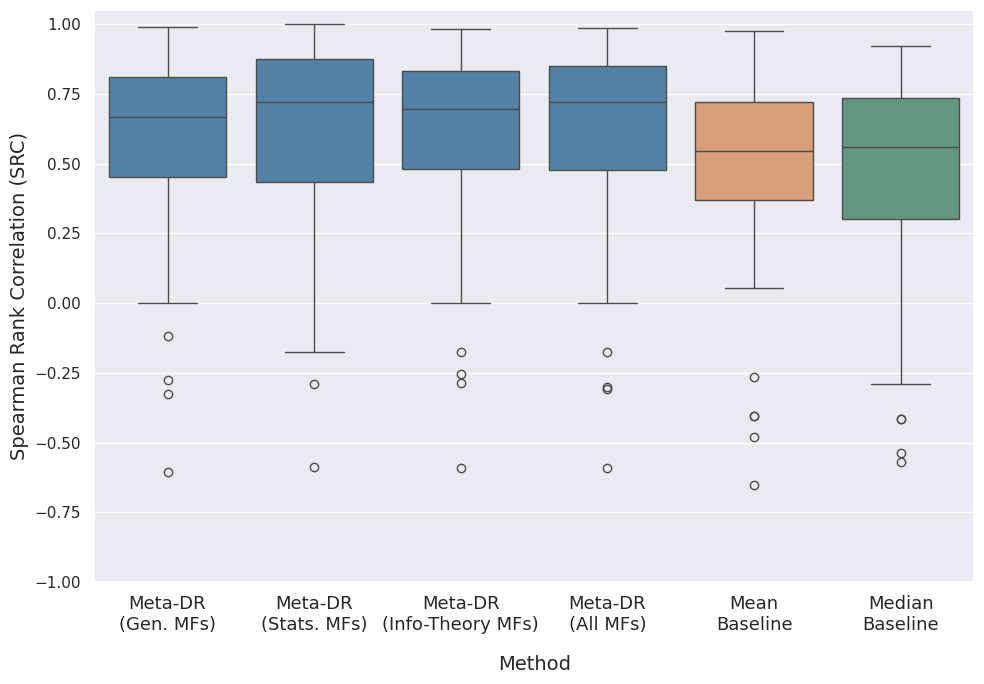

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Build DataFrames for each Meta-DR variant
df_general = pd.concat(
    [
        pd.DataFrame(spearman_values_general, columns=["General Proposal"]),
        pd.DataFrame(baseline_results_general)
    ],
    axis=1
)

df_statistical = pd.concat(
    [
        pd.DataFrame(spearman_values_statistical, columns=["Statistical Proposal"]),
        pd.DataFrame(baseline_results_statistical)
    ],
    axis=1
)

df_info_theory = pd.concat(
    [
        pd.DataFrame(spearman_values_info_theory, columns=["Info-Theory Proposal"]),
        pd.DataFrame(baseline_results_info_theory)
    ],
    axis=1
)

df_all_metafeatures = pd.concat(
    [
        pd.DataFrame(spearman_values_all_metafeatures, columns=["Unified Proposal"]),
        pd.DataFrame(baseline_results_all_metafeatures)
    ],
    axis=1
)

# Rename baseline columns for consistency
df_general = df_general.rename(columns={
    "spearman_mean": "Mean Baseline",
    "spearman_median": "Median Baseline"
})

df_statistical = df_statistical.rename(columns={
    "spearman_mean": "Mean Baseline",
    "spearman_median": "Median Baseline"
})

df_info_theory = df_info_theory.rename(columns={
    "spearman_mean": "Mean Baseline",
    "spearman_median": "Median Baseline"
})

df_all_metafeatures = df_all_metafeatures.rename(columns={
    "spearman_mean": "Mean Baseline",
    "spearman_median": "Median Baseline"
})

# Combine all methods into a single DataFrame
df_combined = pd.DataFrame({
    "Meta-DR (Gen. MFs)": df_general["General Proposal"],
    "Meta-DR (Stats. MFs)": df_statistical["Statistical Proposal"],
    "Meta-DR (Info-Theory MFs)": df_info_theory["Info-Theory Proposal"],
    "Meta-DR (All MFs)": df_all_metafeatures["Unified Proposal"],
    "Mean Baseline": df_general["Mean Baseline"],
    "Median Baseline": df_general["Median Baseline"]
})

# Convert to long format for seaborn
df_melted = df_combined.melt(var_name="Method", value_name="Spearman")

new_labels = [
    "Meta-DR\n(Gen. MFs)",
    "Meta-DR\n(Stats. MFs)",
    "Meta-DR\n(Info-Theory MFs)",
    "Meta-DR\n(All MFs)",
    "Mean\nBaseline",
    "Median\nBaseline"
]

# Boxplot
sns.set(style="darkgrid")
plt.figure(figsize=(10, 7))

sns.boxplot(
    data=df_melted,
    x="Method",
    y="Spearman",
    palette=["steelblue", "steelblue", "steelblue", "steelblue", "#E79B6C", "#5C9F7F"]
)

plt.ylabel("Spearman Rank Correlation (SRC)", fontsize=14)
plt.xlabel("Method", fontsize=14, labelpad=15, x=0.5)
plt.xticks(ticks=range(len(new_labels)), labels=new_labels, rotation=0, fontsize=13)
plt.ylim(-1, 1.05)

plt.tight_layout()

plt.savefig(
    "src_distributionboxplot.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

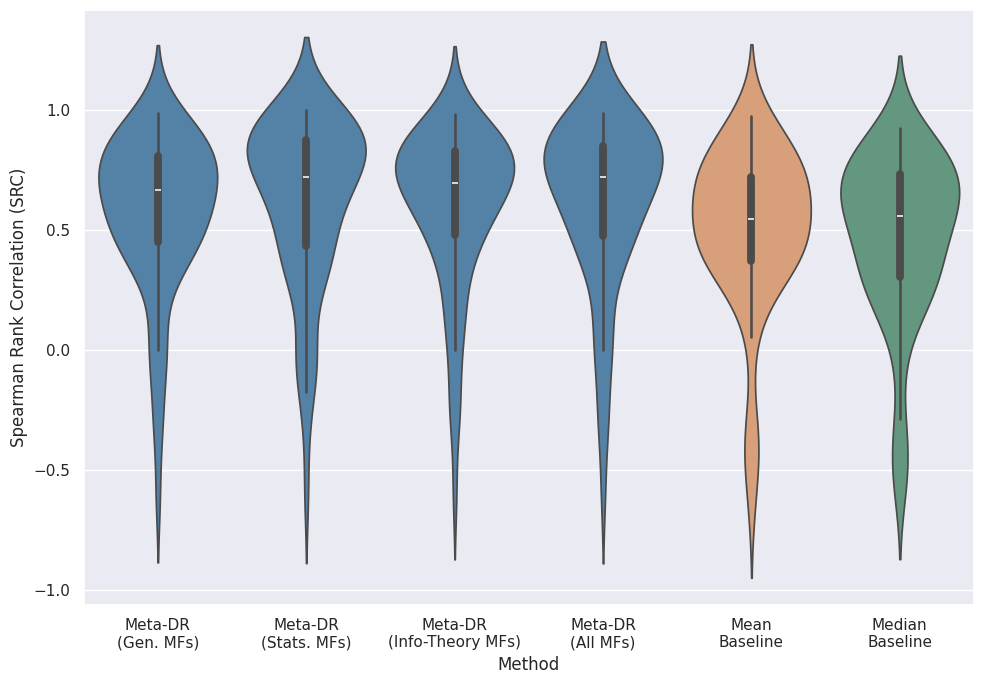

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Build DataFrames for each Meta-DR variant
df_general = pd.concat(
    [
        pd.DataFrame(spearman_values_general, columns=["General Proposal"]),
        pd.DataFrame(baseline_results_general)
    ],
    axis=1
)

df_statistical = pd.concat(
    [
        pd.DataFrame(spearman_values_statistical, columns=["Statistical Proposal"]),
        pd.DataFrame(baseline_results_statistical)
    ],
    axis=1
)

df_info_theory = pd.concat(
    [
        pd.DataFrame(spearman_values_info_theory, columns=["Info-Theory Proposal"]),
        pd.DataFrame(baseline_results_info_theory)
    ],
    axis=1
)

df_all_metafeatures = pd.concat(
    [
        pd.DataFrame(spearman_values_all_metafeatures, columns=["Unified Proposal"]),
        pd.DataFrame(baseline_results_all_metafeatures)
    ],
    axis=1
)

# Rename baseline columns for consistency
df_general = df_general.rename(columns={
    "spearman_mean": "Mean Baseline",
    "spearman_median": "Median Baseline"
})

df_statistical = df_statistical.rename(columns={
    "spearman_mean": "Mean Baseline",
    "spearman_median": "Median Baseline"
})

df_info_theory = df_info_theory.rename(columns={
    "spearman_mean": "Mean Baseline",
    "spearman_median": "Median Baseline"
})

df_all_metafeatures = df_all_metafeatures.rename(columns={
    "spearman_mean": "Mean Baseline",
    "spearman_median": "Median Baseline"
})

# Combine all methods into a single DataFrame
df_combined = pd.DataFrame({
    "Meta-DR (Gen. MFs)": df_general["General Proposal"],
    "Meta-DR (Stats. MFs)": df_statistical["Statistical Proposal"],
    "Meta-DR (Info-Theory MFs)": df_info_theory["Info-Theory Proposal"],
    "Meta-DR (All MFs)": df_all_metafeatures["Unified Proposal"],
    "Mean Baseline": df_general["Mean Baseline"],
    "Median Baseline": df_general["Median Baseline"]
})

# Convert to long format for seaborn
df_melted = df_combined.melt(var_name="Method", value_name="Spearman")

new_labels = [
    "Meta-DR\n(Gen. MFs)",
    "Meta-DR\n(Stats. MFs)",
    "Meta-DR\n(Info-Theory MFs)",
    "Meta-DR\n(All MFs)",
    "Mean\nBaseline",
    "Median\nBaseline"
]

# Violin plot
sns.set(style="darkgrid")
plt.figure(figsize=(10, 7))

sns.violinplot(
    data=df_melted,
    x="Method",
    y="Spearman",
    palette=["steelblue", "steelblue", "steelblue", "steelblue", "#E79B6C", "#5C9F7F"]
)

plt.ylabel("Spearman Rank Correlation (SRC)", fontsize=12)
plt.xlabel("Method", fontsize=12)
plt.xticks(ticks=range(len(new_labels)), labels=new_labels, rotation=0, fontsize=11)

plt.tight_layout()
plt.show()

# Performance Comparison of Meta-DR Proposals, Baselines, and Dimensionality Reduction Techniques

In [ ]:
import pandas as pd

# Load predicted rankings from each meta-model
df_predicted_general = pd.read_csv(
    'data/predictions/predictions_ranking_MetaGeneral.csv'
)
df_predicted_general.columns = df_DR_technique_result.columns

df_predicted_statistical = pd.read_csv(
    'data/predictions/predictions_ranking_metaStatistical.csv'
)
df_predicted_statistical.columns = df_DR_technique_result.columns

df_predicted_info_theory = pd.read_csv(
    'data/predictions/predictions_ranking_metaInfoTheory.csv'
)
df_predicted_info_theory.columns = df_DR_technique_result.columns

df_predicted_all_metafeatures = pd.read_csv(
    'data/predictions/predictions_rank_AllMetaFeatures.csv'
)
df_predicted_all_metafeatures.columns = df_DR_technique_result.columns


def calculate_proposal_performance(df_real_performance, df_predicted_ranking):
    """
    Compute the real performance of the algorithm recommended by the meta-model.

    Parameters
    ----------
    df_real_performance : pd.DataFrame
        DataFrame containing the true performance scores of all algorithms.
    df_predicted_ranking : pd.DataFrame
        DataFrame containing the predicted rankings for all algorithms.

    Returns
    -------
    list
        Real performance values of the recommended algorithm for each dataset.
    """
    recommended_performance = []

    for i in range(len(df_real_performance)):
        predicted_ranks = df_predicted_ranking.iloc[i]

        # Select the algorithm with the best predicted rank
        recommended_algorithm = predicted_ranks.idxmin()

        # Retrieve its true performance
        true_performance = df_real_performance.loc[i, recommended_algorithm]
        recommended_performance.append(true_performance)

    return recommended_performance


# Build final comparison table
final_results_table = df_DR_technique_result.copy()

# Add baseline methods
final_results_table['Mean Baseline'] = df_DR_technique_result.mean(axis=1)
final_results_table['Median Baseline'] = df_DR_technique_result.median(axis=1)

# Add proposal performances
final_results_table['General Proposal'] = calculate_proposal_performance(
    df_DR_technique_result, df_predicted_general
)

final_results_table['Statistical Proposal'] = calculate_proposal_performance(
    df_DR_technique_result, df_predicted_statistical
)

final_results_table['Info-Theory Proposal'] = calculate_proposal_performance(
    df_DR_technique_result, df_predicted_info_theory
)

final_results_table['Unified Proposal'] = calculate_proposal_performance(
    df_DR_technique_result, df_predicted_all_metafeatures
)

# Reorder columns
final_column_order = [
    'General Proposal',
    'Statistical Proposal',
    'Info-Theory Proposal',
    'Unified Proposal',
    'Mean Baseline',
    'Median Baseline',
    'PCA',
    'IncrementalPCA',
    'RandomTreesEmbedding',
    'SelectKBest',
    'SpectralEmbedding',
    'TruncatedSVD',
    'LDA',
    'LLE',
    'KPCA',
    't-SNE'
]

final_results_table = final_results_table[final_column_order]

# Display first rows
display(final_results_table.head())

,General Proposal,Statistical Proposal,Info-Theory Proposal,Unified Proposal,Mean Baseline,Median Baseline,PCA,IncrementalPCA,RandomTreesEmbedding,SelectKBest,SpectralEmbedding,TruncatedSVD,LDA,LLE,KPCA,t-SNE
0,0.964667,0.964500,0.964500,0.964500,0.964517,0.964500,0.964500,0.964500,0.964500,0.964500,0.964500,0.964500,0.964500,0.964667,0.964500,0.964500
1,0.777273,0.777273,0.777273,0.777273,0.720455,0.756818,0.759091,0.759091,0.736364,0.777273,0.504545,0.754545,0.759091,0.636364,0.772727,0.745455
2,0.595238,0.652381,0.721905,0.652381,0.665905,0.659524,0.652381,0.652381,0.679048,0.721905,0.666667,0.623810,0.707619,0.595238,0.652381,0.707619
3,0.650000,0.650000,0.650000,0.650000,0.650000,0.650000,0.650000,0.650000,0.650000,0.650000,0.650000,0.650000,0.650000,0.650000,0.650000,0.650000
4,0.990361,0.990361,0.990361,0.990361,0.971719,0.990361,0.990361,0.990361,0.980664,0.990361,0.971055,0.987952,0.992771,0.832942,0.990361,0.990361


In [ ]:
import pandas as pd
import numpy as np

# Load predicted rankings from file
def load_predicted_rankings(filepath, column_names):
    """
    Load a predicted ranking file and assign the correct column names.

    Parameters
    ----------
    filepath : str
        Path to the CSV file with predicted rankings.
    column_names : list-like
        Column names corresponding to the dimensionality reduction algorithms.

    Returns
    -------
    pd.DataFrame
        DataFrame containing predicted rankings.
    """
    df_predicted = pd.read_csv(filepath)
    df_predicted.columns = column_names
    return df_predicted


# Compute the real performance of the recommended algorithm
def calculate_proposal_performance(df_real_performance, df_predicted_ranking):
    """
    Compute the true performance of the algorithm recommended by the meta-model.

    Parameters
    ----------
    df_real_performance : pd.DataFrame
        DataFrame with the true performance values of the algorithms.
    df_predicted_ranking : pd.DataFrame
        DataFrame with predicted rankings for the algorithms.

    Returns
    -------
    np.ndarray
        Array with the true performance of the recommended algorithm for each dataset.
    """
    # Select the algorithm with the best predicted rank in each row
    best_algorithms = df_predicted_ranking.idxmin(axis=1)

    row_indices = np.arange(len(df_real_performance))
    col_indices = df_real_performance.columns.get_indexer(best_algorithms)

    return df_real_performance.to_numpy()[row_indices, col_indices]


# Proposal files
proposal_files = {
    "General Proposal": "data/predictions/predictions_ranking_MetaGeneral.csv",
    "Statistical Proposal": "data/predictions/predictions_ranking_metaStatistical.csv",
    "Info-Theory Proposal": "data/predictions/predictions_ranking_metaInfoTheory.csv",
    "Unified Proposal": "data/predictions/predictions_rank_AllMetaFeatures.csv",
}


# Build final comparison table
final_results_table = df_DR_technique_result.copy()


# Add baseline methods
final_results_table["Mean Baseline"] = df_DR_technique_result.mean(axis=1)
final_results_table["Median Baseline"] = df_DR_technique_result.median(axis=1)

# Add proposal performances automatically
for proposal_name, filepath in proposal_files.items():
    df_predicted_rankings = load_predicted_rankings(
        filepath,
        df_DR_technique_result.columns
    )
    final_results_table[proposal_name] = calculate_proposal_performance(
        df_DR_technique_result,
        df_predicted_rankings
    )


# Reorder columns
final_column_order = [
    *proposal_files.keys(),
    "Mean Baseline",
    "Median Baseline",
    *df_DR_technique_result.columns
]

final_results_table = final_results_table[final_column_order]

display(final_results_table.head())

,General Proposal,Statistical Proposal,Info-Theory Proposal,Unified Proposal,Mean Baseline,Median Baseline,PCA,IncrementalPCA,RandomTreesEmbedding,SelectKBest,SpectralEmbedding,TruncatedSVD,LDA,LLE,KPCA,t-SNE
0,0.964667,0.964500,0.964500,0.964500,0.964517,0.964500,0.964500,0.964500,0.964500,0.964500,0.964500,0.964500,0.964500,0.964667,0.964500,0.964500
1,0.777273,0.777273,0.777273,0.777273,0.720455,0.756818,0.759091,0.759091,0.736364,0.777273,0.504545,0.754545,0.759091,0.636364,0.772727,0.745455
2,0.595238,0.652381,0.721905,0.652381,0.665905,0.659524,0.652381,0.652381,0.679048,0.721905,0.666667,0.623810,0.707619,0.595238,0.652381,0.707619
3,0.650000,0.650000,0.650000,0.650000,0.650000,0.650000,0.650000,0.650000,0.650000,0.650000,0.650000,0.650000,0.650000,0.650000,0.650000,0.650000
4,0.990361,0.990361,0.990361,0.990361,0.971719,0.990361,0.990361,0.990361,0.980664,0.990361,0.971055,0.987952,0.992771,0.832942,0.990361,0.990361


In [ ]:
print(final_results_table.mean())

General Proposal        0.827987
Statistical Proposal    0.828873
Info-Theory Proposal    0.830911
Unified Proposal        0.828149
Mean Baseline           0.786382
Median Baseline         0.807236
PCA                     0.811270
IncrementalPCA          0.813609
RandomTreesEmbedding    0.807796
SelectKBest             0.832682
SpectralEmbedding       0.660399
TruncatedSVD            0.785199
LDA                     0.810628
LLE                     0.717171
KPCA                    0.804867
t-SNE                   0.820194
dtype: float64


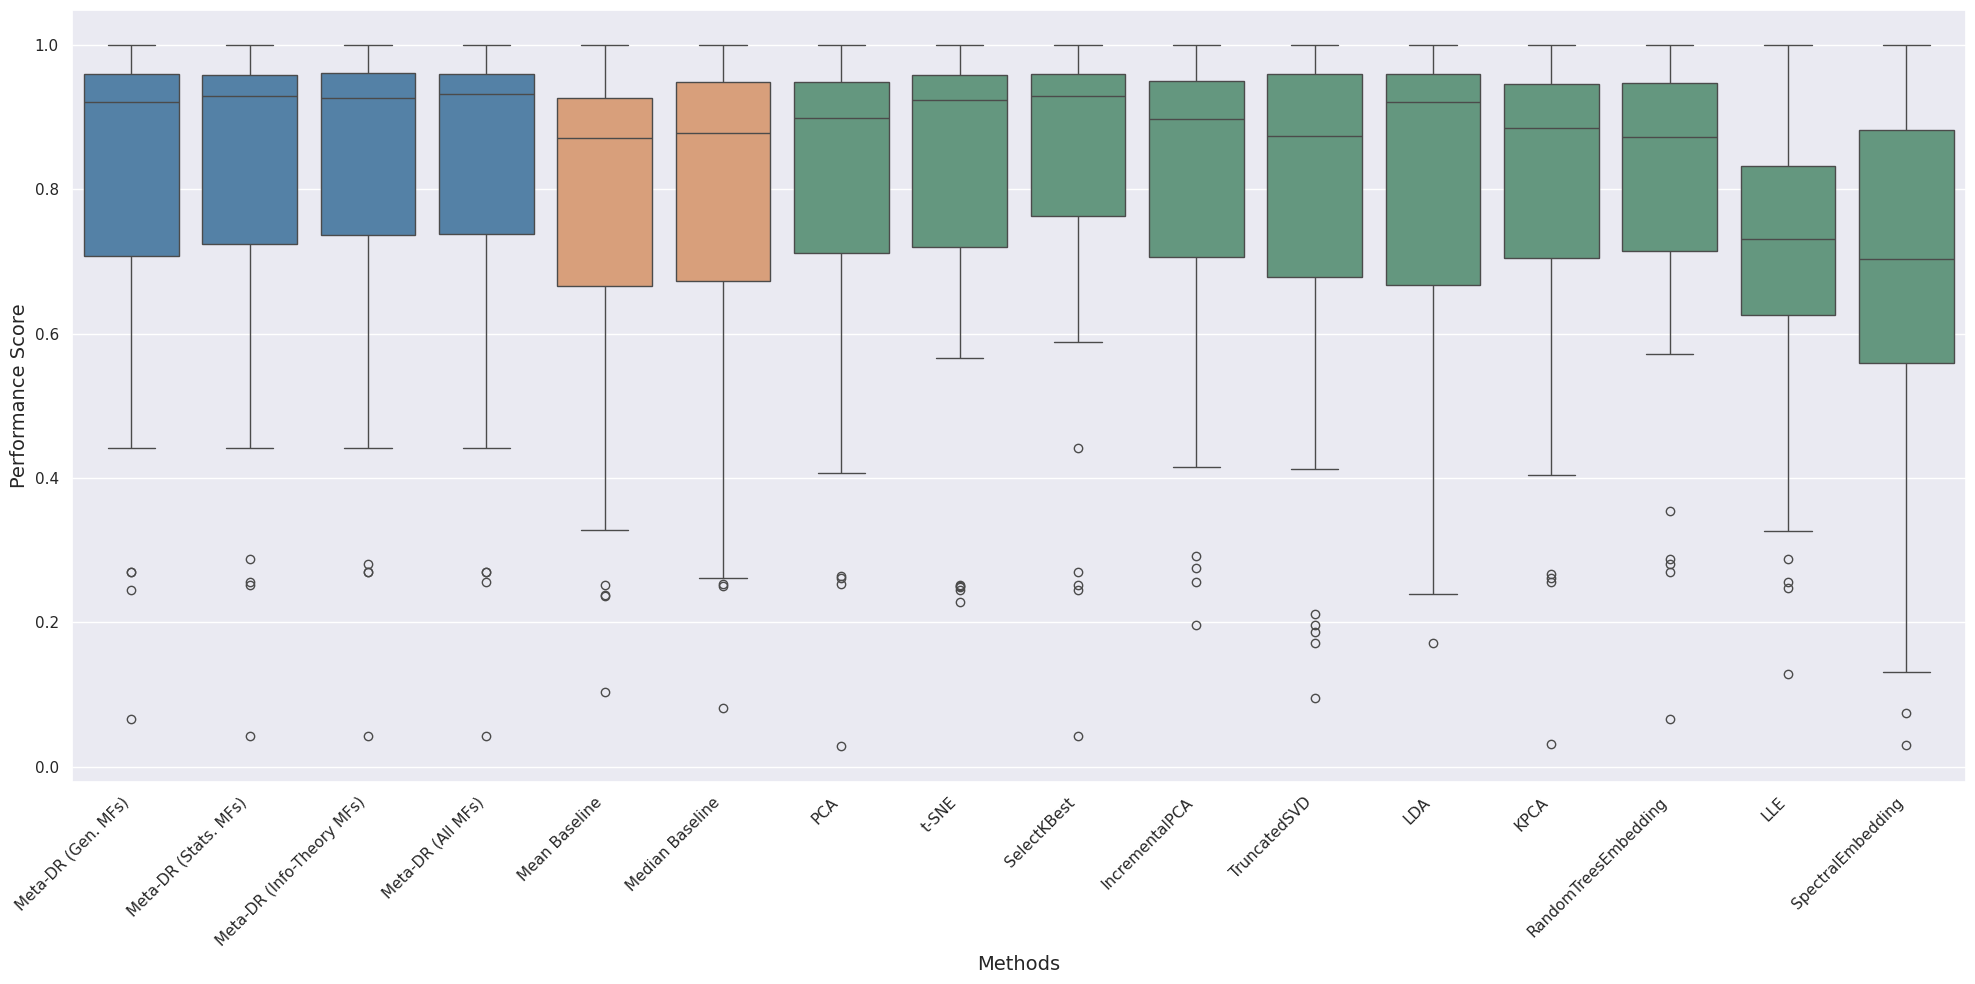

In [ ]:
# Prepare data for the boxplot
columns_to_plot = [
    'General Proposal', 'Statistical Proposal', 'Info-Theory Proposal', 'Unified Proposal',
    'Mean Baseline', 'Median Baseline',
    'PCA', 'IncrementalPCA', 'RandomTreesEmbedding', 'SelectKBest',
    'SpectralEmbedding', 'TruncatedSVD', 'LDA', 'LLE', 'KPCA', 't-SNE'
]

df_plot = final_results_table[columns_to_plot].copy()

# Rename proposal columns for display
renamed_columns = {
    'General Proposal': 'Meta-DR (Gen. MFs)',
    'Statistical Proposal': 'Meta-DR (Stats. MFs)',
    'Info-Theory Proposal': 'Meta-DR (Info-Theory MFs)',
    'Unified Proposal': 'Meta-DR (All MFs)',
    'Mean Baseline': 'Mean Baseline',
    'Median Baseline': 'Median Baseline',
}

df_plot.rename(columns=renamed_columns, inplace=True)

# Convert from wide to long format
df_long = df_plot.melt(var_name='Method', value_name='Performance')

# Define plotting order and colors
plot_order = [
    'Meta-DR (Gen. MFs)', 'Meta-DR (Stats. MFs)', 'Meta-DR (Info-Theory MFs)', 'Meta-DR (All MFs)',
    'Mean Baseline', 'Median Baseline',
    'PCA', 't-SNE', 'SelectKBest', 'IncrementalPCA', 'TruncatedSVD',
    'LDA', 'KPCA', 'RandomTreesEmbedding', 'LLE', 'SpectralEmbedding'
]

custom_colors = [
    'steelblue', 'steelblue', 'steelblue', 'steelblue',   # Meta-DR proposals
    '#E79B6C', '#E79B6C',                                 # Baselines
    '#5C9F7F', '#5C9F7F', '#5C9F7F', '#5C9F7F', '#5C9F7F',
    '#5C9F7F', '#5C9F7F', '#5C9F7F', '#5C9F7F', '#5C9F7F' # Individual DR methods
]

# Create boxplot
sns.set_style("darkgrid")
plt.figure(figsize=(20, 10))

sns.boxplot(
    data=df_long,
    x='Method',
    y='Performance',
    order=plot_order,
    palette=custom_colors
)

plt.ylabel('Performance Score', fontsize=14)
plt.xlabel('Methods', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

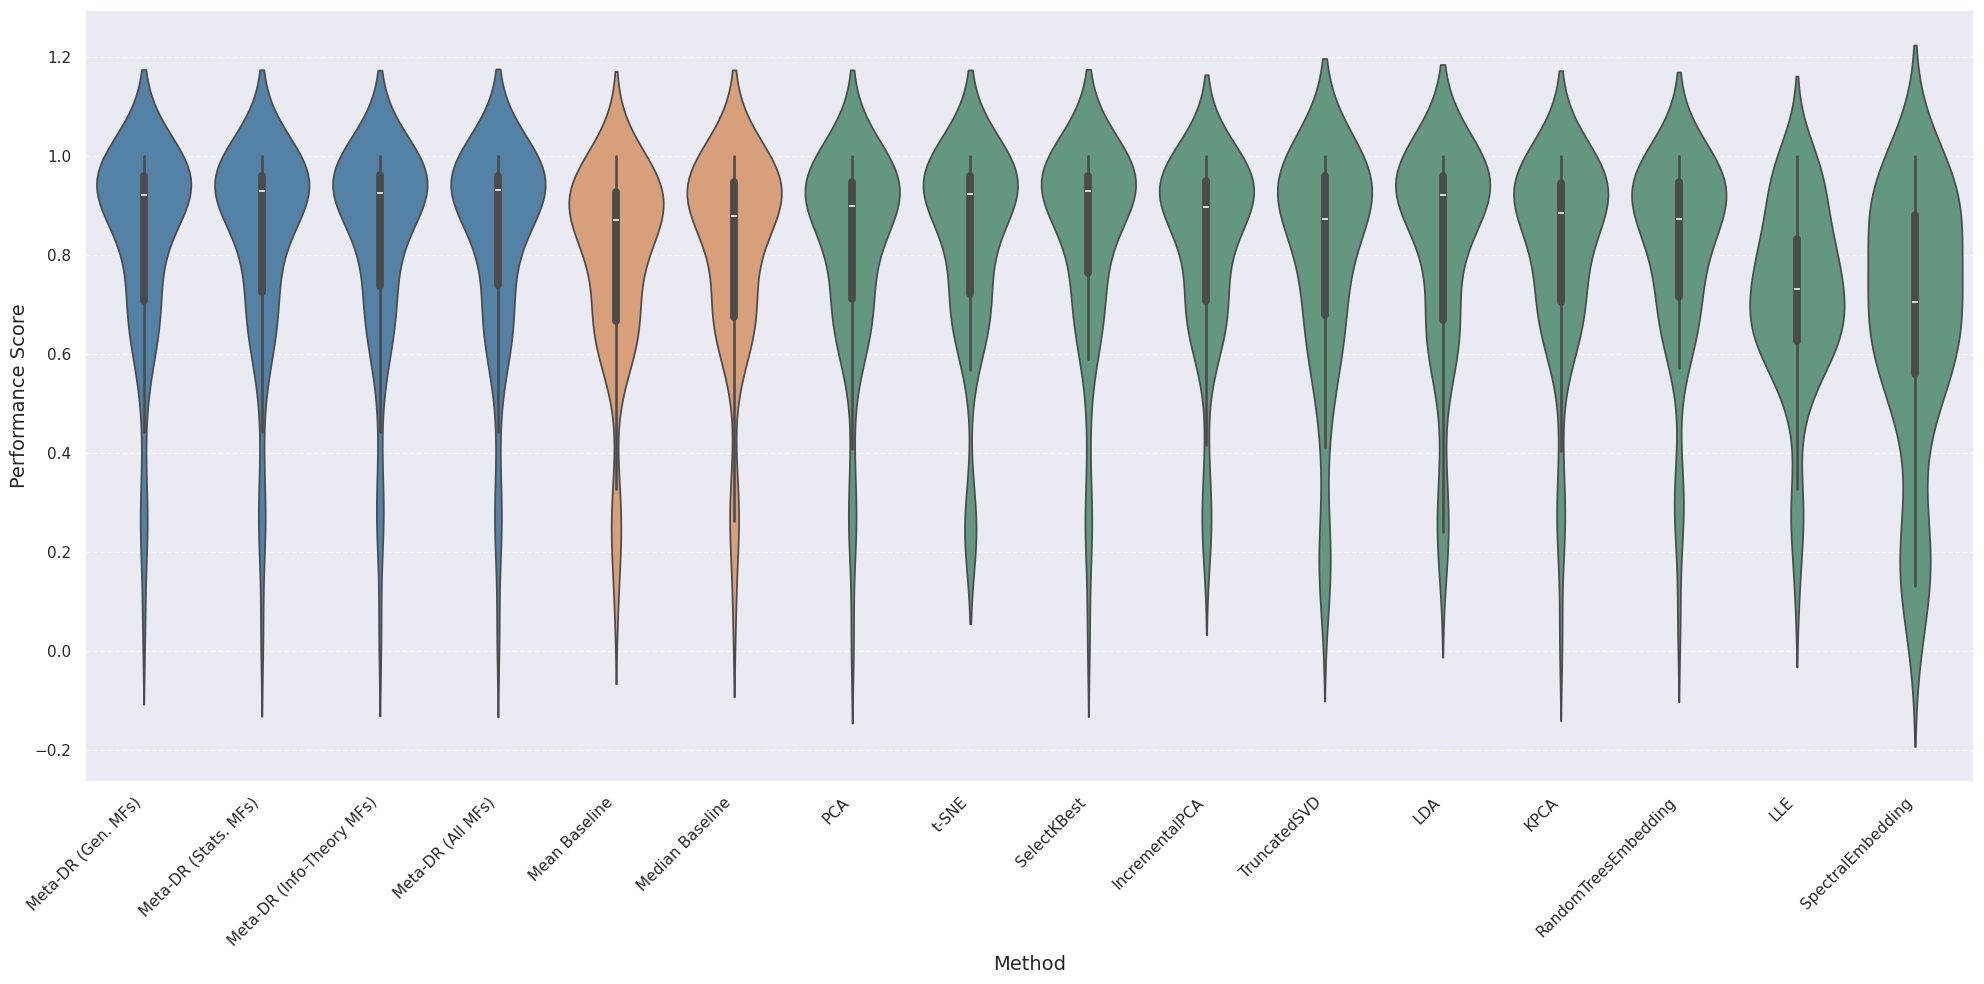

In [ ]:
# Prepare data for the violin plot
original_columns = [
    'General Proposal', 'Statistical Proposal', 'Info-Theory Proposal', 'Unified Proposal',
    'Mean Baseline', 'Median Baseline',
    'PCA', 'IncrementalPCA', 'RandomTreesEmbedding', 'SelectKBest',
    'SpectralEmbedding', 'TruncatedSVD', 'LDA', 'LLE', 'KPCA', 't-SNE'
]

df_plot = final_results_table[original_columns].copy()

renamed_columns = {
    'General Proposal': 'Meta-DR (Gen. MFs)',
    'Statistical Proposal': 'Meta-DR (Stats. MFs)',
    'Info-Theory Proposal': 'Meta-DR (Info-Theory MFs)',
    'Unified Proposal': 'Meta-DR (All MFs)',
    'Mean Baseline': 'Mean Baseline',
    'Median Baseline': 'Median Baseline',
}

df_plot.rename(columns=renamed_columns, inplace=True)

# Convert from wide to long format
df_long = df_plot.melt(var_name='Method', value_name='Performance')

# Define plot order and custom colors
plot_order = [
    'Meta-DR (Gen. MFs)', 'Meta-DR (Stats. MFs)', 'Meta-DR (Info-Theory MFs)', 'Meta-DR (All MFs)',
    'Mean Baseline', 'Median Baseline',
    'PCA', 't-SNE', 'SelectKBest', 'IncrementalPCA', 'TruncatedSVD',
    'LDA', 'KPCA', 'RandomTreesEmbedding', 'LLE', 'SpectralEmbedding'
]

custom_colors = [
    'steelblue', 'steelblue', 'steelblue', 'steelblue',   # Meta-DR proposals
    '#E79B6C', '#E79B6C',                                 # Baselines
    '#5C9F7F', '#5C9F7F', '#5C9F7F', '#5C9F7F', '#5C9F7F',
    '#5C9F7F', '#5C9F7F', '#5C9F7F', '#5C9F7F', '#5C9F7F' # Individual DR methods
]

# Create violin plot
sns.set_style("darkgrid")
plt.figure(figsize=(20, 10))

sns.violinplot(
    data=df_long,
    x='Method',
    y='Performance',
    order=plot_order,
    palette=custom_colors,
    inner='box'
)

plt.ylabel('Performance Score', fontsize=14)
plt.xlabel('Method', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


--- 95% Confidence Intervals, Means, and Margin of Error ---
                       Mean  CI Lower (95%)  CI Upper (95%)  Margin of Error
General Proposal     0.8280          0.7788          0.8772           0.0492
Statistical Proposal 0.8289          0.7798          0.8780           0.0491
Info-Theory Proposal 0.8309          0.7821          0.8798           0.0489
Unified Proposal     0.8281          0.7786          0.8777           0.0495
Mean Baseline        0.7864          0.7382          0.8345           0.0482
Median Baseline      0.8072          0.7582          0.8563           0.0490
PCA                  0.8113          0.7622          0.8603           0.0490
IncrementalPCA       0.8136          0.7674          0.8599           0.0463
RandomTreesEmbedding 0.8078          0.7600          0.8556           0.0478
SelectKBest          0.8327          0.7833          0.8820           0.0493
SpectralEmbedding    0.6604          0.5972          0.7236           0.0632
TruncatedSVD  

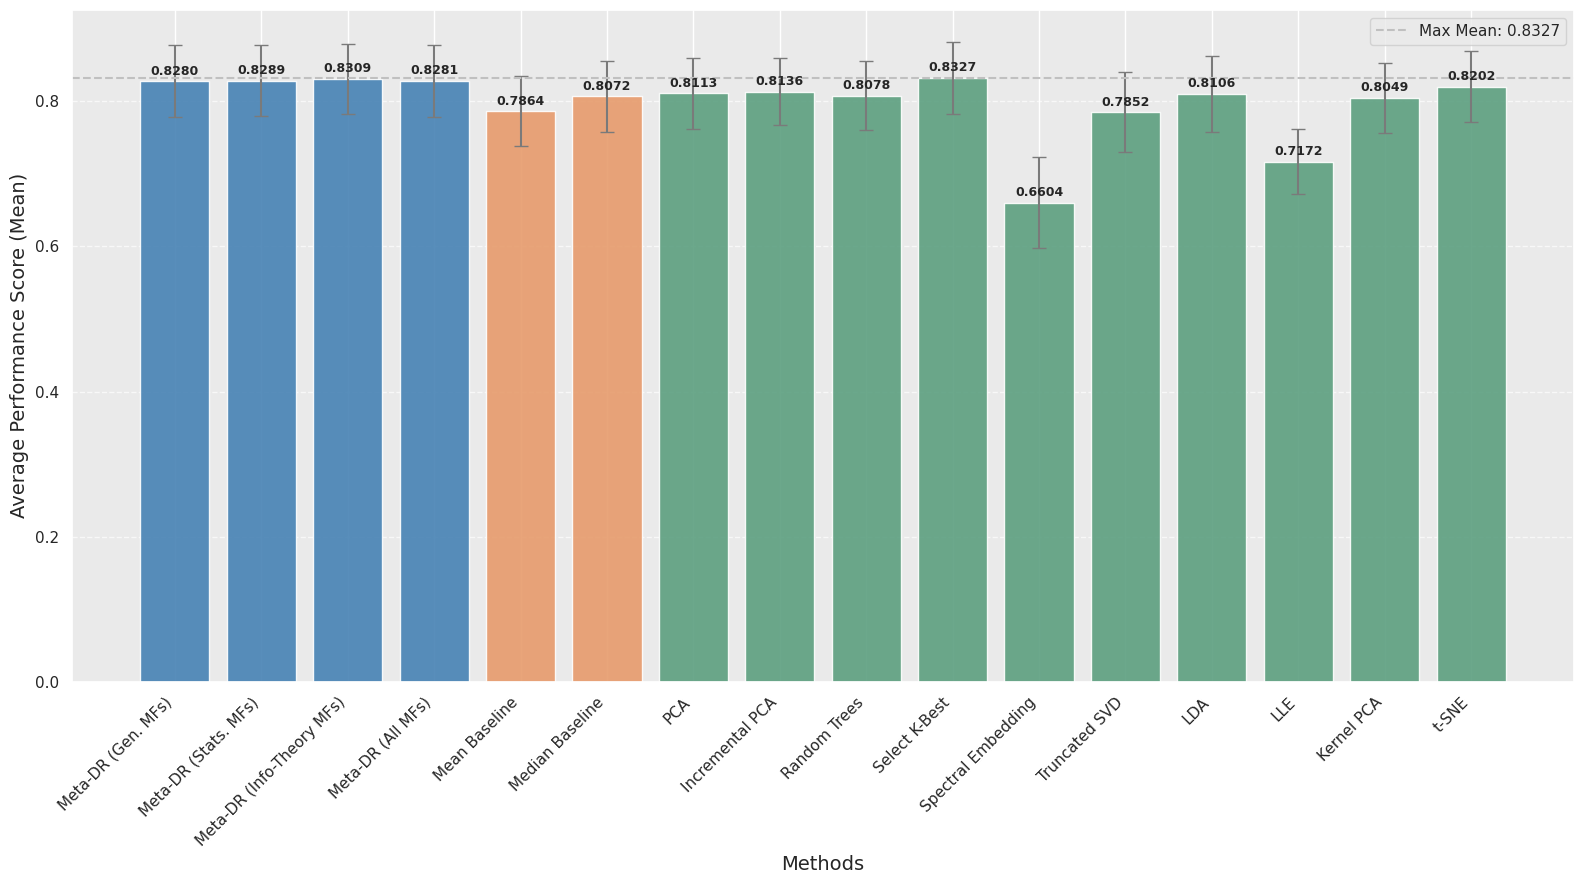

In [ ]:
# Select methods to compare
columns_to_plot = [
    'General Proposal', 'Statistical Proposal', 'Info-Theory Proposal', 'Unified Proposal',
    'Mean Baseline', 'Median Baseline',
    'PCA', 'IncrementalPCA', 'RandomTreesEmbedding', 'SelectKBest',
    'SpectralEmbedding', 'TruncatedSVD', 'LDA', 'LLE', 'KPCA', 't-SNE'
]

df_to_plot = final_results_table[columns_to_plot].copy()

# Compute 95% confidence intervals
confidence_level = 0.95
alpha = 1 - confidence_level
n = df_to_plot.shape[0]

means = df_to_plot.mean()
std_devs = df_to_plot.std(ddof=1)

try:
    t_critical = stats.t.ppf(1 - alpha / 2, df=n - 1)
except ValueError:
    print(
        f"Warning: could not compute the t-critical value because the sample size is too small (n={n})."
    )
    t_critical = 1.96

# Standard error of the mean
standard_error = std_devs / np.sqrt(n)

# Margin of error for the confidence interval
margin_of_error = t_critical * standard_error

ci_lower = means - margin_of_error
ci_upper = means + margin_of_error

ci_df = pd.DataFrame({
    'Mean': means,
    'CI Lower (95%)': ci_lower,
    'CI Upper (95%)': ci_upper,
    'Margin of Error': margin_of_error
}).reindex(columns_to_plot)

print("\n--- 95% Confidence Intervals, Means, and Margin of Error ---")
print(ci_df.to_string(float_format="{:.4f}".format))
print("------------------------------------------\n")

# Custom colors
custom_colors = [
    'steelblue', 'steelblue', 'steelblue', 'steelblue',   # Meta-DR proposals
    '#E79B6C', '#E79B6C',                                 # Baselines
    '#5C9F7F', '#5C9F7F', '#5C9F7F', '#5C9F7F',
    '#5C9F7F', '#5C9F7F', '#5C9F7F', '#5C9F7F',
    '#5C9F7F', '#5C9F7F'                                  # Individual DR methods
]

# Rename labels for plotting
rename_labels = {
    'General Proposal': 'Meta-DR (Gen. MFs)',
    'Statistical Proposal': 'Meta-DR (Stats. MFs)',
    'Info-Theory Proposal': 'Meta-DR (Info-Theory MFs)',
    'Unified Proposal': 'Meta-DR (All MFs)',
    'Mean Baseline': 'Mean Baseline',
    'Median Baseline': 'Median Baseline',
    'PCA': 'PCA',
    'IncrementalPCA': 'Incremental PCA',
    'RandomTreesEmbedding': 'Random Trees',
    'SelectKBest': 'Select K-Best',
    'SpectralEmbedding': 'Spectral Embedding',
    'TruncatedSVD': 'Truncated SVD',
    'LDA': 'LDA',
    'LLE': 'LLE',
    'KPCA': 'Kernel PCA',
    't-SNE': 't-SNE'
}

# Create bar plot with confidence intervals
sns.set_style("darkgrid")
sns.set(rc={'axes.facecolor': '#EAEAEA'})
plt.figure(figsize=(16, 9))

bars = plt.bar(
    means.index,
    means.values,
    yerr=margin_of_error.values,
    capsize=5,
    color=custom_colors,
    ecolor='#7A7A7A',
    alpha=0.9
)

# Reference line for the highest mean
max_value = means.values.max()
plt.axhline(
    y=max_value,
    color='silver',
    linestyle='--',
    linewidth=1.5,
    label=f"Max Mean: {max_value:.4f}"
)

# Add values above bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.005,
        f"{height:.4f}",
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

plt.xticks(
    ticks=np.arange(len(means.index)),
    labels=[rename_labels.get(label, label) for label in means.index],
    rotation=45,
    ha="right"
)

plt.ylabel('Average Performance Score (Mean)', fontsize=14)
plt.xlabel('Methods', fontsize=14)
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Few-Shot Performance Analysis of Meta-DR Proposals


TABLE: Average Performance by N-Shot and Proposal
        General  Statistical  Info-Theory  Unified
N-shot                                            
1        0.8280       0.8289       0.8309   0.8281
2        0.8364       0.8356       0.8370   0.8362
3        0.8401       0.8401       0.8388   0.8380
4        0.8424       0.8433       0.8418   0.8412
5        0.8436       0.8435       0.8432   0.8433
6        0.8444       0.8442       0.8453   0.8449
7        0.8446       0.8454       0.8454   0.8454
8        0.8454       0.8454       0.8454   0.8454
9        0.8454       0.8454       0.8454   0.8454
10       0.8454       0.8454       0.8454   0.8454



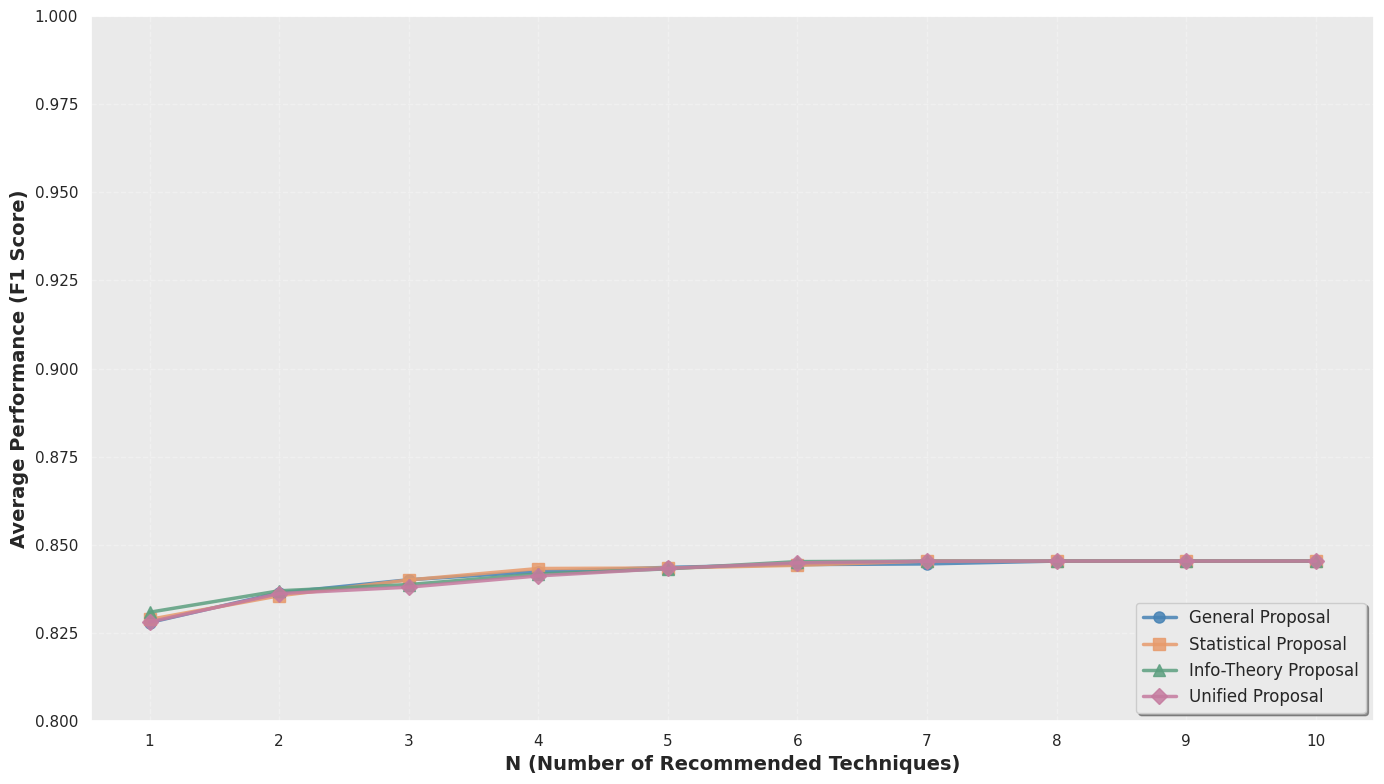

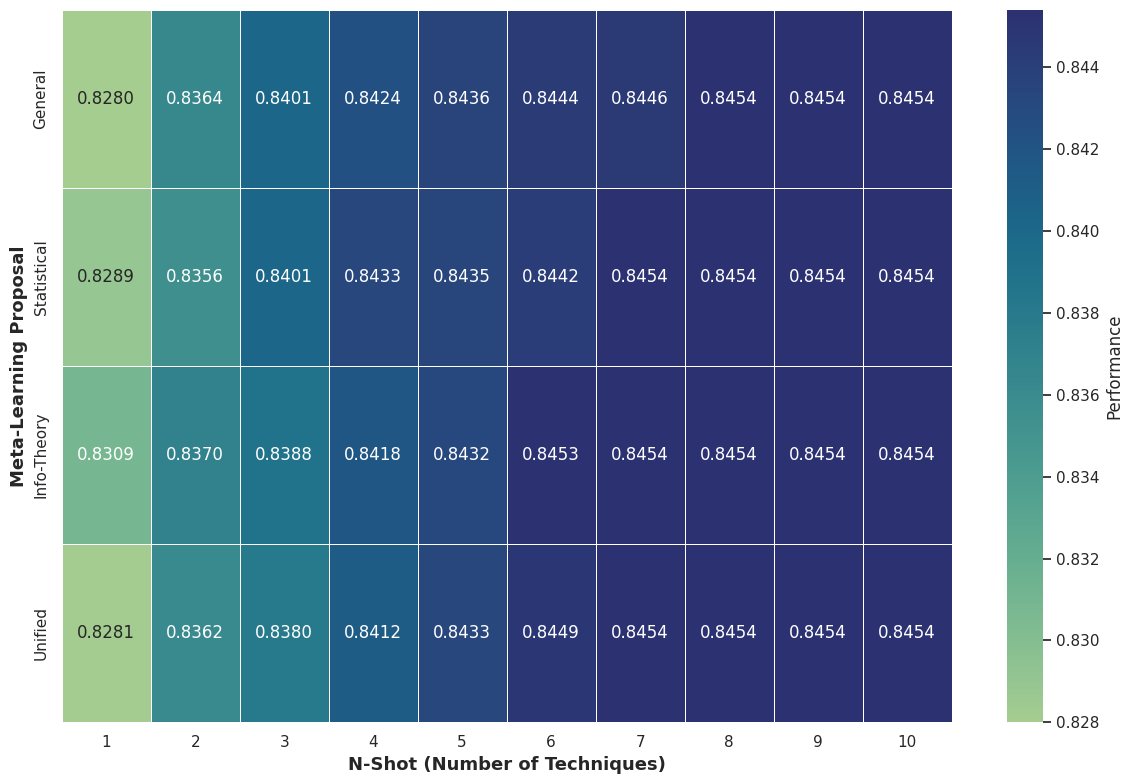

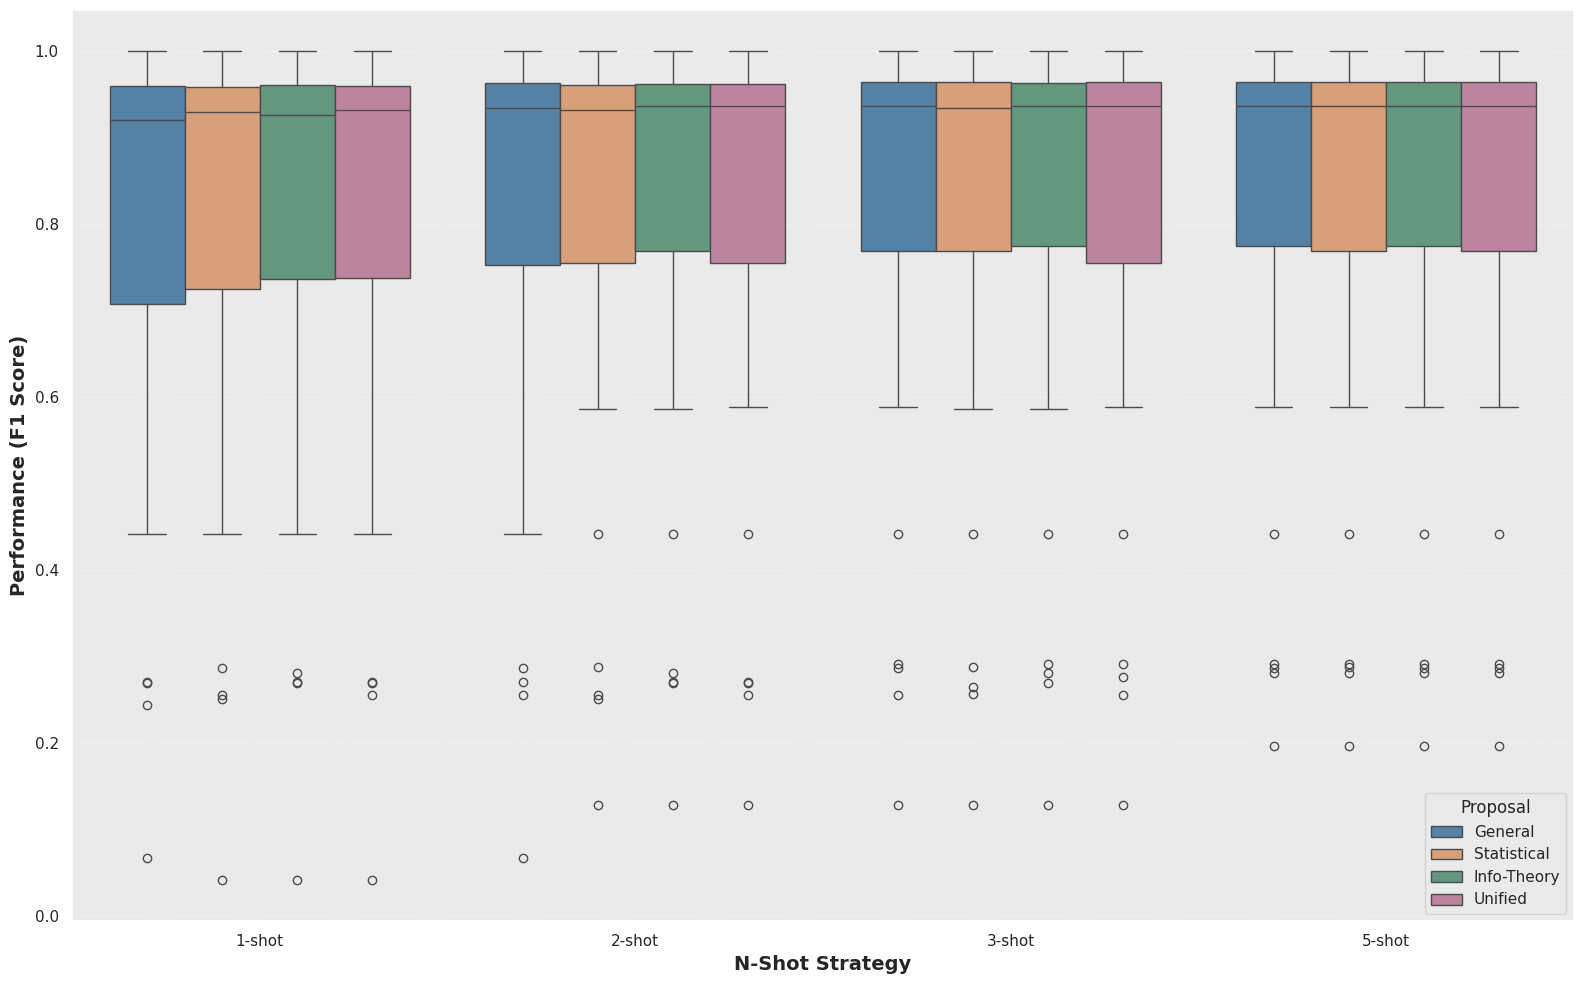


ANALYSIS: Few-Shot Performance Gain over 1-Shot

General Proposal:
  1-shot: 0.8280
  2-shot: 0.8364 (gain: +1.02%)
  3-shot: 0.8401 (gain: +1.47%)
  5-shot: 0.8436 (gain: +1.89%)

Statistical Proposal:
  1-shot: 0.8289
  2-shot: 0.8356 (gain: +0.81%)
  3-shot: 0.8401 (gain: +1.35%)
  5-shot: 0.8435 (gain: +1.76%)

Info-Theory Proposal:
  1-shot: 0.8309
  2-shot: 0.8370 (gain: +0.73%)
  3-shot: 0.8388 (gain: +0.95%)
  5-shot: 0.8432 (gain: +1.48%)

Unified Proposal:
  1-shot: 0.8281
  2-shot: 0.8362 (gain: +0.97%)
  3-shot: 0.8380 (gain: +1.19%)
  5-shot: 0.8433 (gain: +1.83%)



EXPANDED TABLE: Performance with N-Shot Analysis
   General Proposal  Statistical Proposal  Info-Theory Proposal  \
0          0.964667              0.964500              0.964500   
1          0.777273              0.777273              0.777273   
2          0.595238              0.652381              0.721905   
3          0.650000              0.650000              0.650000   
4          0.990361         

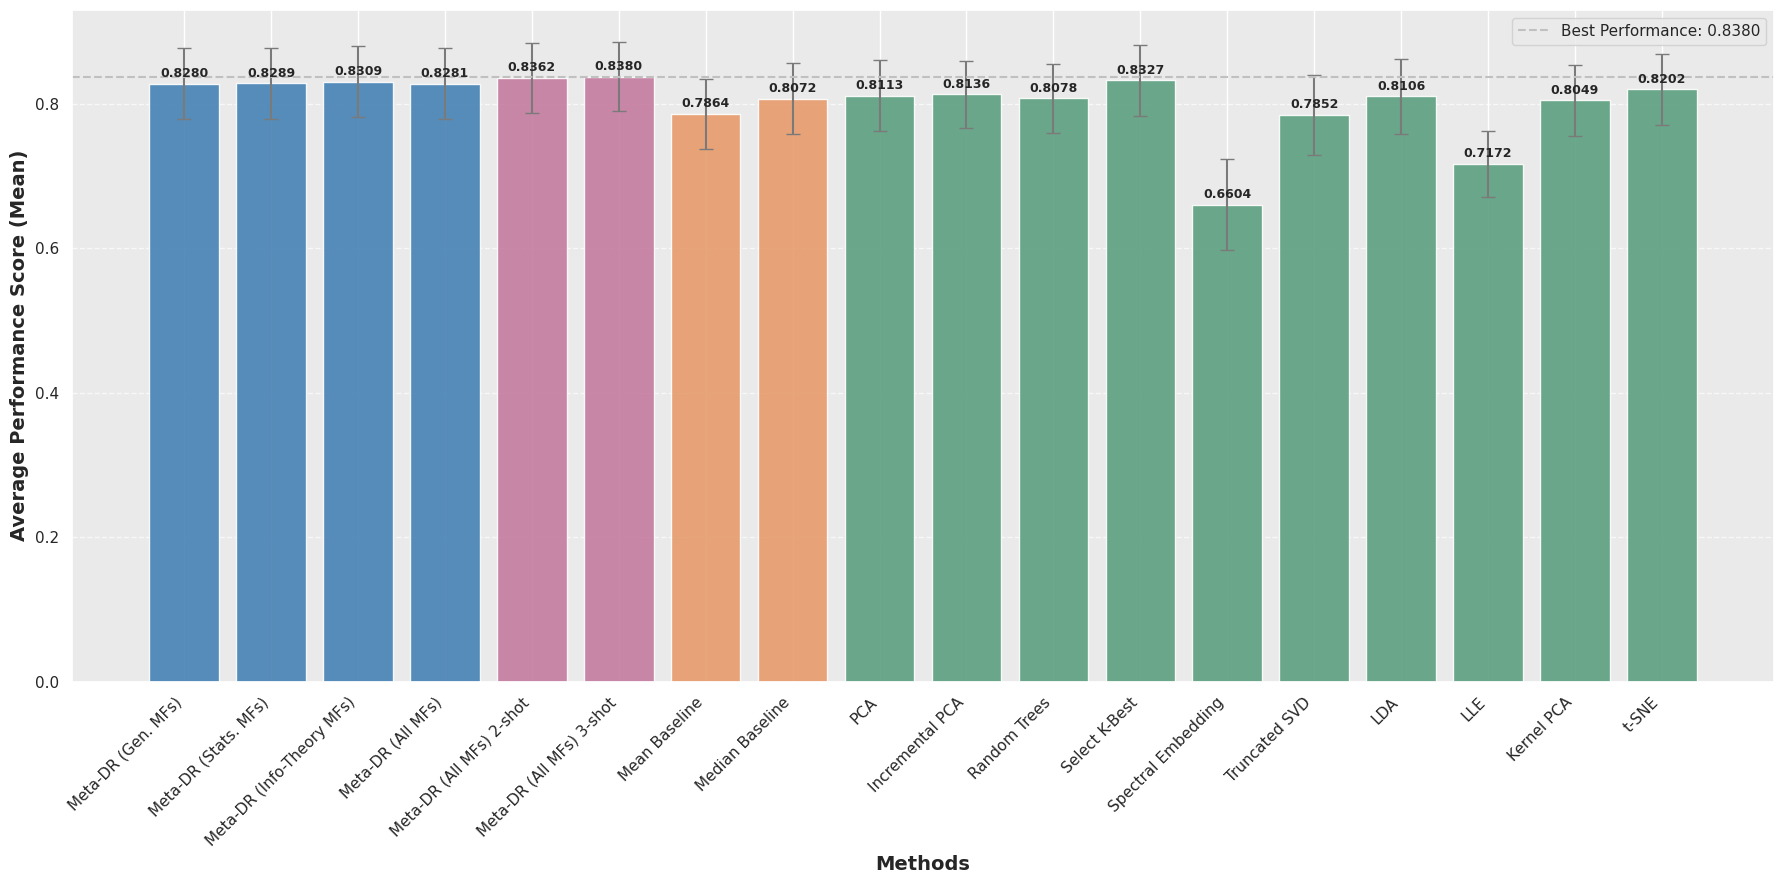

In [ ]:
# Helper functions
def calculate_nshot_performance(df_real_performance, df_predicted_ranking, n_shot):
    """
    Compute the best real performance among the top-N recommended techniques.

    Parameters
    ----------
    df_real_performance : pd.DataFrame
        True performance scores of all DR techniques.
    df_predicted_ranking : pd.DataFrame
        Predicted rankings for all DR techniques.
    n_shot : int
        Number of top-ranked techniques to consider.

    Returns
    -------
    np.ndarray
        Best true performance among the top-N recommended techniques for each dataset.
    """
    nshot_performance = []

    for row_idx in range(len(df_real_performance)):
        predicted_ranks = df_predicted_ranking.iloc[row_idx]

        # Select the top-N techniques with the best predicted ranks
        top_n_techniques = predicted_ranks.nsmallest(n_shot).index.tolist()

        # Get the true performances of the selected techniques
        selected_performances = df_real_performance.iloc[row_idx][top_n_techniques]

        # Keep the best true performance among the selected techniques
        best_performance = selected_performances.max()
        nshot_performance.append(best_performance)

    return np.array(nshot_performance)


def load_predicted_rankings(filepath, columns):
    """
    Load predicted rankings from CSV.
    The file already contains ranking values, so no extra ranking step is required.
    """
    df_predicted = pd.read_csv(filepath)
    df_predicted.columns = columns
    return df_predicted


# Load predicted rankings for each proposal
proposal_files = {
    "General": "data/predictions/predictions_ranking_MetaGeneral.csv",
    "Statistical": "data/predictions/predictions_ranking_metaStatistical.csv",
    "Info-Theory": "data/predictions/predictions_ranking_metaInfoTheory.csv",
    "Unified": "data/predictions/predictions_rank_AllMetaFeatures.csv",
}

predicted_rankings = {}
for proposal_name, filepath in proposal_files.items():
    predicted_rankings[proposal_name] = load_predicted_rankings(
        filepath,
        df_DR_technique_result.columns
    )

# Compute N-shot performance from 1-shot to 10-shot
n_values = range(1, 11)

nshot_results = {}
for proposal_name, df_rank in predicted_rankings.items():
    nshot_results[proposal_name] = {}
    for n in n_values:
        nshot_results[proposal_name][n] = calculate_nshot_performance(
            df_DR_technique_result,
            df_rank,
            n
        )

# Mean performance for each proposal and N-shot setting
nshot_means = {}
for proposal_name in predicted_rankings.keys():
    nshot_means[proposal_name] = {
        n: nshot_results[proposal_name][n].mean()
        for n in n_values
    }

# Convert to DataFrame
df_nshot_comparison = pd.DataFrame(nshot_means)
df_nshot_comparison.index.name = "N-shot"
df_nshot_comparison = df_nshot_comparison.round(4)

print("\n" + "=" * 80)
print("TABLE: Average Performance by N-Shot and Proposal")
print("=" * 80)
print(df_nshot_comparison)
print("=" * 80 + "\n")

# Line plot: average performance by N-shot
plt.figure(figsize=(14, 8))

proposal_colors = {
    "General": "steelblue",
    "Statistical": "#E79B6C",
    "Info-Theory": "#5C9F7F",
    "Unified": "#C57B9F"
}
proposal_markers = ["o", "s", "^", "D"]

for proposal_name, marker in zip(predicted_rankings.keys(), proposal_markers):
    mean_values = [nshot_means[proposal_name][n] for n in n_values]
    plt.plot(
        n_values,
        mean_values,
        marker=marker,
        color=proposal_colors[proposal_name],
        linewidth=2.5,
        markersize=8,
        label=f"{proposal_name} Proposal",
        alpha=0.85
    )

plt.xlabel("N (Number of Recommended Techniques)", fontsize=14, fontweight="bold")
plt.ylabel("Average Performance (F1 Score)", fontsize=14, fontweight="bold")
plt.xticks(list(n_values))
plt.ylim(0.80, 1.0)
plt.grid(True, alpha=0.3, linestyle="--")
plt.legend(fontsize=12, loc="lower right", frameon=True, shadow=True)
plt.tight_layout()
plt.show()

# Heatmap: N-shot performance comparison
plt.figure(figsize=(12, 8))
sns.heatmap(
    df_nshot_comparison.T,
    annot=True,
    fmt=".4f",
    cmap=sns.color_palette("crest", as_cmap=True),
    cbar_kws={"label": "Performance"},
    linewidths=0.5
)
plt.xlabel("N-Shot (Number of Techniques)", fontsize=13, fontweight="bold")
plt.ylabel("Meta-Learning Proposal", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Boxplot: selected N-shot strategies
selected_n_values = [1, 2, 3, 5]
comparison_rows = []

for proposal_name in predicted_rankings.keys():
    for n in selected_n_values:
        for performance in nshot_results[proposal_name][n]:
            comparison_rows.append({
                "Proposal": proposal_name,
                "N-Shot": f"{n}-shot",
                "Performance": performance
            })

df_nshot_distribution = pd.DataFrame(comparison_rows)

plt.figure(figsize=(16, 10))
palette = [proposal_colors[name] for name in predicted_rankings.keys()]

sns.boxplot(
    data=df_nshot_distribution,
    x="N-Shot",
    y="Performance",
    hue="Proposal",
    palette=palette
)

plt.ylabel("Performance (F1 Score)", fontsize=14, fontweight="bold")
plt.xlabel("N-Shot Strategy", fontsize=14, fontweight="bold")
plt.legend(title="Proposal", fontsize=11, title_fontsize=12)
plt.grid(axis="y", alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()

# Print few-shot gains relative to 1-shot
print("\n" + "=" * 80)
print("ANALYSIS: Few-Shot Performance Gain over 1-Shot")
print("=" * 80)

for proposal_name in predicted_rankings.keys():
    one_shot = nshot_results[proposal_name][1].mean()
    two_shot = nshot_results[proposal_name][2].mean()
    three_shot = nshot_results[proposal_name][3].mean()
    five_shot = nshot_results[proposal_name][5].mean()

    gain_2 = ((two_shot - one_shot) / one_shot) * 100
    gain_3 = ((three_shot - one_shot) / one_shot) * 100
    gain_5 = ((five_shot - one_shot) / one_shot) * 100

    print(f"\n{proposal_name} Proposal:")
    print(f"  1-shot: {one_shot:.4f}")
    print(f"  2-shot: {two_shot:.4f} (gain: +{gain_2:.2f}%)")
    print(f"  3-shot: {three_shot:.4f} (gain: +{gain_3:.2f}%)")
    print(f"  5-shot: {five_shot:.4f} (gain: +{gain_5:.2f}%)")

print("\n" + "=" * 80 + "\n")

# Expand final results table with 2-shot and 3-shot columns
final_results_table_nshot = final_results_table.copy()

for proposal_name, df_rank in predicted_rankings.items():
    final_results_table_nshot[f"{proposal_name} 2-shot"] = calculate_nshot_performance(
        df_DR_technique_result,
        df_rank,
        2
    )
    final_results_table_nshot[f"{proposal_name} 3-shot"] = calculate_nshot_performance(
        df_DR_technique_result,
        df_rank,
        3
    )

print("\n" + "=" * 80)
print("EXPANDED TABLE: Performance with N-Shot Analysis")
print("=" * 80)
print(final_results_table_nshot.head(10))
print("\nAverages:")
print(final_results_table_nshot.mean(numeric_only=True).round(4))
print("=" * 80 + "\n")

# Compare proposals against the best individual algorithm
selectkbest_mean = df_DR_technique_result["SelectKBest"].mean()

print("\n" + "=" * 80)
print("COMPARISON: N-Shot Proposals vs. Best Individual Algorithm (SelectKBest)")
print("=" * 80)
print(f"\nSelectKBest (always use): {selectkbest_mean:.4f}\n")

for proposal_name in predicted_rankings.keys():
    for n in [1, 2, 3]:
        mean_performance = nshot_results[proposal_name][n].mean()
        difference = mean_performance - selectkbest_mean
        symbol = "✓" if difference > 0 else "✗"
        print(f"{symbol} {proposal_name} {n}-shot: {mean_performance:.4f} (difference: {difference:+.4f})")

print("=" * 80 + "\n")

# Bar plot with confidence intervals including few-shot variants
columns_to_plot_nshot = [
    "General Proposal",
    "Statistical Proposal",
    "Info-Theory Proposal",
    "Unified Proposal",
    "Unified 2-shot",
    "Unified 3-shot",
    "Mean Baseline",
    "Median Baseline",
    "PCA",
    "IncrementalPCA",
    "RandomTreesEmbedding",
    "SelectKBest",
    "SpectralEmbedding",
    "TruncatedSVD",
    "LDA",
    "LLE",
    "KPCA",
    "t-SNE"
]

df_plot_nshot = final_results_table_nshot[columns_to_plot_nshot].copy()

confidence_level = 0.95
alpha = 1 - confidence_level
sample_size = df_plot_nshot.shape[0]

means_nshot = df_plot_nshot.mean()
std_devs_nshot = df_plot_nshot.std(ddof=1)

try:
    t_critical = stats.t.ppf(1 - alpha / 2, df=sample_size - 1)
except ValueError:
    t_critical = 1.96

standard_error_nshot = std_devs_nshot / np.sqrt(sample_size)
margin_of_error_nshot = t_critical * standard_error_nshot

ci_lower_nshot = means_nshot - margin_of_error_nshot
ci_upper_nshot = means_nshot + margin_of_error_nshot

ci_df_nshot = pd.DataFrame({
    "Mean": means_nshot,
    "CI Lower (95%)": ci_lower_nshot,
    "CI Upper (95%)": ci_upper_nshot,
    "Margin of Error": margin_of_error_nshot
}).reindex(columns_to_plot_nshot)

print("\n--- 95% Confidence Intervals, Means, and Margin of Error (N-Shot Included) ---")
print(ci_df_nshot.to_string(float_format="{:.4f}".format))
print("------------------------------------------\n")

custom_colors_nshot = [
    "steelblue", "steelblue", "steelblue", "steelblue",
    "#C57B9F", "#C57B9F",
    "#E79B6C", "#E79B6C",
    "#5C9F7F", "#5C9F7F", "#5C9F7F", "#5C9F7F",
    "#5C9F7F", "#5C9F7F", "#5C9F7F", "#5C9F7F",
    "#5C9F7F", "#5C9F7F"
]

rename_labels_nshot = {
    "General Proposal": "Meta-DR (Gen. MFs)",
    "Statistical Proposal": "Meta-DR (Stats. MFs)",
    "Info-Theory Proposal": "Meta-DR (Info-Theory MFs)",
    "Unified Proposal": "Meta-DR (All MFs)",
    "Unified 2-shot": "Meta-DR (All MFs) 2-shot",
    "Unified 3-shot": "Meta-DR (All MFs) 3-shot",
    "Mean Baseline": "Mean Baseline",
    "Median Baseline": "Median Baseline",
    "PCA": "PCA",
    "IncrementalPCA": "Incremental PCA",
    "RandomTreesEmbedding": "Random Trees",
    "SelectKBest": "Select K-Best",
    "SpectralEmbedding": "Spectral Embedding",
    "TruncatedSVD": "Truncated SVD",
    "LDA": "LDA",
    "LLE": "LLE",
    "KPCA": "Kernel PCA",
    "t-SNE": "t-SNE"
}

sns.set_style("darkgrid")
sns.set(rc={"axes.facecolor": "#EAEAEA"})
plt.figure(figsize=(18, 9))

bars = plt.bar(
    means_nshot.index,
    means_nshot.values,
    yerr=margin_of_error_nshot.values,
    capsize=5,
    color=custom_colors_nshot,
    ecolor="#7A7A7A",
    alpha=0.9
)

best_mean_value = means_nshot.values.max()
plt.axhline(
    y=best_mean_value,
    color="silver",
    linestyle="--",
    linewidth=1.5,
    label=f"Best Performance: {best_mean_value:.4f}"
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.005,
        f"{height:.4f}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

plt.xticks(
    ticks=np.arange(len(means_nshot.index)),
    labels=[rename_labels_nshot.get(label, label) for label in means_nshot.index],
    rotation=45,
    ha="right"
)

plt.ylabel("Average Performance Score (Mean)", fontsize=14, fontweight="bold")
plt.xlabel("Methods", fontsize=14, fontweight="bold")
plt.legend(loc="upper right")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

# Statistical Hypothesis Testing


--- 95% Confidence Intervals, Means, and Margin of Error ---
                       Mean  CI Lower (95%)  CI Upper (95%)  Margin of Error
General Proposal     0.8280          0.7788          0.8772           0.0492
Statistical Proposal 0.8289          0.7798          0.8780           0.0491
Info-Theory Proposal 0.8309          0.7821          0.8798           0.0489
Unified Proposal     0.8281          0.7786          0.8777           0.0495
Unified 2-shot       0.8362          0.7881          0.8843           0.0481
Unified 3-shot       0.8380          0.7902          0.8859           0.0478
Mean Baseline        0.7864          0.7382          0.8345           0.0482
Median Baseline      0.8072          0.7582          0.8563           0.0490
PCA                  0.8113          0.7622          0.8603           0.0490
IncrementalPCA       0.8136          0.7674          0.8599           0.0463
RandomTreesEmbedding 0.8078          0.7600          0.8556           0.0478
SelectKBest   

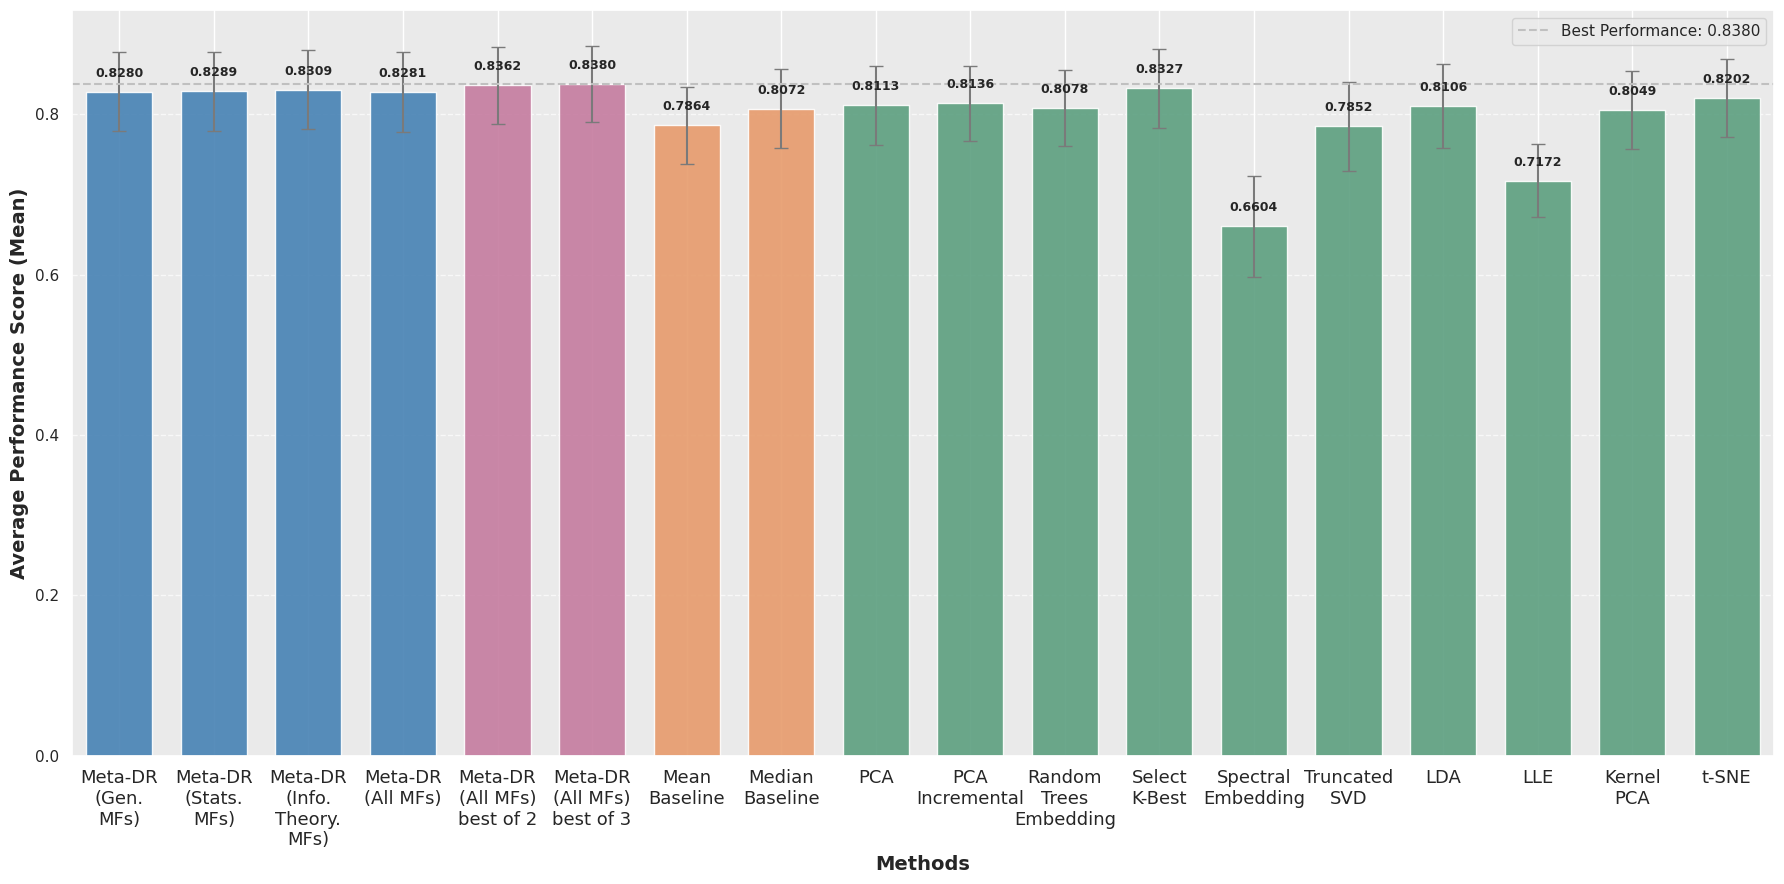

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats


columns_to_plot_nshot = [
    'General Proposal', 'Statistical Proposal', 'Info-Theory Proposal', 'Unified Proposal',
    'Unified 2-shot', 'Unified 3-shot',
    'Mean Baseline', 'Median Baseline',
    'PCA', 'IncrementalPCA', 'RandomTreesEmbedding', 'SelectKBest',
    'SpectralEmbedding', 'TruncatedSVD', 'LDA', 'LLE', 'KPCA', 't-SNE'
]

# Usar tabela_final_nshot que contém as colunas few-shot
df_to_plot = final_results_table_nshot[columns_to_plot_nshot]

confidence_level = 0.95
alpha = 1 - confidence_level
n = df_to_plot.shape[0]

means = df_to_plot.mean()
std_devs = df_to_plot.std(ddof=1)

# df = n - 1
try:
    t_critical = stats.t.ppf(1 - alpha / 2, df=n - 1)
except ValueError:
    print(f"Erro: Não é possível calcular o valor t-crítico. O número de amostras (n={n}) é muito baixo.")
    t_critical = 1.96

# Erro padrão da média (SEM)
sem = std_devs / np.sqrt(n)

# Margem de erro (para usar como erro no gráfico)
margin_of_error = t_critical * sem

ci_lower = means - margin_of_error
ci_upper = means + margin_of_error

ci_df = pd.DataFrame({
    'Mean': means,
    'CI Lower (95%)': ci_lower,
    'CI Upper (95%)': ci_upper,
    'Margin of Error': margin_of_error
}).reindex(columns_to_plot_nshot)

print("\n--- 95% Confidence Intervals, Means, and Margin of Error ---")
print(ci_df.to_string(float_format="{:.4f}".format))
print("------------------------------------------\n")

# TESTES DE HIPÓTESE


print("="*80)
print("TESTES DE HIPÓTESE: Comparação MDR (1-shot, 2-shot, 3-shot) vs Baselines e Melhor Método Individual")
print("="*80)
print("\nHipótese H0: Não há diferença significativa entre os métodos")
print("Hipótese H1: Há diferença significativa entre os métodos\n")

# Definir os métodos MDR para comparação
mdr_methods = {
    'General Proposal': 'MDR (Gen. MFs)',
    'Statistical Proposal': 'MDR (Stats. MFs)',
    'Info-Theory Proposal': 'MDR (Info. Theory. MFs)',
    'Unified Proposal': 'MDR (All MFs)',
    'Unified 2-shot': 'MDR (All MFs) best of 2',
    'Unified 3-shot': 'MDR (All MFs) best of 3'
}

baselines = {
    'Mean Baseline': 'Mean Baseline',
    'Median Baseline': 'Median Baseline'
}

# Melhor método individual
best_individual = 'SelectKBest'

comparisons = []

# 1. Comparar cada MDR (1-shot, 2-shot, 3-shot) com baselines
for mdr_col, mdr_name in mdr_methods.items():
    for baseline_col, baseline_name in baselines.items():
        comparisons.append((
            mdr_name,
            baseline_name,
            df_to_plot[mdr_col],
            df_to_plot[baseline_col]
        ))

# 2. Comparar cada MDR com SelectKBest (melhor método individual)
for mdr_col, mdr_name in mdr_methods.items():
    comparisons.append((
        mdr_name,
        'Select K-Best',
        df_to_plot[mdr_col],
        df_to_plot[best_individual]
    ))

# 3. Comparar Unified 2-shot e 3-shot com Unified 1-shot (para ver ganho do few-shot)
comparisons.append((
    'MDR (All MFs) best of 2',
    'MDR (All MFs)',
    df_to_plot['Unified 2-shot'],
    df_to_plot['Unified Proposal']
))

comparisons.append((
    'MDR (All MFs) best of 3',
    'MDR (All MFs)',
    df_to_plot['Unified 3-shot'],
    df_to_plot['Unified Proposal']
))

# 4. Comparar Unified 3-shot vs Unified 2-shot
comparisons.append((
    'MDR (All MFs) best of 3',
    'MDR (All MFs) best of 2',
    df_to_plot['Unified 3-shot'],
    df_to_plot['Unified 2-shot']
))

results_summary = []

for method1_name, method2_name, data1, data2 in comparisons:
    print(f"\n{'='*80}")
    print(f"Comparação: {method1_name} vs {method2_name}")
    print(f"{'='*80}")

    # Remover valores NaN se houver
    mask = ~(np.isnan(data1) | np.isnan(data2))
    data1_clean = data1[mask].values
    data2_clean = data2[mask].values

    # Calcular diferenças para teste pareado
    differences = data1_clean - data2_clean

    print(f"\nTamanho da amostra: {len(data1_clean)}")
    print(f"Média {method1_name}: {np.mean(data1_clean):.4f}")
    print(f"Média {method2_name}: {np.mean(data2_clean):.4f}")
    print(f"Diferença média: {np.mean(differences):.4f}")

    # --- TESTE DE NORMALIDADE ---
    print(f"\n--- Teste de Normalidade (D'Agostino-Pearson) ---")
    stat_norm, p_norm = stats.normaltest(differences)
    print(f"Estatística: {stat_norm:.4f}")
    print(f"p-valor: {p_norm:.4f}")

    is_normal = p_norm > 0.05
    if is_normal:
        print(f"✓ Distribuição normal (p > 0.05) → Usar t-test pareado")
    else:
        print(f"✗ Distribuição NÃO normal (p ≤ 0.05) → Usar Wilcoxon")

    # --- TESTE DE HIPÓTESE ---
    print(f"\n--- Teste de Hipótese ---")
    if is_normal:
        # Teste t pareado
        stat, p_value = stats.ttest_rel(data1_clean, data2_clean)
        test_name = "t-test pareado"
    else:
        # Teste de Wilcoxon (pareado)
        stat, p_value = stats.wilcoxon(data1_clean, data2_clean, alternative='two-sided')
        test_name = "Wilcoxon (pareado)"

    print(f"Teste usado: {test_name}")
    print(f"Estatística: {stat:.4f}")
    print(f"p-valor: {p_value:.4f}")

    # Interpretação
    alpha_test = 0.05
    if p_value < alpha_test:
        significance = "✓ SIGNIFICATIVO"
        interpretation = f"Rejeitamos H0: Há diferença significativa (p < {alpha_test})"
        if np.mean(differences) > 0:
            winner = method1_name
            better = f"{method1_name} melhor"
        else:
            winner = method2_name
            better = f"{method2_name} melhor"
        print(f"\n{significance}")
        print(f"{interpretation}")
        print(f"Melhor método: {winner}")
        print(f"Interpretação: {better}")
    else:
        significance = "✗ NÃO SIGNIFICATIVO"
        interpretation = f"Não rejeitamos H0: Não há diferença significativa (p ≥ {alpha_test})"
        print(f"\n{significance}")
        print(f"{interpretation}")
        winner = "Empate"
        better = "Sem diferença significativa"

    # Armazenar resultados
    results_summary.append({
        'Método 1': method1_name,
        'Método 2': method2_name,
        'Normal?': 'Sim' if is_normal else 'Não',
        'Teste': test_name,
        'Estatística': f"{stat:.4f}",
        'p-valor': f"{p_value:.4f}",
        'Significativo?': 'Sim' if p_value < alpha_test else 'Não',
        'Melhor': winner,
        'Diferença média': f"{np.mean(differences):.4f}",
        'Interpretação': better
    })

# --- RESUMO DOS RESULTADOS ---
print("\n" + "="*80)
print("RESUMO DOS TESTES DE HIPÓTESE")
print("="*80)
results_df = pd.DataFrame(results_summary)
print("\n" + results_df.to_string(index=False))
print("\n" + "="*80)

# --- ANÁLISE ADICIONAL: Comparação com melhor método individual ---
print("\n" + "="*80)
print("ANÁLISE 1: MDR vs SelectKBest (Melhor Método Individual)")
print("="*80)
selectkbest_comparisons = [r for r in results_summary if r['Método 2'] == 'Select K-Best']
for comp in selectkbest_comparisons:
    mdr_name = comp['Método 1']
    p_val = float(comp['p-valor'])
    diff = float(comp['Diferença média'])

    if p_val < 0.05:
        if diff > 0:
            print(f"\n✓ {mdr_name} é SIGNIFICATIVAMENTE MELHOR que SelectKBest (p={p_val:.4f}, diff={diff:.4f})")
        else:
            print(f"\n✗ {mdr_name} é SIGNIFICATIVAMENTE PIOR que SelectKBest (p={p_val:.4f}, diff={diff:.4f})")
    else:
        print(f"\n≈ {mdr_name} NÃO é significativamente diferente de SelectKBest (p={p_val:.4f}, diff={diff:.4f})")

print("\n" + "="*80)

# --- ANÁLISE ADICIONAL: Ganho do Few-Shot ---
print("\n" + "="*80)
print("ANÁLISE 2: Ganho do Few-Shot (2-shot e 3-shot vs 1-shot)")
print("="*80)
fewshot_comparisons = [
    r for r in results_summary
    if (r['Método 1'] in ['MDR (All MFs) best of 2', 'MDR (All MFs) best of 3'] and
        r['Método 2'] == 'MDR (All MFs)')
]
for comp in fewshot_comparisons:
    method_name = comp['Método 1']
    p_val = float(comp['p-valor'])
    diff = float(comp['Diferença média'])

    if p_val < 0.05:
        if diff > 0:
            print(f"\n✓ {method_name} é SIGNIFICATIVAMENTE MELHOR que 1-shot (p={p_val:.4f}, diff={diff:.4f})")
        else:
            print(f"\n✗ {method_name} é SIGNIFICATIVAMENTE PIOR que 1-shot (p={p_val:.4f}, diff={diff:.4f})")
    else:
        print(f"\n≈ {method_name} NÃO é significativamente diferente de 1-shot (p={p_val:.4f}, diff={diff:.4f})")

# Comparação 3-shot vs 2-shot
comparison_3vs2 = [r for r in results_summary
                   if r['Método 1'] == 'MDR (All MFs) best of 3' and
                      r['Método 2'] == 'MDR (All MFs) best of 2']
if comparison_3vs2:
    comp = comparison_3vs2[0]
    p_val = float(comp['p-valor'])
    diff = float(comp['Diferença média'])

    if p_val < 0.05:
        if diff > 0:
            print(f"\n✓ 3-shot é SIGNIFICATIVAMENTE MELHOR que 2-shot (p={p_val:.4f}, diff={diff:.4f})")
        else:
            print(f"\n✗ 3-shot é SIGNIFICATIVAMENTE PIOR que 2-shot (p={p_val:.4f}, diff={diff:.4f})")
    else:
        print(f"\n≈ 3-shot NÃO é significativamente diferente de 2-shot (p={p_val:.4f}, diff={diff:.4f})")

print("\n" + "="*80)

# GRÁFICO
# Cores personalizadas
custom_colors_nshot = [
    'steelblue', 'steelblue', 'steelblue', 'steelblue',       # Proposals (1-shot)
    '#C57B9F', '#C57B9F',                                      # Unified 2-shot e 3-shot
    '#E79B6C', '#E79B6C',                                     # Baselines
    '#5C9F7F', '#5C9F7F', '#5C9F7F', '#5C9F7F',               # Métodos Individuais
    '#5C9F7F', '#5C9F7F', '#5C9F7F', '#5C9F7F',
    '#5C9F7F', '#5C9F7F'
]

# Renomear rótulos
rename_labels_nshot = {
    'General Proposal': 'Meta-DR\n(Gen.\nMFs)',
    'Statistical Proposal': 'Meta-DR\n(Stats.\nMFs)',
    'Info-Theory Proposal': 'Meta-DR\n(Info.\nTheory.\nMFs)',
    'Unified Proposal': 'Meta-DR\n(All MFs)',
    'Unified 2-shot': 'Meta-DR\n(All MFs)\nbest of 2',
    'Unified 3-shot': 'Meta-DR\n(All MFs)\nbest of 3',
    'Mean Baseline': 'Mean\nBaseline',
    'Median Baseline': 'Median\nBaseline',
    'PCA': 'PCA',
    'IncrementalPCA': 'PCA\nIncremental',
    'RandomTreesEmbedding': 'Random\nTrees\nEmbedding',
    'SelectKBest': 'Select\nK-Best',
    'SpectralEmbedding': 'Spectral\nEmbedding',
    'TruncatedSVD': 'Truncated\nSVD',
    'LDA': 'LDA',
    'LLE': 'LLE',
    'KPCA': 'Kernel\nPCA',
    't-SNE': 't-SNE'
}

# Criar o gráfico
sns.set_style("darkgrid")
sns.set(rc={'axes.facecolor': '#EAEAEA'})
plt.figure(figsize=(18, 9))

bars = plt.bar(
    means.index,
    means.values,
    width=0.7,
    yerr=margin_of_error.values,
    capsize=5,
    color=custom_colors_nshot,
    ecolor='#7A7A7A',
    alpha=0.9
)

# Linha de referência (máximo)
max_value = means.values.max()
plt.axhline(y=max_value, color='silver', linestyle='--', linewidth=1.5, label=f"Best Performance: {max_value:.4f}")

# Adicionar valores no topo das barras
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2, height + 0.015,
        f"{height:.4f}", ha='center', va='bottom', fontsize=9, fontweight='bold', rotation=0
    )

# Eixo X
plt.xticks(
    ticks=np.arange(len(means.index)),
    labels=[rename_labels_nshot.get(label, label) for label in means.index],
    rotation=0,
    fontsize=13,
    ha="center"
)
plt.xlim(-0.5, len(means.index) - 0.5)

# Personalização final
plt.ylabel('Average Performance Score (Mean)', fontsize=14, fontweight='bold')
plt.xlabel('Methods', fontsize=14, fontweight='bold', x=0.5)
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(
    "Average-PerformanceBarIC_3_short.pdf",
    format="pdf",
    bbox_inches="tight"
)
plt.show()

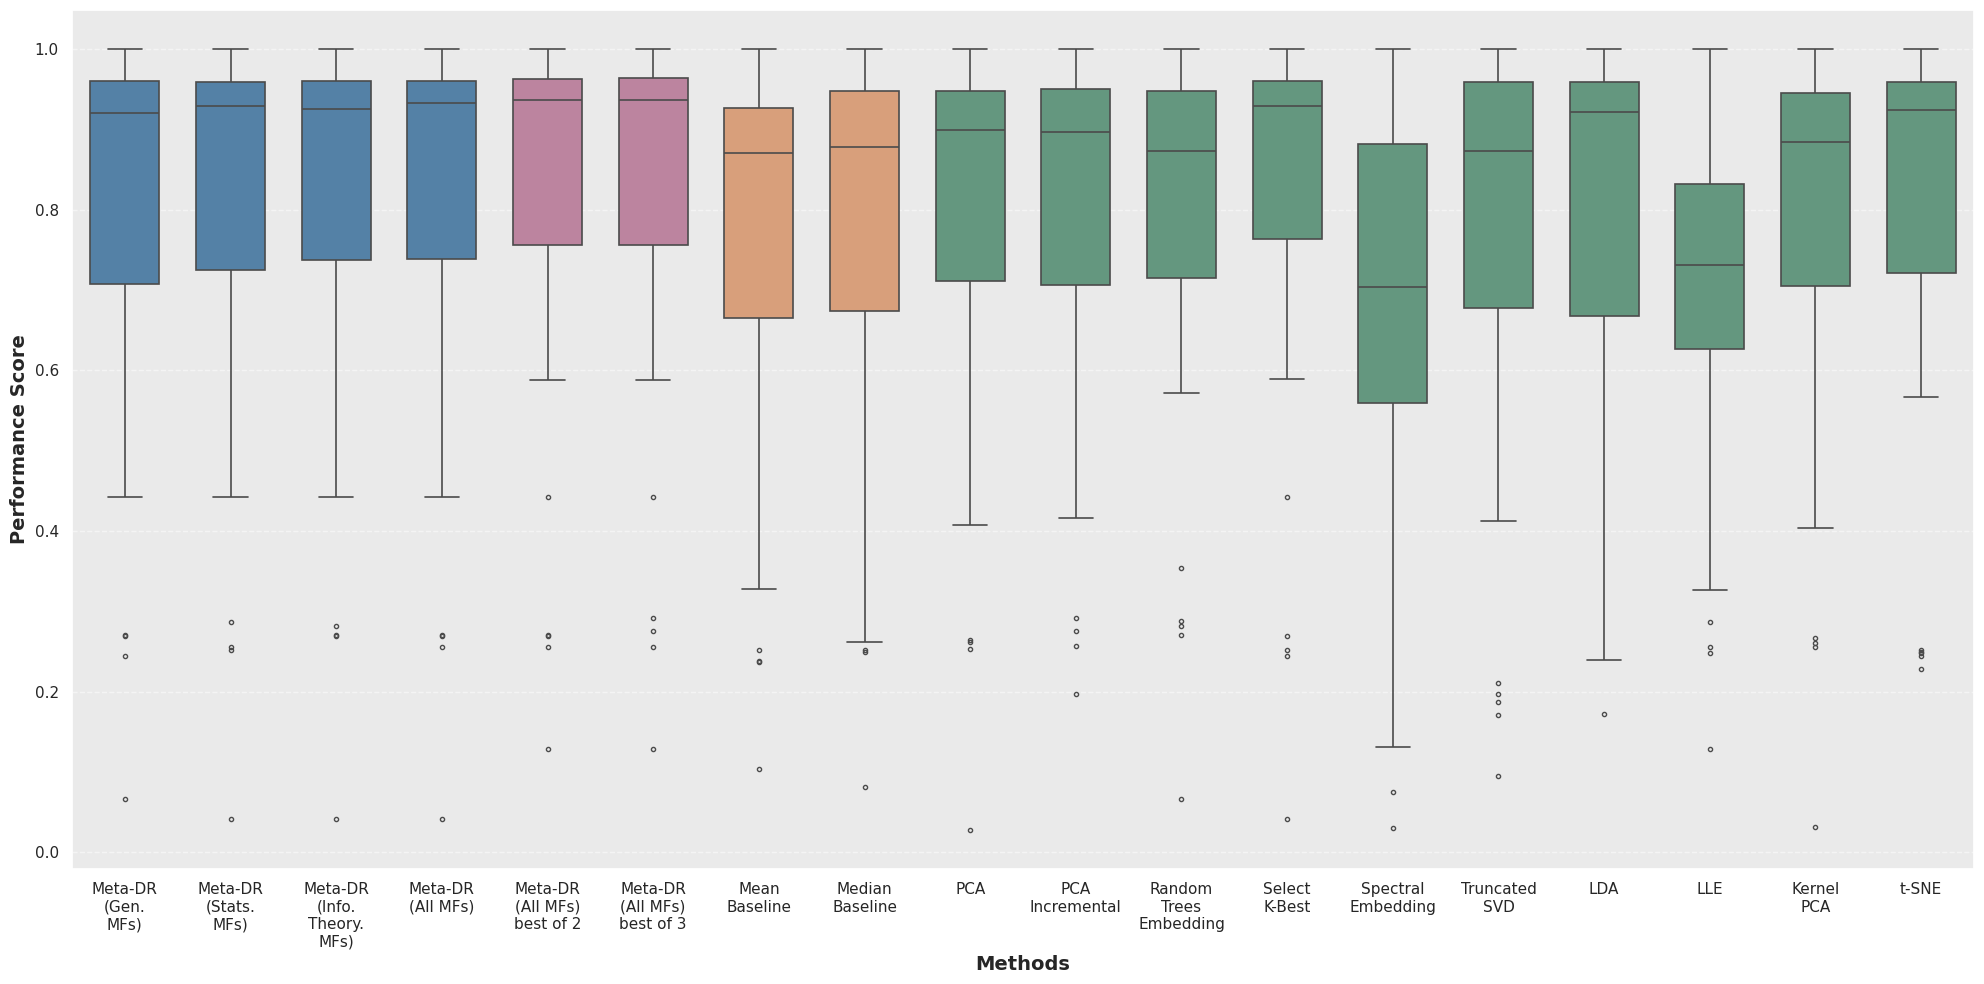

In [ ]:

# Columns to be plotted
columns_to_plot = [
    'General Proposal', 'Statistical Proposal', 'Info-Theory Proposal', 'Unified Proposal',
    'Unified 2-shot', 'Unified 3-shot',
    'Mean Baseline', 'Median Baseline',
    'PCA', 'IncrementalPCA', 'RandomTreesEmbedding', 'SelectKBest',
    'SpectralEmbedding', 'TruncatedSVD', 'LDA', 'LLE', 'KPCA', 't-SNE'
]

# Select only the columns of interest
df_to_plot = final_results_table_nshot[columns_to_plot].copy()

# Rename labels for better visualization
rename_labels_nshot = {
    'General Proposal': 'Meta-DR\n(Gen.\nMFs)',
    'Statistical Proposal': 'Meta-DR\n(Stats.\nMFs)',
    'Info-Theory Proposal': 'Meta-DR\n(Info.\nTheory.\nMFs)',
    'Unified Proposal': 'Meta-DR\n(All MFs)',
    'Unified 2-shot': 'Meta-DR\n(All MFs)\nbest of 2',
    'Unified 3-shot': 'Meta-DR\n(All MFs)\nbest of 3',
    'Mean Baseline': 'Mean\nBaseline',
    'Median Baseline': 'Median\nBaseline',
    'PCA': 'PCA',
    'IncrementalPCA': 'PCA\nIncremental',
    'RandomTreesEmbedding': 'Random\nTrees\nEmbedding',
    'SelectKBest': 'Select\nK-Best',
    'SpectralEmbedding': 'Spectral\nEmbedding',
    'TruncatedSVD': 'Truncated\nSVD',
    'LDA': 'LDA',
    'LLE': 'LLE',
    'KPCA': 'Kernel\nPCA',
    't-SNE': 't-SNE'
}

df_plot_renamed = df_to_plot.rename(columns=rename_labels_nshot)

# Custom colors
custom_colors_nshot = [
    'steelblue', 'steelblue', 'steelblue', 'steelblue',
    '#C57B9F', '#C57B9F',
    '#E79B6C', '#E79B6C',
    '#5C9F7F', '#5C9F7F', '#5C9F7F', '#5C9F7F',
    '#5C9F7F', '#5C9F7F', '#5C9F7F', '#5C9F7F',
    '#5C9F7F', '#5C9F7F'
]

# Plot style
sns.set_style("darkgrid")
sns.set(rc={'axes.facecolor': '#EAEAEA'})

plt.figure(figsize=(20, 10))

ax = sns.boxplot(
    data=df_plot_renamed,
    palette=custom_colors_nshot,
    width=0.65,
    linewidth=1.2,
    fliersize=3
)

# Axis formatting
plt.xticks(rotation=0, fontsize=11, ha="center")
plt.yticks(fontsize=11)
plt.ylabel("Performance Score", fontsize=14, fontweight='bold')
plt.xlabel("Methods", fontsize=14, fontweight='bold')

# Grid only on y-axis
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.grid(axis='x', visible=False)

# Improve spacing
plt.tight_layout()

# Save figure
plt.savefig(
    "Average_Performance_Boxplot.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
from tabulate import tabulate


# =========================================================
# Configuration
# =========================================================
columns_to_analyze = [
    'General Proposal', 'Statistical Proposal', 'Info-Theory Proposal', 'Unified Proposal',
    'Unified 2-shot', 'Unified 3-shot',
    'Mean Baseline', 'Median Baseline',
    'PCA', 'IncrementalPCA', 'RandomTreesEmbedding', 'SelectKBest',
    'SpectralEmbedding', 'TruncatedSVD', 'LDA', 'LLE', 'KPCA', 't-SNE'
]

mdr_methods = {
    'General Proposal': 'MDR (Gen. MFs)',
    'Statistical Proposal': 'MDR (Stats. MFs)',
    'Info-Theory Proposal': 'MDR (Info. Theory. MFs)',
    'Unified Proposal': 'MDR (All MFs)',
    'Unified 2-shot': 'MDR (All MFs) best of 2',
    'Unified 3-shot': 'MDR (All MFs) best of 3'
}

baselines = {
    'Mean Baseline': 'Mean Baseline',
    'Median Baseline': 'Median Baseline'
}

individual_methods = {
    'PCA': 'PCA',
    'IncrementalPCA': 'PCA Incremental',
    'RandomTreesEmbedding': 'Random Trees',
    'SelectKBest': 'Select K-Best',
    'SpectralEmbedding': 'Spectral Embedding',
    'TruncatedSVD': 'Truncated SVD',
    'LDA': 'LDA',
    'LLE': 'LLE',
    'KPCA': 'Kernel PCA',
    't-SNE': 't-SNE'
}


# =========================================================
# Helper function
# =========================================================
def print_table(df, title, floatfmt=".4f", showindex=True):
    print("\n" + "=" * 100)
    print(title)
    print("=" * 100)
    print(tabulate(df, headers="keys", tablefmt="grid", floatfmt=floatfmt, showindex=showindex))
    print()


# =========================================================
# Data selection
# =========================================================
df_to_analyze = final_results_table_nshot[columns_to_analyze].copy()


# =========================================================
# Confidence intervals
# =========================================================
confidence_level = 0.95
alpha = 1 - confidence_level
n = df_to_analyze.shape[0]

means = df_to_analyze.mean()
std_devs = df_to_analyze.std(ddof=1)
sem = std_devs / np.sqrt(n)

try:
    t_critical = stats.t.ppf(1 - alpha / 2, df=n - 1)
except ValueError:
    print(f"Warning: could not compute t-critical value because sample size is too small (n={n}). Using 1.96.")
    t_critical = 1.96

margin_of_error = t_critical * sem
ci_lower = means - margin_of_error
ci_upper = means + margin_of_error

ci_df = pd.DataFrame({
    'Mean': means,
    'CI Lower (95%)': ci_lower,
    'CI Upper (95%)': ci_upper,
    'Margin of Error': margin_of_error
}).reindex(columns_to_analyze)

print_table(ci_df, "95% Confidence Intervals")


# =========================================================
# Build comparisons
# =========================================================
comparisons = []

# Compare each MDR variant against baselines
for mdr_col, mdr_name in mdr_methods.items():
    for baseline_col, baseline_name in baselines.items():
        comparisons.append((
            mdr_name,
            baseline_name,
            df_to_analyze[mdr_col],
            df_to_analyze[baseline_col]
        ))

# Compare each MDR variant against SelectKBest
for mdr_col, mdr_name in mdr_methods.items():
    comparisons.append((
        mdr_name,
        'Select K-Best',
        df_to_analyze[mdr_col],
        df_to_analyze['SelectKBest']
    ))

# Compare unified 1-shot against each individual method
for ind_col, ind_name in individual_methods.items():
    comparisons.append((
        'MDR (All MFs)',
        ind_name,
        df_to_analyze['Unified Proposal'],
        df_to_analyze[ind_col]
    ))

# Compare unified best of 2 against each individual method
for ind_col, ind_name in individual_methods.items():
    comparisons.append((
        'MDR (All MFs) best of 2',
        ind_name,
        df_to_analyze['Unified 2-shot'],
        df_to_analyze[ind_col]
    ))

# Compare unified best of 3 against each individual method
for ind_col, ind_name in individual_methods.items():
    comparisons.append((
        'MDR (All MFs) best of 3',
        ind_name,
        df_to_analyze['Unified 3-shot'],
        df_to_analyze[ind_col]
    ))

# Compare few-shot settings
comparisons.append((
    'MDR (All MFs) best of 2',
    'MDR (All MFs)',
    df_to_analyze['Unified 2-shot'],
    df_to_analyze['Unified Proposal']
))

comparisons.append((
    'MDR (All MFs) best of 3',
    'MDR (All MFs)',
    df_to_analyze['Unified 3-shot'],
    df_to_analyze['Unified Proposal']
))

comparisons.append((
    'MDR (All MFs) best of 3',
    'MDR (All MFs) best of 2',
    df_to_analyze['Unified 3-shot'],
    df_to_analyze['Unified 2-shot']
))


# =========================================================
# Hypothesis tests
# =========================================================
results_summary = []
alpha_test = 0.05

for method1_name, method2_name, data1, data2 in comparisons:
    mask = ~(np.isnan(data1) | np.isnan(data2))
    data1_clean = data1[mask].values
    data2_clean = data2[mask].values
    differences = data1_clean - data2_clean

    # Skip invalid comparisons
    if len(differences) < 8:
        results_summary.append({
            'Method 1': method1_name,
            'Method 2': method2_name,
            'Test': 'Insufficient sample',
            'p-value': np.nan,
            'Significant?': 'No',
            'Winner': 'Undefined',
            'Mean Difference': np.mean(differences) if len(differences) > 0 else np.nan
        })
        continue

    # Check normality of paired differences
    stat_norm, p_norm = stats.normaltest(differences)
    is_normal = p_norm > 0.05

    if is_normal:
        stat, p_value = stats.ttest_rel(data1_clean, data2_clean)
        test_name = 'Paired t-test'
    else:
        try:
            stat, p_value = stats.wilcoxon(data1_clean, data2_clean, alternative='two-sided')
            test_name = 'Wilcoxon signed-rank'
        except ValueError:
            stat, p_value = np.nan, 1.0
            test_name = 'Wilcoxon signed-rank'

    mean_diff = np.mean(differences)

    if p_value < alpha_test:
        winner = method1_name if mean_diff > 0 else method2_name
        significant = 'Yes'
    else:
        winner = 'Tie'
        significant = 'No'

    results_summary.append({
        'Method 1': method1_name,
        'Method 2': method2_name,
        'Test': test_name,
        'p-value': p_value,
        'Significant?': significant,
        'Winner': winner,
        'Mean Difference': mean_diff
    })

results_df = pd.DataFrame(results_summary)
print_table(results_df, "Hypothesis Test Summary", showindex=False)


# =========================================================
# Essential summaries
# =========================================================
vs_selectkbest_df = results_df[results_df['Method 2'] == 'Select K-Best'].copy()
print_table(vs_selectkbest_df, "MDR vs SelectKBest", showindex=False)

fewshot_df = results_df[
    (
        (results_df['Method 1'] == 'MDR (All MFs) best of 2') &
        (results_df['Method 2'] == 'MDR (All MFs)')
    ) |
    (
        (results_df['Method 1'] == 'MDR (All MFs) best of 3') &
        (results_df['Method 2'] == 'MDR (All MFs)')
    ) |
    (
        (results_df['Method 1'] == 'MDR (All MFs) best of 3') &
        (results_df['Method 2'] == 'MDR (All MFs) best of 2')
    )
].copy()

print_table(fewshot_df, "Few-Shot Comparison Summary", showindex=False)


95% Confidence Intervals
+----------------------+--------+------------------+------------------+-------------------+
|                      |   Mean |   CI Lower (95%) |   CI Upper (95%) |   Margin of Error |
+======================+========+==================+==================+===================+
| General Proposal     | 0.8280 |           0.7788 |           0.8772 |            0.0492 |
+----------------------+--------+------------------+------------------+-------------------+
| Statistical Proposal | 0.8289 |           0.7798 |           0.8780 |            0.0491 |
+----------------------+--------+------------------+------------------+-------------------+
| Info-Theory Proposal | 0.8309 |           0.7821 |           0.8798 |            0.0489 |
+----------------------+--------+------------------+------------------+-------------------+
| Unified Proposal     | 0.8281 |           0.7786 |           0.8777 |            0.0495 |
+----------------------+--------+------------------+--

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
from tabulate import tabulate


# =========================================================
# Configuration
# =========================================================
columns_to_analyze = [
    'General Proposal', 'Statistical Proposal', 'Info-Theory Proposal', 'Unified Proposal',
    'Unified 2-shot', 'Unified 3-shot',
    'Mean Baseline', 'Median Baseline',
    'PCA', 'IncrementalPCA', 'RandomTreesEmbedding', 'SelectKBest',
    'SpectralEmbedding', 'TruncatedSVD', 'LDA', 'LLE', 'KPCA', 't-SNE'
]

mdr_methods = {
    'General Proposal': 'MDR (Gen. MFs)',
    'Statistical Proposal': 'MDR (Stats. MFs)',
    'Info-Theory Proposal': 'MDR (Info. Theory. MFs)',
    'Unified Proposal': 'MDR (All MFs)',
    'Unified 2-shot': 'MDR (All MFs) best of 2',
    'Unified 3-shot': 'MDR (All MFs) best of 3'
}

baselines = {
    'Mean Baseline': 'Mean Baseline',
    'Median Baseline': 'Median Baseline'
}

individual_methods_cols = [
    'PCA', 'IncrementalPCA', 'RandomTreesEmbedding', 'SelectKBest',
    'SpectralEmbedding', 'TruncatedSVD', 'LDA', 'LLE', 'KPCA', 't-SNE'
]

individual_methods_names = {
    'PCA': 'PCA',
    'IncrementalPCA': 'PCA Incremental',
    'RandomTreesEmbedding': 'Random Trees',
    'SelectKBest': 'Select K-Best',
    'SpectralEmbedding': 'Spectral Embedding',
    'TruncatedSVD': 'Truncated SVD',
    'LDA': 'LDA',
    'LLE': 'LLE',
    'KPCA': 'Kernel PCA',
    't-SNE': 't-SNE'
}

best_individual_col = 'SelectKBest'


# =========================================================
# Helper function
# =========================================================
def print_table(df, title, floatfmt=".4f", showindex=False):
    print("\n" + "=" * 100)
    print(title)
    print("=" * 100)
    print(tabulate(df, headers="keys", tablefmt="grid", floatfmt=floatfmt, showindex=showindex))
    print()


# =========================================================
# Data selection
# =========================================================
df_to_analyze = final_results_table_nshot[columns_to_analyze].copy()


# =========================================================
# Confidence intervals
# =========================================================
confidence_level = 0.95
alpha = 1 - confidence_level
n = df_to_analyze.shape[0]

means = df_to_analyze.mean()
std_devs = df_to_analyze.std(ddof=1)
sem = std_devs / np.sqrt(n)

try:
    t_critical = stats.t.ppf(1 - alpha / 2, df=n - 1)
except ValueError:
    print(f"Warning: could not compute the t-critical value because the sample size is too small (n={n}). Using 1.96.")
    t_critical = 1.96

margin_of_error = t_critical * sem
ci_lower = means - margin_of_error
ci_upper = means + margin_of_error

ci_df = pd.DataFrame({
    'Method': columns_to_analyze,
    'Mean': [means[col] for col in columns_to_analyze],
    'CI Lower (95%)': [ci_lower[col] for col in columns_to_analyze],
    'CI Upper (95%)': [ci_upper[col] for col in columns_to_analyze],
    'Margin of Error': [margin_of_error[col] for col in columns_to_analyze]
})

print_table(ci_df, "95% Confidence Intervals")


# =========================================================
# Build comparisons
# =========================================================
comparisons = []

# 1. Compare each MDR variant against baselines
for mdr_col, mdr_name in mdr_methods.items():
    for baseline_col, baseline_name in baselines.items():
        comparisons.append((
            mdr_name,
            baseline_name,
            df_to_analyze[mdr_col],
            df_to_analyze[baseline_col]
        ))

# 2. Compare each MDR variant against SelectKBest
for mdr_col, mdr_name in mdr_methods.items():
    comparisons.append((
        mdr_name,
        'Select K-Best',
        df_to_analyze[mdr_col],
        df_to_analyze[best_individual_col]
    ))

# 3. Compare unified MDR variants against each individual method
unified_mdr_comps = [
    ('Unified Proposal', 'MDR (All MFs)'),
    ('Unified 2-shot', 'MDR (All MFs) best of 2'),
    ('Unified 3-shot', 'MDR (All MFs) best of 3')
]

for unified_col, unified_name in unified_mdr_comps:
    for ind_col in individual_methods_cols:
        comparisons.append((
            unified_name,
            individual_methods_names[ind_col],
            df_to_analyze[unified_col],
            df_to_analyze[ind_col]
        ))

# 4. Compare few-shot settings
comparisons.append((
    'MDR (All MFs) best of 2',
    'MDR (All MFs)',
    df_to_analyze['Unified 2-shot'],
    df_to_analyze['Unified Proposal']
))

comparisons.append((
    'MDR (All MFs) best of 3',
    'MDR (All MFs)',
    df_to_analyze['Unified 3-shot'],
    df_to_analyze['Unified Proposal']
))

comparisons.append((
    'MDR (All MFs) best of 3',
    'MDR (All MFs) best of 2',
    df_to_analyze['Unified 3-shot'],
    df_to_analyze['Unified 2-shot']
))


# =========================================================
# Wilcoxon hypothesis tests
# =========================================================
results_summary = []
alpha_test = 0.05

for method1_name, method2_name, data1, data2 in comparisons:
    mask = ~(np.isnan(data1) | np.isnan(data2))
    data1_clean = data1[mask].values
    data2_clean = data2[mask].values
    differences = data1_clean - data2_clean

    sample_size = len(data1_clean)
    mean_1 = np.mean(data1_clean) if sample_size > 0 else np.nan
    mean_2 = np.mean(data2_clean) if sample_size > 0 else np.nan
    mean_diff = np.mean(differences) if sample_size > 0 else np.nan

    # Normality is reported only as complementary information
    if sample_size >= 8:
        try:
            _, p_norm = stats.normaltest(differences)
            normality = 'Yes' if p_norm > 0.05 else 'No'
        except Exception:
            normality = 'Undefined'
    else:
        normality = 'Undefined'

    # Wilcoxon signed-rank test
    try:
        stat, p_value = stats.wilcoxon(
            data1_clean,
            data2_clean,
            alternative='two-sided',
            zero_method='wilcox'
        )
        test_name = 'Wilcoxon signed-rank'
    except ValueError:
        stat, p_value = np.nan, np.nan
        test_name = 'Wilcoxon signed-rank'

    if pd.notna(p_value) and p_value < alpha_test:
        winner = method1_name if mean_diff > 0 else method2_name
        significant = 'Yes'
    elif pd.notna(p_value):
        winner = 'Tie'
        significant = 'No'
    else:
        winner = 'Undefined'
        significant = 'Undefined'

    results_summary.append({
        'Method 1': method1_name,
        'Method 2': method2_name,
        'N': sample_size,
        'Mean 1': mean_1,
        'Mean 2': mean_2,
        'Mean Difference': mean_diff,
        'Normal?': normality,
        'Test': test_name,
        'W Statistic': stat,
        'p-value': p_value,
        'Significant?': significant,
        'Winner': winner
    })

results_df = pd.DataFrame(results_summary)

print_table(results_df, "Wilcoxon Hypothesis Test Summary")


# =========================================================
# Essential summary 1: MDR vs SelectKBest
# =========================================================
vs_selectkbest_df = results_df[results_df['Method 2'] == 'Select K-Best'].copy()
print_table(vs_selectkbest_df, "MDR vs SelectKBest")


# =========================================================
# Essential summary 2: Few-shot comparisons
# =========================================================
fewshot_df = results_df[
    (
        (results_df['Method 1'] == 'MDR (All MFs) best of 2') &
        (results_df['Method 2'] == 'MDR (All MFs)')
    ) |
    (
        (results_df['Method 1'] == 'MDR (All MFs) best of 3') &
        (results_df['Method 2'] == 'MDR (All MFs)')
    ) |
    (
        (results_df['Method 1'] == 'MDR (All MFs) best of 3') &
        (results_df['Method 2'] == 'MDR (All MFs) best of 2')
    )
].copy()

print_table(fewshot_df, "Few-Shot Comparison Summary")


95% Confidence Intervals
+----------------------+--------+------------------+------------------+-------------------+
| Method               |   Mean |   CI Lower (95%) |   CI Upper (95%) |   Margin of Error |
+======================+========+==================+==================+===================+
| General Proposal     | 0.8280 |           0.7788 |           0.8772 |            0.0492 |
+----------------------+--------+------------------+------------------+-------------------+
| Statistical Proposal | 0.8289 |           0.7798 |           0.8780 |            0.0491 |
+----------------------+--------+------------------+------------------+-------------------+
| Info-Theory Proposal | 0.8309 |           0.7821 |           0.8798 |            0.0489 |
+----------------------+--------+------------------+------------------+-------------------+
| Unified Proposal     | 0.8281 |           0.7786 |           0.8777 |            0.0495 |
+----------------------+--------+------------------+--

In [ ]:
import pandas as pd
from tabulate import tabulate


# =========================================================
# Build a compact results table for the paper
# =========================================================
if 'results_summary' in globals() and len(results_summary) > 0:
    results_table = pd.DataFrame(results_summary)

    # Map display names back to original dataframe column names
    name_to_column = {
        'MDR (Gen. MFs)': 'General Proposal',
        'MDR (Stats. MFs)': 'Statistical Proposal',
        'MDR (Info. Theory. MFs)': 'Info-Theory Proposal',
        'MDR (All MFs)': 'Unified Proposal',
        'MDR (All MFs) best of 2': 'Unified 2-shot',
        'MDR (All MFs) best of 3': 'Unified 3-shot',
        'Mean Baseline': 'Mean Baseline',
        'Median Baseline': 'Median Baseline',
        'PCA': 'PCA',
        'PCA Incremental': 'IncrementalPCA',
        'Random Trees': 'RandomTreesEmbedding',
        'Select K-Best': 'SelectKBest',
        'Spectral Embedding': 'SpectralEmbedding',
        'Truncated SVD': 'TruncatedSVD',
        'LDA': 'LDA',
        'LLE': 'LLE',
        'Kernel PCA': 'KPCA',
        't-SNE': 't-SNE'
    }

    # Adjust these names depending on the language used in results_summary
    method1_col = 'Method 1' if 'Method 1' in results_table.columns else 'Método 1'
    method2_col = 'Method 2' if 'Method 2' in results_table.columns else 'Método 2'
    mean_diff_col = 'Mean Difference' if 'Mean Difference' in results_table.columns else 'Diferença média'
    pvalue_col = 'p-value' if 'p-value' in results_table.columns else 'p-valor'

    mean1_list = []
    mean2_list = []

    for _, row in results_table.iterrows():
        method1 = row[method1_col]
        method2 = row[method2_col]

        col1 = name_to_column.get(method1, method1)
        col2 = name_to_column.get(method2, method2)

        if col1 in df_to_plot.columns and col2 in df_to_plot.columns:
            mean1_list.append(df_to_plot[col1].mean())
            mean2_list.append(df_to_plot[col2].mean())
        else:
            mean1_list.append(None)
            mean2_list.append(None)

    results_table['Mean Method 1'] = mean1_list
    results_table['Mean Method 2'] = mean2_list

    # Keep only the essential columns for the paper
    compact_table = results_table[[
        method1_col,
        method2_col,
        'Mean Method 1',
        'Mean Method 2',
        mean_diff_col,
        pvalue_col
    ]].copy()

    # Rename columns to a clean final format
    compact_table.columns = [
        'Method 1',
        'Method 2',
        'Mean Method 1',
        'Mean Method 2',
        'Mean Difference',
        'p-value'
    ]

    compact_table = compact_table.sort_values(['Method 1', 'Method 2']).reset_index(drop=True)

    print("\n" + "=" * 120)
    print("COMPACT TABLE WITH HYPOTHESIS TEST RESULTS")
    print("=" * 120)
    print(
        tabulate(
            compact_table,
            headers='keys',
            tablefmt='grid',
            floatfmt=".4f",
            showindex=False
        )
    )
    print("=" * 120 + "\n")

else:
    print("Error: the variable 'results_summary' was not found or is empty.")


COMPACT TABLE WITH HYPOTHESIS TEST RESULTS
+-------------------------+-------------------------+-----------------+-----------------+-------------------+-----------+
| Method 1                | Method 2                |   Mean Method 1 |   Mean Method 2 |   Mean Difference |   p-value |
+=========================+=========================+=================+=================+===================+===========+
| MDR (All MFs)           | Kernel PCA              |          0.8281 |          0.8049 |            0.0233 |    0.0000 |
+-------------------------+-------------------------+-----------------+-----------------+-------------------+-----------+
| MDR (All MFs)           | LDA                     |          0.8281 |          0.8106 |            0.0175 |    0.0007 |
+-------------------------+-------------------------+-----------------+-----------------+-------------------+-----------+
| MDR (All MFs)           | LLE                     |          0.8281 |          0.7172 |            0

In [ ]:
# Build a single table with all hypothesis test results
if 'results_summary' in globals() and len(results_summary) > 0:
    results_table = pd.DataFrame(results_summary).copy()

    # Map display names back to the original dataframe column names
    name_to_column = {
        'MDR (Gen. MFs)': 'General Proposal',
        'MDR (Stats. MFs)': 'Statistical Proposal',
        'MDR (Info. Theory. MFs)': 'Info-Theory Proposal',
        'MDR (All MFs)': 'Unified Proposal',
        'MDR (All MFs) best of 2': 'Unified 2-shot',
        'MDR (All MFs) best of 3': 'Unified 3-shot',
        'Mean Baseline': 'Mean Baseline',
        'Median Baseline': 'Median Baseline',
        'PCA': 'PCA',
        'PCA Incremental': 'IncrementalPCA',
        'Random Trees': 'RandomTreesEmbedding',
        'Select K-Best': 'SelectKBest',
        'Spectral Embedding': 'SpectralEmbedding',
        'Truncated SVD': 'TruncatedSVD',
        'LDA': 'LDA',
        'LLE': 'LLE',
        'Kernel PCA': 'KPCA',
        't-SNE': 't-SNE'
    }

    # Detect column names automatically
    method1_col = 'Method 1' if 'Method 1' in results_table.columns else 'Método 1'
    method2_col = 'Method 2' if 'Method 2' in results_table.columns else 'Método 2'
    mean_diff_col = 'Mean Difference' if 'Mean Difference' in results_table.columns else 'Diferença média'
    normal_col = 'Normal?' if 'Normal?' in results_table.columns else None
    test_col = 'Test' if 'Test' in results_table.columns else 'Teste' if 'Teste' in results_table.columns else None
    stat_col = 'Statistic' if 'Statistic' in results_table.columns else 'Estatística' if 'Estatística' in results_table.columns else 'W Statistic' if 'W Statistic' in results_table.columns else 'Estatística (W)' if 'Estatística (W)' in results_table.columns else None
    pvalue_col = 'p-value' if 'p-value' in results_table.columns else 'p-valor'
    significant_col = 'Significant?' if 'Significant?' in results_table.columns else 'Significativo?' if 'Significativo?' in results_table.columns else None
    winner_col = 'Winner' if 'Winner' in results_table.columns else 'Melhor' if 'Melhor' in results_table.columns else None
    interpretation_col = 'Interpretation' if 'Interpretation' in results_table.columns else 'Interpretação' if 'Interpretação' in results_table.columns else None

    mean_method_1 = []
    mean_method_2 = []

    # Compute method means for each comparison
    for _, row in results_table.iterrows():
        method1 = row[method1_col]
        method2 = row[method2_col]

        col1 = name_to_column.get(method1, method1)
        col2 = name_to_column.get(method2, method2)

        if col1 in df_to_plot.columns:
            mean_method_1.append(df_to_plot[col1].mean())
        else:
            mean_method_1.append(None)

        if col2 in df_to_plot.columns:
            mean_method_2.append(df_to_plot[col2].mean())
        else:
            mean_method_2.append(None)

    # Add mean columns
    results_table['Mean Method 1'] = mean_method_1
    results_table['Mean Method 2'] = mean_method_2

    # Select columns in a clean order
    ordered_columns = [
        method1_col,
        method2_col,
        'Mean Method 1',
        'Mean Method 2',
        mean_diff_col,
        normal_col,
        test_col,
        stat_col,
        pvalue_col,
        significant_col,
        winner_col,
        interpretation_col
    ]

    ordered_columns = [col for col in ordered_columns if col is not None and col in results_table.columns]
    results_table = results_table[ordered_columns].copy()

    # Rename columns to a standard English format
    rename_map = {
        method1_col: 'Method 1',
        method2_col: 'Method 2',
        mean_diff_col: 'Mean Difference',
        normal_col: 'Normal?',
        test_col: 'Test',
        stat_col: 'Statistic',
        pvalue_col: 'p-value',
        significant_col: 'Significant?',
        winner_col: 'Winner',
        interpretation_col: 'Interpretation'
    }
    results_table = results_table.rename(columns={k: v for k, v in rename_map.items() if k is not None})

    # Sort results
    results_table = results_table.sort_values(['Method 1', 'Method 2']).reset_index(drop=True)

    # Print final table using tabulate
    print("\n" + "=" * 140)
    print("FULL TABLE WITH ALL HYPOTHESIS TEST RESULTS")
    print("=" * 140)
    print(
        tabulate(
            results_table,
            headers='keys',
            tablefmt='grid',
            floatfmt=".4f",
            showindex=False
        )
    )
    print("=" * 140 + "\n")

    # Optional: save as CSV
    # results_table.to_csv('hypothesis_test_results.csv', index=False)

else:
    print("Error: the variable 'results_summary' was not found.")
    print("Please run the previous cell containing the hypothesis tests first.")


FULL TABLE WITH ALL HYPOTHESIS TEST RESULTS
+-------------------------+-------------------------+-----------------+-----------------+-------------------+-----------+----------------------+-------------+-----------+----------------+-------------------------+
| Method 1                | Method 2                |   Mean Method 1 |   Mean Method 2 |   Mean Difference | Normal?   | Test                 |   Statistic |   p-value | Significant?   | Winner                  |
+=========================+=========================+=================+=================+===================+===========+======================+=============+===========+================+=========================+
| MDR (All MFs)           | Kernel PCA              |          0.8281 |          0.8049 |            0.0233 | No        | Wilcoxon signed-rank |    285.0000 |    0.0000 | Yes            | MDR (All MFs)           |
+-------------------------+-------------------------+-----------------+-----------------+----------

In [ ]:
# Pairwise comparisons
comparisons = [
    ('MDR (Gen. MFs)', 'Mean Baseline', df_general['General Proposal'], df_general['Mean Baseline']),
    ('MDR (Gen. MFs)', 'Median Baseline', df_general['General Proposal'], df_general['Median Baseline']),
    ('MDR (Stats. MFs)', 'Mean Baseline', df_statistical['Statistical Proposal'], df_statistical['Mean Baseline']),
    ('MDR (Stats. MFs)', 'Median Baseline', df_statistical['Statistical Proposal'], df_statistical['Median Baseline']),
    ('MDR (Info. Theory. MFs)', 'Mean Baseline', df_info_theory['Info-Theory Proposal'], df_info_theory['Mean Baseline']),
    ('MDR (Info. Theory. MFs)', 'Median Baseline', df_info_theory['Info-Theory Proposal'], df_info_theory['Median Baseline']),
    ('MDR (All MFs)', 'Mean Baseline', df_all_metafeatures['Unified Proposal'], df_all_metafeatures['Mean Baseline']),
    ('MDR (All MFs)', 'Median Baseline', df_all_metafeatures['Unified Proposal'], df_all_metafeatures['Median Baseline']),
]

# Bonferroni correction
alpha_family = 0.05
n_comparisons = len(comparisons)
alpha_corrected = alpha_family / n_comparisons

print(f"\nBonferroni correction: m = {n_comparisons}, corrected alpha = {alpha_corrected:.6f}\n")

# Hypothesis tests
results_summary = []

for method1_name, method2_name, data1, data2 in comparisons:
    # Remove missing values pairwise
    mask = ~(np.isnan(data1) | np.isnan(data2))
    data1_clean = data1[mask].values
    data2_clean = data2[mask].values
    differences = data1_clean - data2_clean

    sample_size = len(differences)
    mean_1 = np.mean(data1_clean)
    mean_2 = np.mean(data2_clean)
    mean_diff = np.mean(differences)

    # Normality test on paired differences
    if sample_size >= 8:
        try:
            _, p_norm = stats.normaltest(differences)
            is_normal = p_norm > 0.05
            normality_label = 'Yes' if is_normal else 'No'
        except Exception:
            p_norm = np.nan
            is_normal = False
            normality_label = 'Undefined'
    else:
        p_norm = np.nan
        is_normal = False
        normality_label = 'Undefined'

    # Paired statistical test
    if is_normal:
        stat, p_value = stats.ttest_rel(data1_clean, data2_clean)
        test_name = 'Paired t-test'
    else:
        try:
            stat, p_value = stats.wilcoxon(data1_clean, data2_clean, alternative='two-sided')
            test_name = 'Wilcoxon signed-rank'
        except ValueError:
            stat, p_value = np.nan, np.nan
            test_name = 'Wilcoxon signed-rank'

    # Bonferroni-adjusted p-value
    p_bonf = min(p_value * n_comparisons, 1.0) if pd.notna(p_value) else np.nan

    # Significance decision using corrected alpha
    is_significant = pd.notna(p_value) and (p_value < alpha_corrected)

    if is_significant:
        winner = method1_name if mean_diff > 0 else method2_name
    else:
        winner = 'Tie'

    results_summary.append({
        'Method 1': method1_name,
        'Method 2': method2_name,
        'N': sample_size,
        'Mean 1': mean_1,
        'Mean 2': mean_2,
        'Mean Difference': mean_diff,
        'Normal?': normality_label,
        'Normality p-value': p_norm,
        'Test': test_name,
        'Statistic': stat,
        'p-value': p_value,
        'Bonferroni p-value': p_bonf,
        'Corrected alpha': alpha_corrected,
        'Significant?': 'Yes' if is_significant else 'No',
        'Winner': winner
    })

# Final results table
results_df = pd.DataFrame(results_summary)

print(
    tabulate(
        results_df,
        headers='keys',
        tablefmt='grid',
        floatfmt=".6f",
        showindex=False
    )
)


Bonferroni correction: m = 8, corrected alpha = 0.006250

+-------------------------+-----------------+-----+----------+----------+-------------------+-----------+---------------------+---------------+-------------+-----------+----------------------+-------------------+----------------+-------------------------+
| Method 1                | Method 2        |   N |   Mean 1 |   Mean 2 |   Mean Difference | Normal?   |   Normality p-value | Test          |   Statistic |   p-value |   Bonferroni p-value |   Corrected alpha | Significant?   | Winner                  |
+=========================+=================+=====+==========+==========+===================+===========+=====================+===============+=============+===========+======================+===================+================+=========================+
| MDR (Gen. MFs)          | Mean Baseline   |  66 | 0.585519 | 0.501800 |          0.083719 | Yes       |            0.118857 | Paired t-test |    2.227153 |  0.029406 |    

 # Critical Difference (CD) Diagram

Friedman statistic: 455.910379
Friedman p-value: 3.560073e-86
Number of methods: 18
Number of datasets: 68
q_alpha: 3.488858
Critical Difference (CD): 3.1942

Average ranks:
                     Method  Average Rank
Meta-DR (All MFs) best of 3      4.088235
Meta-DR (All MFs) best of 2      5.044118
              Select K-Best      6.558824
Meta-DR (Info. Theory. MFs)      6.808824
          Meta-DR (All MFs)      6.963235
       Meta-DR (Stats. MFs)      7.147059
         Meta-DR (Gen. MFs)      7.389706
                      t-SNE      9.080882
                        LDA      9.477941
            PCA Incremental      9.852941
                        PCA     10.345588
                 Kernel PCA     10.977941
     Random Trees Embedding     11.161765
            Median Baseline     11.330882
              Truncated SVD     11.727941
                        LLE     13.139706
              Mean Baseline     13.286765
         Spectral Embedding     16.617647

Non-significant groups (sor

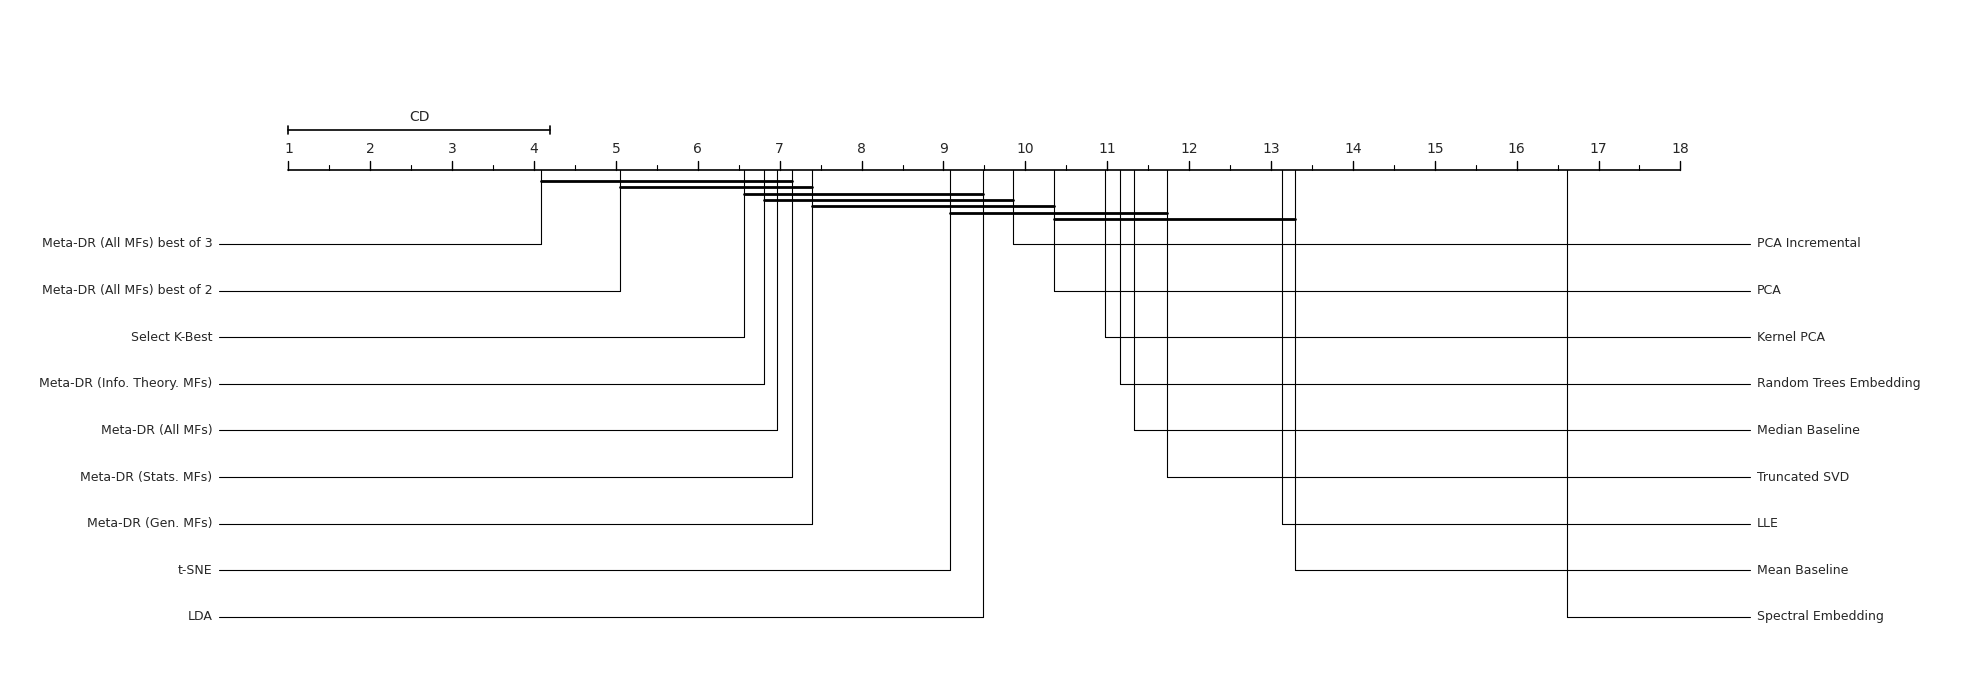

In [ ]:

# 1) Methods to compare
columns_cd = [
    'General Proposal', 'Statistical Proposal', 'Info-Theory Proposal', 'Unified Proposal',
    'Unified 2-shot', 'Unified 3-shot',
    'Mean Baseline', 'Median Baseline',
    'PCA', 'IncrementalPCA', 'RandomTreesEmbedding', 'SelectKBest',
    'SpectralEmbedding', 'TruncatedSVD', 'LDA', 'LLE', 'KPCA', 't-SNE'
]

# 2) Display labels
rename_labels_nshot = {
    'General Proposal': 'Meta-DR (Gen. MFs)',
    'Statistical Proposal': 'Meta-DR (Stats. MFs)',
    'Info-Theory Proposal': 'Meta-DR (Info. Theory. MFs)',
    'Unified Proposal': 'Meta-DR (All MFs)',
    'Unified 2-shot': 'Meta-DR (All MFs) best of 2',
    'Unified 3-shot': 'Meta-DR (All MFs) best of 3',
    'Mean Baseline': 'Mean Baseline',
    'Median Baseline': 'Median Baseline',
    'PCA': 'PCA',
    'IncrementalPCA': 'PCA Incremental',
    'RandomTreesEmbedding': 'Random Trees Embedding',
    'SelectKBest': 'Select K-Best',
    'SpectralEmbedding': 'Spectral Embedding',
    'TruncatedSVD': 'Truncated SVD',
    'LDA': 'LDA',
    'LLE': 'LLE',
    'KPCA': 'Kernel PCA',
    't-SNE': 't-SNE'
}

# 3) Load data
df_cd = final_results_table_nshot[columns_cd].copy()
df_cd = df_cd.dropna().reset_index(drop=True)

# 4) Compute ranks for each dataset
# Higher value = better performance -> rank 1
ranks = df_cd.apply(
    lambda row: rankdata(-row.values, method='average'),
    axis=1,
    result_type='expand'
)
ranks.columns = columns_cd
avg_ranks = ranks.mean(axis=0)

# 5) Friedman test
friedman_stat, friedman_p = friedmanchisquare(
    *[df_cd[col].values for col in columns_cd]
)

print(f"Friedman statistic: {friedman_stat:.6f}")
print(f"Friedman p-value: {friedman_p:.6e}")

# 6) Critical Difference (Nemenyi)
k = len(columns_cd)
N = len(df_cd)

try:
    from statsmodels.stats.libqsturng import qsturng
    q_alpha = qsturng(0.95, k, np.inf) / np.sqrt(2)
except Exception:
    q_alpha = 3.458  # fallback value

CD = q_alpha * sqrt(k * (k + 1) / (6 * N))

print(f"Number of methods: {k}")
print(f"Number of datasets: {N}")
print(f"q_alpha: {q_alpha:.6f}")
print(f"Critical Difference (CD): {CD:.4f}")

# 7) Sort methods by average rank
order = np.argsort(avg_ranks.values)
avg_ranks_sorted = avg_ranks.values[order]
columns_sorted = [columns_cd[i] for i in order]
names_sorted = [rename_labels_nshot[col] for col in columns_sorted]

avg_ranks_table = pd.DataFrame({
    'Method': names_sorted,
    'Average Rank': avg_ranks_sorted
})

print("\nAverage ranks:")
print(avg_ranks_table.to_string(index=False))

# 8) Find non-significant groups
# Two methods belong to the same group if their rank
# difference is smaller than or equal to CD
groups = []
n_methods = len(avg_ranks_sorted)

for i in range(n_methods):
    j = i
    while j + 1 < n_methods and (avg_ranks_sorted[j + 1] - avg_ranks_sorted[i]) <= CD:
        j += 1
    if j > i:
        groups.append((i, j))

# Remove redundant groups
filtered_groups = []
for g in groups:
    is_contained = False
    for h in groups:
        if g != h and g[0] >= h[0] and g[1] <= h[1]:
            if (g[1] - g[0]) < (h[1] - h[0]):
                is_contained = True
                break
    if not is_contained:
        filtered_groups.append(g)

groups = []
seen = set()
for g in filtered_groups:
    if g not in seen:
        groups.append(g)
        seen.add(g)

print("\nNon-significant groups (sorted positions):")
for group in groups:
    print(group)

# 9) CD diagram function
def plot_cd_diagram(
    avg_ranks,
    names,
    cd,
    groups,
    title="Critical Difference Diagram",
    filename="cd_diagram.pdf"
):
    n_methods = len(avg_ranks)

    # Split methods into left and right sides
    half = int(np.ceil(n_methods / 2))
    left_idx = list(range(half))
    right_idx = list(range(half, n_methods))

    # Vertical positions
    left_y_positions = np.linspace(-0.15, -len(left_idx) * 0.38, len(left_idx))
    right_y_positions = np.linspace(-0.15, -len(right_idx) * 0.38, len(right_idx))

    # Figure limits
    left_margin = 3.4
    right_margin = 3.4
    top = 1.0
    bottom = min(
        left_y_positions.min() if len(left_y_positions) else 0,
        right_y_positions.min() if len(right_y_positions) else 0
    ) - 0.50

    min_rank = 1
    max_rank = n_methods

    fig, ax = plt.subplots(figsize=(20, 7))
    ax.set_axis_off()
    ax.set_xlim(min_rank - left_margin, max_rank + right_margin)
    ax.set_ylim(bottom, top + 0.9)

    # Main rank axis
    axis_y = 0.50
    ax.plot([min_rank, max_rank], [axis_y, axis_y], color="black", lw=1.2)

    for rank in range(min_rank, max_rank + 1):
        ax.plot([rank, rank], [axis_y, axis_y + 0.08], color="black", lw=1.0)
        ax.text(rank, axis_y + 0.12, str(rank), ha="center", va="bottom", fontsize=10)

    for rank in np.arange(min_rank + 0.5, max_rank, 1.0):
        ax.plot([rank, rank], [axis_y, axis_y + 0.04], color="black", lw=0.8)

    # CD bar
    cd_y = axis_y + 0.35
    cd_x0 = min_rank
    cd_x1 = min_rank + cd

    ax.plot([cd_x0, cd_x1], [cd_y, cd_y], color="black", lw=1.2)
    ax.plot([cd_x0, cd_x0], [cd_y - 0.035, cd_y + 0.035], color="black", lw=1.2)
    ax.plot([cd_x1, cd_x1], [cd_y - 0.035, cd_y + 0.035], color="black", lw=1.2)
    ax.text((cd_x0 + cd_x1) / 2, cd_y + 0.05, "CD", ha="center", va="bottom", fontsize=10)

    # Left-side methods
    left_text_x = min_rank - 0.85
    for plot_idx, method_idx in enumerate(left_idx):
        x = avg_ranks[method_idx]
        y = left_y_positions[plot_idx]

        ax.plot([x, x], [axis_y, y], color="black", lw=0.8)
        ax.plot([left_text_x, x], [y, y], color="black", lw=0.8)
        ax.text(left_text_x - 0.08, y, names[method_idx], ha="right", va="center", fontsize=9)

    # Right-side methods
    right_text_x = max_rank + 0.85
    for plot_idx, method_idx in enumerate(right_idx):
        x = avg_ranks[method_idx]
        y = right_y_positions[plot_idx]

        ax.plot([x, x], [axis_y, y], color="black", lw=0.8)
        ax.plot([x, right_text_x], [y, y], color="black", lw=0.8)
        ax.text(right_text_x + 0.08, y, names[method_idx], ha="left", va="center", fontsize=9)

    # Non-significant groups
    group_y_start = axis_y - 0.10
    step = 0.055

    for group_idx, (i, j) in enumerate(groups):
        y = group_y_start - group_idx * step
        x0 = avg_ranks[i]
        x1 = avg_ranks[j]
        ax.plot([x0, x1], [y, y], color="black", lw=2.0)

    # Title
    if title:
        ax.text(
            (min_rank + max_rank) / 2,
            top + 0.45,
            title,
            ha="center",
            va="center",
            fontsize=13
        )

    plt.tight_layout()
    plt.savefig(filename, format="pdf", bbox_inches="tight", dpi=300)
    plt.show()

# 10) Plot the CD diagram
plot_cd_diagram(
    avg_ranks=avg_ranks_sorted,
    names=names_sorted,
    cd=CD,
    groups=groups,
    title="",
    filename="cd_diagram_nshot.pdf"
)